# IR Negative Controls

### Comparison of IR density between real and simulated genomes
### Genomes have been simulated using ushuffle, by approximately preserving dinucleotide frequencies

In [61]:
# General
from pathlib import Path
import os
from termcolor import colored
import itertools 
from collections import defaultdict, Counter
from tqdm import tqdm

# Data Science
import numpy as np
from numpy import linspace
import pandas as pd
import polars as pl

# Statistics
from scipy.stats import mannwhitneyu, ttest_ind, ttest_rel, norm, rankdata, wilcoxon, gaussian_kde
from statsmodels.stats.multitest import multipletests
from sklearn.neighbors import KernelDensity
from seaborn.algorithms import bootstrap
from seaborn.utils import ci

# Stat Annotation
from statannotations.Annotator import Annotator

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import patches as mpatches 
import seaborn as sns
import colorcet as cc
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['ps.fonttype'] = 42  


# Color Palettes
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                 'Archaea': '#b2b2ff',
                     'Bacteria': '#0fbf2d',
                }
kingdom_color_palette = {
                     'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                     'Thermoproteati': '#380e8c',
                      'Promethearchaeati': '#672fd6',
                      'Nanobdellati': '#8154eb',
                      'Methanobacteriati': '#1fc46a',
                      'Fusobacteriati': '#94cc2d',
                      'Pseudomonadati': '#b2d8b2',
                      'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'
}

# Stat Annotation
from bokeh.layouts import gridplot
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Whisker, Legend, LegendItem, FixedTicker, PrintfTickFormatter, LabelSet, Span
from bokeh.transform import dodge, jitter
from bokeh.io import export_svgs, export_svg
from bokeh.sampledata.perceptions import probly

# Webdriver
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

# Set up headless WebDriver
WEBDRIVER_PATH = "/Users/nikolchantzi/.local/share/mamba/envs/biolab/bin/geckodriver"
if not Path(WEBDRIVER_PATH).exists():
    raise FileNotFoundError(f"WebDriver not found at {WEBDRIVER_PATH}. Please install geckodriver.")
options = Options()
options.add_argument("--headless")
service = Service(WEBDRIVER_PATH)
driver = webdriver.Firefox(service=service, options=options)

In [60]:
pattern = "IR"
DATE = "12-12-2025"
level = 2


COLS = ["#assembly_accession", 
        "species_taxid", 
        "partition", 
        "genome_size", 
        "organism_name", 
        "domain", 
        "kingdom", 
        "phylum", 
        "gc_percent", 
        "total_bp", 
        f"density_{pattern}"]

shuffled = Path(f"extractions_shuffled_level_12-12-2025_2_IR/merged/IR")
normal_path = Path("extractions_12-11-2025_IR/merged/IR/extractions_IR_density_merged.tsv.gz")
density_df = pl.read_csv(normal_path, 
                         separator="\t",
                         columns=COLS)
density_df_controls = pl.read_csv(f"{shuffled}/extractions_{pattern}_density_merged.tsv.gz", 
                                    separator="\t",
                                    columns=COLS
                                    )
density_df

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR
str,i64,str,i64,str,i64,f64,str,str,str,f64
"""GCF_000006905.1""",11377,""".""",155892,"""Caulobacter vibrioides CB15""",4016947,67.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",2.832
"""GCF_000006905.1""",618,"""0""",155892,"""Caulobacter vibrioides CB15""",4016947,67.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.154
"""GCF_000006905.1""",737,"""1""",155892,"""Caulobacter vibrioides CB15""",4016947,67.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.183
"""GCF_000006905.1""",1290,"""2""",155892,"""Caulobacter vibrioides CB15""",4016947,67.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.321
"""GCF_000006905.1""",1189,"""3""",155892,"""Caulobacter vibrioides CB15""",4016947,67.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.296
…,…,…,…,…,…,…,…,…,…,…
"""GCA_963777305.1""",5899,"""4""",450367,"""Peribacillus frigoritolerans""",6151520,40.5,"""Bacteria""","""Bacillota""","""Bacillati""",0.959
"""GCA_963777305.1""",4076,"""5""",450367,"""Peribacillus frigoritolerans""",6151520,40.5,"""Bacteria""","""Bacillota""","""Bacillati""",0.663
"""GCA_963777305.1""",4156,"""6""",450367,"""Peribacillus frigoritolerans""",6151520,40.5,"""Bacteria""","""Bacillota""","""Bacillati""",0.676


In [37]:
# COLS = ["#assembly_accession", "species_taxid", "partition", "genome_size", "organism_name", "domain", "kingdom", "phylum", "gc_percent", "total_bp", "density_STR"]
# density_STR_df = pd.read_table(f"STR/normal/extractions_STR_density_merged.tsv.gz", usecols=COLS)
# density_STR_df_controls = pd.read_table(f"STR/shuffled/extractions_STR_density_merged.tsv.gz", usecols=COLS)
# density_STR_df 

In [38]:
density_df["#assembly_accession"].n_unique(), density_df_controls["#assembly_accession"].n_unique()

(118019, 118096)

In [39]:
extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])
validated_normal = set(extract_id(line.strip()) for line in open("processed_succesfully_IR_normal.txt"))
validated_shuffled = set(extract_id(line.strip()) for line in open("processed_succesfully_IR_shuffled.txt"))
mutual_assemblies = validated_normal.intersection(validated_shuffled)
len(mutual_assemblies)

118018

In [40]:
density_df = density_df.filter(pl.col("#assembly_accession").is_in(mutual_assemblies))
density_df_controls = density_df_controls.filter(pl.col("#assembly_accession").is_in(mutual_assemblies))

density_df["#assembly_accession"].n_unique(), density_df_controls["#assembly_accession"].n_unique()

(118018, 118018)

In [41]:
density_df.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") == 0)["#assembly_accession"].n_unique()

32861

In [42]:
density_df_controls.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") == 0)["#assembly_accession"].n_unique()

46224

In [43]:
pattern = "IR" 
normal_path = Path("extractions_12-11-2025_IR/merged/IR/extractions_IR_empty.tsv.gz")
empty_val = set(pl.read_csv(normal_path,
                           has_header=False,
                           new_columns=["#assembly_accession"]
                           )["#assembly_accession"].to_list())
len(empty_val)

32862

In [44]:
# empty_STR_val = set(pl.read_csv(f"STR/transfer/extractions_STR_empty.tsv.gz", 
#                             has_header=False, 
#                             new_columns=["#assembly_accession"]
#                             )["#assembly_accession"].to_list())
# len(empty_STR_val)

In [45]:
if isinstance(density_df, pd.DataFrame):
    density_df = pl.from_pandas(density_df)
if isinstance(density_df_controls, pd.DataFrame):
    density_df_controls = pl.from_pandas(density_df_controls)
# if isinstance(density_STR_df, pd.DataFrame):
#     density_STR_df = pl.from_pandas(density_STR_df)
# if isinstance(density_STR_df_controls, pd.DataFrame):
#     density_STR_df_controls = pl.from_pandas(density_STR_df_controls)

In [46]:
valid_accessions = set(
                  density_STR_df.filter(pl.col("partition") == ".")\
                                .filter((
                                    (pl.col("#assembly_accession").is_in(empty_STR_val)) \
                                  & (pl.col("density_STR") == 0)) \
                                  | (pl.col("density_STR") > 0)
                                )["#assembly_accession"].to_list()
                    )
density_STR_df = density_STR_df.filter(pl.col("#assembly_accession").is_in(valid_accessions))
density_STR_df.shape

NameError: name 'density_STR_df' is not defined

In [47]:
density_df.filter(pl.col("partition") == ".", 
                  pl.col(f"density_{pattern}") == 0).shape

(32861, 11)

In [48]:

density_df.filter(pl.col("partition") == ".", 
                  pl.col(f"density_{pattern}") == 0)["domain"].value_counts()

domain,count
str,u32
"""Bacteria""",1
"""Viruses""",32860


## IR Enrichment vs. Dinucleotide Controls

In [49]:
def evaluate_significance(pvalue: float) -> str:
    if pvalue < 0.0001:
        return "*" * 4 
    if pvalue < 0.001:
        return "*" * 3
    if pvalue < 0.01:
        return "*" * 2
    if pvalue < 0.05:
        return "*"
    return "ns"

def evaluate_reduced_significance(pvalue: float) -> str:
    return "*" if pvalue < 0.05 else "ns"

comparison_df = (
                density_df
                   .join( 
                       density_df_controls.select(["#assembly_accession", "partition", "genome_size", "total_bp", f"density_{pattern}"]),
                       on=["#assembly_accession", "partition"],
                       suffix="_control",
                       how="inner"
                   )
                   .with_columns(
                       fold_enrichment=(pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_control")) / (pl.col(f"density_{pattern}") + pl.col(f"density_{pattern}_control"))
                   )
                   .with_columns(
                       fold_enrichment=pl.col("fold_enrichment").fill_nan(0.0),
                    )
        )
comparison_df

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0
"""GCA_002637055.1""",0,"""0""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0
"""GCA_002637055.1""",0,"""1""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0
"""GCA_002637055.1""",0,"""2""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0
"""GCA_002637055.1""",0,"""3""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",4448,"""4""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.787,5654862,174,0.031,0.924205
"""GCF_903993005.2""",2526,"""5""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.447,5654862,331,0.059,0.766798
"""GCF_903993005.2""",1696,"""6""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.3,5654862,160,0.028,0.829268


In [50]:
from statsmodels.stats.multitest import multipletests

alpha = 0.05
comparison_df_general = comparison_df.filter(pl.col("partition") == ".")
comparison_df_general                                    

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0
"""GCA_031311805.1""",0,""".""",2928988,"""Wenzhou Rattus losea jeilongvi…",18077,39.5,"""Viruses""","""Negarnaviricota""","""Orthornavirae""",0.0,18077,0,0.0,0.0
"""GCF_000441655.1""",2768,""".""",813,"""Chlamydia trachomatis RC-J/943""",1038797,41.5,"""Bacteria""","""Chlamydiota""","""Pseudomonadati""",2.665,1038797,258,0.248,0.829729
"""GCA_029720955.1""",12690,""".""",562,"""Escherichia coli""",4847823,50.5,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",2.618,4847823,952,0.196,0.860697
"""GCA_003129245.1""",0,""".""",12305,"""Cucumber mosaic virus""",8511,46.5,"""Viruses""","""Kitrinoviricota""","""Orthornavirae""",0.0,8511,0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_003008555.2""",6675,""".""",2605946,"""Pukyongiella litopenaei""",4262966,65.5,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",1.566,4262966,2741,0.643,0.417836
"""GCF_016128055.1""",4706,""".""",1254,"""Pediococcus acidilactici""",2009583,42.0,"""Bacteria""","""Bacillota""","""Bacillati""",2.342,2009583,468,0.233,0.819029
"""GCA_902990965.1""",0,""".""",2100421,"""uncultured Caudovirales phage""",15402,49.0,"""Viruses""","""Uroviricota""","""Heunggongvirae""",0.0,15402,49,3.181,-1.0


In [51]:
data = pd.read_table("assembly_summary_with_tree.csv.gz", usecols=["species_taxid", "genus", "family", "order"])
data = pl.from_pandas(data)
data

species_taxid,order,family,genus
i64,str,str,str
2162,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobacterium"""
2162,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobacterium"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
…,…,…,…
3127874,null,null,"""Efquatrovirus"""
3127946,null,"""Salasmaviridae""","""Beecentumtrevirus"""
3127947,null,"""Salasmaviridae""","""Beecentumtrevirus"""


In [52]:
total_accessions = comparison_df_general.group_by("domain").agg(total_accessions=pl.count())
total_accessions

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/757593516.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  total_accessions = comparison_df_general.group_by("domain").agg(total_accessions=pl.count())


domain,total_accessions
str,u32
"""Eukaryota""",487
"""Archaea""",687
"""Viruses""",67654
"""Bacteria""",49190


In [53]:
from scipy.stats import ttest_rel, wilcoxon

fe_enrichment = (
                comparison_df
                    .filter(pl.col('partition') == '.')
                    .group_by("species_taxid").agg(
                        density=pl.col(f"density_{pattern}").mean(),
                        density_control=pl.col(f"density_{pattern}_control").mean(),
                        domain=pl.col("domain").first(),
                    )
                .with_columns(fe_enrichment=pl.col("density") / pl.col("density_control"))
)
print("\nTwo-tailed **paired Wilcoxon** test results for density comparison between normal and control per domain:")
domains = ["Eukaryota", "Bacteria", "Archaea", "Viruses"]
for domain in domains:
    fe_domain = fe_enrichment.filter(pl.col("domain") == domain)
    x = fe_domain["density"].to_list()
    y = fe_domain["density_control"].to_list()
    stat, p = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
    print(domain, stat, p)

    # # # Reduced significance
    stat, p = ttest_rel(x, y, alternative="two-sided")
    print(domain, stat, p)
    print("*")


Two-tailed **paired Wilcoxon** test results for density comparison between normal and control per domain:
Eukaryota 193.5 1.9402136915913486e-48
Eukaryota 7.433980363779354 1.2015585617763286e-12
*
Bacteria 3035.5 0.0
Bacteria 166.01334109896874 0.0
*
Archaea 1104.5 1.7311070620823352e-85
Archaea 16.147295669080624 6.028121191908182e-48
*
Viruses 22555567.0 0.0
Viruses 58.91771472060093 0.0
*


In [54]:
pattern = "IR" 
comparison_df_avg = (
    comparison_df_general
            .group_by(["species_taxid", "partition"], maintain_order=True)
            .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("organism_name").first().alias("organism_name"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("genome_size").mean().alias("genome_size"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col("total_bp").sum().alias("total_bp"),
                                    pl.col("total_bp_control").sum().alias("total_bp_control"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
    ).with_columns(
        difference=pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_control")
    )
comparison_df_avg.head()

species_taxid,partition,fold_enrichment,domain,organism_name,kingdom,genome_size,phylum,total_bp,total_bp_control,density_IR,density_IR_control,difference
i64,str,f64,str,str,str,f64,str,i64,i64,f64,f64,f64
28875,""".""",0.389097,"""Viruses""","""Human rotavirus A""","""Orthornavirae""",17040.162228,"""Duplornaviricota""",56295,21682,1.275281,0.507538,0.767743
2928988,""".""",0.0,"""Viruses""","""Wenzhou Rattus losea jeilongvi…","""Orthornavirae""",18077.0,"""Negarnaviricota""",0,0,0.0,0.0,0.0
813,""".""",0.818375,"""Bacteria""","""Chlamydia trachomatis RC-J/943""","""Pseudomonadati""",1.0567e6,"""Chlamydiota""",681709,68617,2.601637,0.261895,2.339742
562,""".""",0.848726,"""Bacteria""","""Escherichia coli""","""Pseudomonadati""",5.1426e6,"""Pseudomonadota""",60525539,4944952,2.712266,0.221512,2.490755
12305,""".""",-0.016064,"""Viruses""","""Cucumber mosaic virus""","""Orthornavirae""",5974.208835,"""Kitrinoviricota""",139,243,0.064839,0.195124,-0.130285


In [57]:
domains = ["Bacteria", "Archaea", "Eukaryota", "Viruses"]
expected_color = "#e84d60"
observed_color = "#3c4cba"

hedges_g_list = dict()
paired_hedges_g_list = dict()
wilcoxon_test = dict()
cles_dict = dict()

def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""

def rank_biserial_paired(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    d = x - y
    d = d[d != 0]              
    if d.size == 0:
        return np.nan       

    ranks = rankdata(np.abs(d))
    W_pos = ranks[d > 0].sum()
    W_neg = ranks[d < 0].sum()

    return (W_pos - W_neg) / (W_pos + W_neg)

for domain in domains:
    obs = comparison_df_avg.filter(
        (pl.col("partition") == ".") & (pl.col("domain") == domain)
    )[f"density_{pattern}"].to_pandas()

    ctrl = comparison_df_avg.filter(
        (pl.col("partition") == ".") & (pl.col("domain") == domain)
    )[f"density_{pattern}_control"].to_pandas()

    mask = ~np.isnan(obs) & ~np.isnan(ctrl)
    obs, ctrl = obs[mask], ctrl[mask]
    n = len(obs)
    if n == 0:
        continue

    wilcoxon_test[domain] = wilcoxon(obs, ctrl).pvalue

    # CLES
    diffs = obs - ctrl
    cles = (np.sum(diffs > 0) + 0.5 * np.sum(diffs == 0)) / len(diffs)
    n1, n2 = len(obs), len(ctrl)
    cles_dict[domain] = 2 * cles - 1

    # paired hedges' g
    diffs = obs - ctrl
    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs, ddof=1)
    d = mean_diff / sd_diff if sd_diff else np.nan
    n = len(diffs)
    J = 1.0 - (3.0 / (4 * (n - 1) - 1)) if n > 1 else 1.0
    g = d * J
    paired_hedges_g_list[domain] = g

    # hedges' g for independent samples
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1) 
    pooled_denom = (n1 - 1) + (n2 - 1) 
    if pooled_denom > 0: 
        s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / pooled_denom) 
    else: 
        s_pooled = np.nan 
    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan 
    df = n1 + n2 - 2 
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0 
    g = d * J if not np.isnan(d) else np.nan

    # biserial
    biserial = rank_biserial_paired(obs, ctrl)

    # PRINT
    print(f"Hedges' g for independent samples in {domain}: {g:.4f}")
    print(f"Paired Hedges' g in {domain}: {paired_hedges_g_list[domain]:.4f}\n")
    print(f"CLES in {domain}: {cles_dict[domain]:.4f}\n")
    print(f"Biserial {biserial:.4f}\n")

p = figure(
    height=500,
    width=800,
    x_range=domains,
    title="",
    output_backend="svg",
    toolbar_location=None
)
p.xgrid.grid_line_color = None
alpha = 0.025
quantiles_df = comparison_df_avg.filter(pl.col("partition") == ".") \
    .group_by("domain").agg(
        pl.col(f"density_{pattern}").quantile(alpha/2).alias("lower_ci"),
        pl.col(f"density_{pattern}").quantile(1-alpha/2).alias("upper_ci"),
        pl.col(f"density_{pattern}_control").quantile(alpha/2).alias("lower_ci_control"),
        pl.col(f"density_{pattern}_control").quantile(1-alpha/2).alias("upper_ci_control")
    )


scatter_df = comparison_df_avg.filter(pl.col("partition") == ".").to_pandas()

viruses_sample = scatter_df[scatter_df["domain"] == "Viruses"].sample(frac=0.1, random_state=42)
bacteria_sample = scatter_df[scatter_df["domain"] == "Bacteria"].sample(frac=0.1, random_state=42)
archaea_sample = scatter_df[scatter_df["domain"] == "Archaea"]
eukaryota_sample = scatter_df[scatter_df["domain"] == "Eukaryota"]
scatter_df = pd.concat([viruses_sample, bacteria_sample, archaea_sample, eukaryota_sample])

source_scatter = ColumnDataSource(scatter_df)
source_whisker = ColumnDataSource(quantiles_df)

opacity = 0.06
p.scatter(
    jitter("domain", width=0.2, range=p.x_range, mean=-0.15),
    f"density_{pattern}",
    source=source_scatter,
    alpha=opacity,
    size=13,
    line_color="white",
    color=observed_color
)

p.scatter(
    jitter("domain", width=0.2, range=p.x_range, mean=0.15),
    f"density_{pattern}_control",
    source=source_scatter,
    alpha=opacity,
    size=13,
    line_color="white",
    color=expected_color
)

# Whiskers
error_obs = Whisker(
    base=dodge("domain", -0.15, range=p.x_range),
    upper="upper_ci",
    lower="lower_ci",
    source=source_whisker,
    level="annotation",
    line_width=3
)
error_obs.upper_head.size = 30
error_obs.lower_head.size = 30
p.add_layout(error_obs)

error_exp = Whisker(
    base=dodge("domain", 0.15, range=p.x_range),
    upper="upper_ci_control",
    lower="lower_ci_control",
    source=source_whisker,
    level="annotation",
    line_width=3
)
error_exp.upper_head.size = 30
error_exp.lower_head.size = 30
p.add_layout(error_exp)

p.y_range.end = 55
upper_ci = quantiles_df.to_pandas().set_index("domain")["upper_ci"].to_dict()
annot_df = pd.DataFrame({
    "domain": domains,
    "text": [
        f"g = {paired_hedges_g_list[d]:.2f}\nδ = {cles_dict[d]:.2f}"
        for d in domains
    ],
    "y": [upper_ci[d] * l for d, l in zip(domains, [1.8, 2.0, 1.6, 1.4])]
})

labels = LabelSet(
    x="domain",
    y="y",
    text="text",
    source=ColumnDataSource(annot_df),
    text_font_size="22pt",
    background_fill_color="white",
    background_fill_alpha=0.2,
    text_align="center",
    x_offset=10
)
p.add_layout(labels)
star_df = pd.DataFrame({
    "domain": domains,
    "text": [map_stars(wilcoxon_test[d]) for d in domains],
    "y": [upper_ci[d] * 1.05 for d in domains]
})

p.add_layout(LabelSet(
    x="domain",
    y="y",
    text="text",
    source=ColumnDataSource(star_df),
    text_font_size="22pt",
    background_fill_color="white",
    background_fill_alpha=0.2,
    text_align="center",
    x_offset=4
))

p.title.text_font_size = "2pt"
p.title.text_font_style = "normal"
p.title.align = "center"

p.yaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_size = "24pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "26pt"
p.yaxis.axis_label_text_font_style = "normal"

p.xaxis.major_label_text_font_size = "26pt"
p.xaxis.major_label_text_font_style = "normal"
p.yaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_style = "normal"

# Export
pattern = "IR"
target = Path(f"{pattern}_figures/simulation").resolve()
export_svg(p, filename=target / f"{pattern}_density_vs_control_comparison_g_CL_cliffs_paired.svg", webdriver=driver)
show(p)

Hedges' g for independent samples in Bacteria: 1.8439
Paired Hedges' g in Bacteria: 1.5743

CLES in Bacteria: 0.9901

Biserial 0.9999

Hedges' g for independent samples in Archaea: 0.8340
Paired Hedges' g in Archaea: 0.7017

CLES in Archaea: 0.9129

Biserial 0.9842

Hedges' g for independent samples in Eukaryota: 0.5029
Paired Hedges' g in Eukaryota: 0.4354

CLES in Eukaryota: 0.9241

Biserial 0.9908

Hedges' g for independent samples in Viruses: 0.4645
Paired Hedges' g in Viruses: 0.3288

CLES in Viruses: 0.3964

Biserial 0.7810



In [22]:
plots = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for i, sk in enumerate(domains):
    data = (
            comparison_df_avg
                .filter(pl.col("partition") == ".")\
                .filter(pl.col('domain') == sk)['fold_enrichment'].to_numpy()
    )
    # KDE
    # Histogram in percent
    hist, edges = np.histogram(data, bins=35, density=False)
    hist_percent = hist / hist.sum() * 100
    bin_width = edges[1] - edges[0]

    # KDE in percent
    x_kde = np.linspace(min(data), max(data), 500)
    # dx = x_kde[1] - x_kde[0]
    dx = edges[1] - edges[0]
    kde = gaussian_kde(data)
    y_kde_percent = kde(x_kde) * dx * 100

    total = len(data)
    digits = len(str(total))
    if digits > 3:
        number = str(total)[:-3] + "," + str(total)[-3:]
    else:
        number = str(total)

    
    p = figure(
        width=600, 
        height=420, 
        title=f'{sk} (n={number})',
        border_fill_color=None,
        toolbar_location=None,
        output_backend="svg",
    )
    p.quad(
        top=hist_percent, 
        bottom=0, 
        left=edges[:-1], 
        right=edges[1:],
        fill_color=domain_colors.get(sk, "gray"), 
        line_color="black", 
        alpha=0.6
    )

    p.line(x_kde, 
           y_kde_percent, 
           line_color='black', # domain_colors.get(sk, "gray"), 
           line_width=2.0, 
           alpha=1.0,
    )

    p.line(x=[0.0, 0.0], 
           y=[0, max(max(hist_percent), max(y_kde_percent))],
           line_color="black", 
           line_dash="dashed", 
           line_width=5)

    if i == 0 or i == 2:
        p.yaxis.axis_label="Total Species (%)"
    else:
        p.yaxis.axis_label = ' ' 
    
    if i == 2 or i == 3:
        p.xaxis.axis_label = r"$$\text{IR Enrichment} \left(\frac{{O-E}}{{O+E}}\right)$$"

    else:
        p.xaxis.axis_label = ' '
    
    p.title.text_font_size = "28pt"
    p.title.align = "center"
    p.xaxis.axis_label_text_font_size = "19pt"
    p.yaxis.axis_label_text_font_size = "25pt"
    p.xaxis.major_label_text_font_size = "24pt"
    p.yaxis.major_label_text_font_size = "24pt"
    p.outline_line_color = "black"
    p.y_range.start = 0
    p.outline_line_width = 2
    p.x_range.start = -1 
    p.x_range.end = 1
    p.title.text_font_style = "normal"
    p.xaxis.axis_label_text_font_style = "normal"
    p.yaxis.axis_label_text_font_style = "normal"
    plots.append(p)

# # # #
grid = gridplot([plots[:2], plots[2:]], toolbar_location=None)
show(grid)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
from bokeh.io import export_svg
export_svg(grid, 
           filename=target / f"histplot_enrichment_{pattern}_shuffled.svg", 
           webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/histplot_enrichment_IR_shuffled.svg']

## Kingdom Level Comparison

In [23]:
from scipy import stats 
import numpy as np 
from seaborn.algorithms import bootstrap
from seaborn.utils import ci
import pandas as pd 
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import ttest_ind, t, chi2_contingency
from statsmodels.stats.multitest import multipletests
import polars as pl

In [24]:
def seaborn_ci(series) -> pd.Series:
    boot_means = bootstrap(series, 
                           func=np.mean, 
                           n_boot=1000, 
                           seed=42)
    ci_bounds = ci(boot_means, 95)
    lower_ci, upper_ci = ci_bounds
    return pd.Series({"lower_ci": lower_ci,
                       "upper_ci": upper_ci})

def calculate_average_density(df, on, value):
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    grouped = df.groupby(on)[value]
    mean = grouped.mean().reset_index(name='mean')
    ci_intervals = grouped.apply(seaborn_ci).reset_index()
    avg_value = pd.merge(mean, 
                     ci_intervals.query("level_1=='upper_ci'"), 
                     on=on, 
                     how='left')\
                    .merge(ci_intervals.query("level_1=='lower_ci'"), 
                           on=on,
                           how='left')\
                    .rename(columns={
                                     f'{value}_x': 'upper_ci', 
                                     f'{value}_y': 'lower_ci'
                                     })\
                    .drop(columns=["level_1_x", "level_1_y"])\
                    .sort_values('mean', ascending=False)
    return avg_value

comparison_df_all = (
                    comparison_df_avg
                            .filter(pl.col("partition") == ".")\
                            .group_by("species_taxid")
                            .agg(
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                                pl.col("phylum").first().alias("phylum"),
                                pl.col("total_bp").sum().alias("total_bp"),
                                pl.col("total_bp_control").sum().alias("total_bp_control"),
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                        )
                )
avg_value = calculate_average_density(comparison_df_all, on="domain", value=f"density_{pattern}")
avg_value_control = calculate_average_density(comparison_df_all, on="domain", value=f"density_{pattern}_control")
avg_value = avg_value.merge(
    avg_value_control,
    how="left",
    on="domain",
    suffixes=("", "_control")
)
avg_value

,domain,mean,upper_ci,lower_ci,mean_control,upper_ci_control,lower_ci_control
0,Bacteria,3.142677,3.176358,3.109090,0.546031,0.557063,0.536016
1,Viruses,1.932170,1.983236,1.877638,0.297297,0.305682,0.288860
2,Eukaryota,1.912058,2.413326,1.535953,0.555385,0.654021,0.472657
3,Archaea,1.230677,1.335899,1.139159,0.536466,0.565323,0.508974


## Phylum Level Comparison

In [25]:
mean_density_phyla = (
                    comparison_df.group_by("species_taxid")\
                        .agg(
                            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                            pl.col("domain").first().alias("domain"),
                            pl.col("kingdom").first().alias("kingdom"),
                            pl.col("phylum").first().alias("phylum"),
                        ).filter(~pl.col("phylum").is_null())
                        .group_by("phylum", maintain_order=False)
                        .agg(
                            mean_coverage=pl.col(f"density_{pattern}").mean(),
                            domain=pl.col("domain").first(),
                            total_species=pl.col("domain").count(),
                            kingdom=pl.col("kingdom").first(),
                        )
                    .sort(by=["mean_coverage"], descending=True)
)

target = Path(f"{pattern}_figures/simulation").resolve()
mean_density_phyla = mean_density_phyla.to_pandas()
mean_density_phyla.to_csv(f"{target}/{pattern}_mean_coverage_vs_controls_phylum_level.csv")

top_phyla = set(mean_density_phyla.iloc[:mean_density_phyla.shape[0]//2]['phylum'])
bottom_phyla = set(mean_density_phyla.iloc[mean_density_phyla.shape[0]//2:]['phylum'])
len(top_phyla), len(bottom_phyla), mean_density_phyla.shape[0]
mean_density_phyla.head(40)

,phylum,mean_coverage,domain,total_species,kingdom
0,Candidatus Campbelliibacteriota,2.399050,Bacteria,2,None
1,Candidatus Kaiseribacteriota,1.952350,Bacteria,1,None
2,Candidatus Wolfeibacteriota,1.735200,Bacteria,1,None
3,Arthropoda,1.632143,Eukaryota,7,Metazoa
4,Candidatus Altimarinota,1.510067,Bacteria,3,None
5,Apicomplexa,1.387138,Eukaryota,10,Protista
6,Mycoplasmatota,1.325605,Bacteria,198,Bacillati
7,Candidatus Uhriibacteriota,1.156600,Bacteria,1,None
8,Nucleocytoviricota,1.152685,Viruses,193,Bamfordvirae
9,Streptophyta,1.078874,Eukaryota,26,Plantae


In [62]:
effect_size_list = dict()
t_test_phyla = dict()
phylum_stat_assessed = defaultdict(list)
phyla = list(comparison_df_all.filter(~pl.col("phylum").is_null())["phylum"].unique())
phylum_to_domain = dict(zip(comparison_df_all["phylum"], comparison_df_all["domain"]))

def paired_cles(obs, ctrl):
    diffs = obs - ctrl
    cles = (np.sum(diffs > 0) + 0.5 * np.sum(diffs == 0)) / len(diffs)
    return cles * 2 - 1

def cles_from_mw(obs, ctrl):
    u_stat, p_val = mannwhitneyu(obs, ctrl, alternative="two-sided")
    n1 = len(obs)
    n2 = len(ctrl)
    cles = u_stat / (n1 * n2)
    return p_val, 2 * cles - 1

def calculate_hedges(obs, ctrl):
    # Hedges' g calculation
    diffs = obs - ctrl
    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs, ddof=1)
    d = mean_diff / sd_diff if sd_diff else np.nan
    n = len(diffs)
    J = 1.0 - (3.0 / (4 * (n - 1) - 1)) if n > 1 else 1.0
    g_corrected = d * J
    return g_corrected 
    
for phylum in phyla:
    obs = comparison_df_all.filter(pl.col("phylum") == phylum)
    ctrl = comparison_df_all.filter(pl.col("phylum") == phylum)
    assert len(obs) == len(ctrl)
    if len(obs) < 5:
        print(f"Skipping {phylum} with n={len(obs)}.")
        continue

    if phylum == "Aquificota":
        print(len(obs))
 
    
    # Per Species within Phylum Comparison
    obs = obs[f"density_{pattern}"].to_pandas()
    ctrl = ctrl[f"density_{pattern}_control"].to_pandas()
    n1 = len(obs)
    n2 = len(ctrl)
    s1 = np.std(obs, ddof=1)
    s2 = np.std(ctrl, ddof=1)

    t_res = wilcoxon(obs, ctrl, alternative="two-sided")
    t_stat, p_val = t_res.statistic, t_res.pvalue
    t_test_phyla[phylum] = (t_stat, p_val)

    # Hedges' g calculation
    g_corrected = calculate_hedges(obs, ctrl)
    effect_size_list[phylum] = g_corrected
    # wilcoxon = 

    # df_num = (s1**2/n1 + s2**2/n2)**2
    # df_denom = ((s1**2/n1)**2)/(n1-1) + ((s2**2/n2)**2)/(n2-1)
    # df = df_num / df_denom
    # se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    # ci_low = (np.mean(obs) - np.mean(ctrl)) - t.ppf(0.975, df) * se_diff
    # ci_high = (np.mean(obs) - np.mean(ctrl)) + t.ppf(0.975, df) * se_diff

    # Common Language Effect Size with Bootstrap CI
    # cles, ci_low, ci_high = bootstrap_cles_mwu(obs, ctrl, n_boot=1000)
    delta = paired_cles(obs, ctrl)
    p_val_mw, delta_mwu = cles_from_mw(obs, ctrl)
    diff = np.mean(obs - ctrl)
    phylum_stat_assessed["phylum"].append(phylum)
    phylum_stat_assessed["n_obs"].append(n1)
    phylum_stat_assessed["n_ctrl"].append(n2)
    phylum_stat_assessed["mean_obs"].append(np.mean(obs))
    phylum_stat_assessed["mean_ctrl"].append(np.mean(ctrl))
    phylum_stat_assessed["std_obs"].append(s1)
    phylum_stat_assessed["std_ctrl"].append(s2)
    phylum_stat_assessed["hedges_g"].append(g_corrected)
    phylum_stat_assessed["t_statistic"].append(t_stat)
    phylum_stat_assessed["pvalue"].append(p_val)
    phylum_stat_assessed["cles"].append(delta)
    phylum_stat_assessed["cles_mwu"].append(delta_mwu)
    phylum_stat_assessed["pvalue_mwu"].append(p_val_mw)
    # phylum_stat_assessed["Wilcoxon"].append(wilcoxon)
    phylum_stat_assessed["diff"].append(diff)


# Adjustment for multiple hypothesis Testing using Benjamini-Hochberg procedure
pvals = np.array(phylum_stat_assessed["pvalue"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
phylum_stat_assessed["pvalue_adj"] = pvals_fdr
phylum_stat_assessed["significant"] = reject

# MU 
pvals = np.array(phylum_stat_assessed["pvalue_mwu"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
# phylum_stat_assessed["pvalue_adj_mw"] = pvals_fdr
# phylum_stat_assessed["significant_mw"] = reject

phylum_stat_assessed = pd.DataFrame(phylum_stat_assessed).merge(
    mean_density_phyla[["phylum", "domain", "kingdom", "total_species"]],
    how="left",
    on="phylum"
).sort_values(by=["hedges_g", "cles"], ascending=False)
phylum_stat_assessed.to_csv(f"{target}/{pattern}_phylum_statistical_assessment.csv", index=False, mode="w")
print(len(effect_size_list))
phylum_stat_assessed.dropna(subset=["phylum"], inplace=True)
phylum_stat_assessed.head(40)

Skipping Minisyncoccota with n=1.
Skipping Candidatus Krumholzibacteriota with n=1.
Skipping Candidatus Bipolaricaulota with n=2.
Skipping Candidatus Auribacterota with n=1.
Skipping Vulcanimicrobiota with n=2.
Skipping Bacillariophyta with n=1.
Skipping Candidatus Falkowiibacteriota with n=1.
Skipping Mucoromycota with n=1.
16
Skipping Candidatus Micrarchaeota with n=4.
Skipping Candidatus Altimarinota with n=3.
Skipping Candidatus Nanohalarchaeota with n=3.
Skipping Candidatus Kapaibacteriota with n=1.
Skipping Thermodesulfobiota with n=2.
Skipping Candidatus Sumerlaeota with n=1.
Skipping Balneolota with n=2.
Skipping Candidatus Tectimicrobiota with n=1.
Skipping Dictyoglomota with n=2.
Skipping Nanobdellota with n=3.
Skipping Candidatus Melainabacteria with n=2.
Skipping Promethearchaeota with n=2.
Skipping Candidatus Uhriibacteriota with n=1.
Skipping Candidatus Binatota with n=2.
Skipping Candidatus Wolfeibacteriota with n=1.
Skipping Thermosulfidibacterota with n=1.
Skipping Can

,phylum,n_obs,n_ctrl,mean_obs,mean_ctrl,std_obs,std_ctrl,hedges_g,t_statistic,pvalue,cles,cles_mwu,pvalue_mwu,diff,pvalue_adj,significant,domain,kingdom,total_species
39,Chlorobiota,17,17,1.893176,0.296059,0.352588,0.204392,5.751647,0.0,1.525879e-05,1.000000,1.000000,7.026615e-07,1.597118,2.216157e-05,True,Bacteria,Pseudomonadati,17
52,Ignavibacteriota,7,7,1.970485,0.536000,0.402999,0.265260,3.457640,0.0,1.562500e-02,1.000000,1.000000,5.827506e-04,1.434485,1.702009e-02,True,Bacteria,Pseudomonadati,7
22,Nitrospirota,20,20,1.305408,0.290537,0.284673,0.094970,3.408959,0.0,1.907349e-06,1.000000,1.000000,6.795615e-08,1.014871,2.983289e-06,True,Bacteria,Pseudomonadati,20
58,Chlamydiota,28,28,1.985666,0.333034,0.499522,0.090871,3.121747,0.0,3.786883e-06,1.000000,1.000000,1.404101e-10,1.652632,5.720525e-06,True,Bacteria,Pseudomonadati,28
54,Synergistota,15,15,3.618267,0.332633,1.180655,0.108091,2.760950,0.0,6.103516e-05,1.000000,1.000000,3.383339e-06,3.285633,8.461692e-05,True,Bacteria,Thermotogati,15
40,Lentisphaerota,7,7,1.824886,0.385514,0.614144,0.215390,2.619187,0.0,1.562500e-02,1.000000,1.000000,2.140710e-03,1.439371,1.702009e-02,True,Bacteria,Pseudomonadati,7
34,Bdellovibrionota,21,21,2.545592,0.408153,0.891170,0.306345,2.602111,0.0,9.536743e-07,1.000000,0.972789,7.312096e-08,2.137439,1.530898e-06,True,Bacteria,Pseudomonadati,21
3,Chloroflexota,42,42,2.550343,0.379771,0.899369,0.259896,2.350927,0.0,1.647408e-08,1.000000,0.990930,5.521489e-15,2.170572,2.955644e-08,True,Bacteria,Bacillati,42
28,Candidatus Saccharimonadota,21,21,2.146389,0.253437,0.895391,0.184306,2.169569,0.0,9.536743e-07,1.000000,1.000000,3.125400e-08,1.892952,1.530898e-06,True,Bacteria,None,21
51,Bacteroidota,900,900,3.271535,0.476119,1.811387,0.671019,2.121311,0.0,6.772282e-149,1.000000,0.992027,1.017916e-290,2.795416,8.262184e-148,True,Bacteria,Pseudomonadati,900


In [63]:
if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = (
                phylum_stat_assessed
                    .filter(~pl.col("phylum").is_null())
                    .with_columns(kingdom_n=pl.struct(["kingdom", "domain"])
                    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
                )
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
                            pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
                        )

In [64]:
phylum_stat_assessed_to_list = list(phylum_stat_assessed.sort(["hedges_g"], descending=True)["phylum"])
phylum_stat_assessed_to_list

['Chlorobiota',
 'Ignavibacteriota',
 'Nitrospirota',
 'Chlamydiota',
 'Synergistota',
 'Lentisphaerota',
 'Bdellovibrionota',
 'Chloroflexota',
 'Candidatus Saccharimonadota',
 'Bacteroidota',
 'Bacillota',
 'Acidobacteriota',
 'Thermodesulfobacteriota',
 'Spirochaetota',
 'Deferribacterota',
 'Campylobacterota',
 'Streptophyta',
 'Actinomycetota',
 'Thermoproteota',
 'Planctomycetota',
 'Euglenozoa',
 'Mycoplasmatota',
 'Pseudomonadota',
 'Deinococcota',
 'Myxococcota',
 'Thermoplasmatota',
 'Fusobacteriota',
 'Thermotogota',
 'Chlorophyta',
 'Ascomycota',
 'Chordata',
 'Gemmatimonadota',
 'Elusimicrobiota',
 'Rhodothermota',
 'Armatimonadota',
 'Verrucomicrobiota',
 'Nucleocytoviricota',
 'Peploviricota',
 'Methanobacteriota',
 'Phixviricota',
 'Cyanobacteriota',
 'Produgelaviricota',
 'Uroviricota',
 'Nitrososphaerota',
 'Saleviricota',
 'Arthropoda',
 'Hofneiviricota',
 'Aquificota',
 'Preplasmiviricota',
 'Lenarviricota',
 'Cressdnaviricota',
 'Basidiomycota',
 'Apicomplexa',
 'A

In [65]:
if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""

phylum_stat_assessed = (
            phylum_stat_assessed
                    .with_columns(
                        pl.col("pvalue_adj").map_elements(map_stars, return_dtype=str).alias("representation")
                    )
                    .sort(["hedges_g"])
)

phylum_stat_assessed = phylum_stat_assessed.with_columns(
                                pl.when(pl.col("hedges_g") < 0.5)
                                .then(20) 
                                .otherwise(5)
                                .alias("label_y_offset")
                            )

phylum_stat_assessed = phylum_stat_assessed.with_columns(
                                    pl.when(pl.col("hedges_g") < 0.5)
                                    .then(0.5)                  
                                    .otherwise(pl.col("hedges_g"))
                                    .alias("label_x_pos")
                                )
source = ColumnDataSource(phylum_stat_assessed)
bar_fig = figure(
    y_range=list(phylum_stat_assessed['phylum']),
    height=2000,
    width=1200,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)
bar_fig.border_fill_color = None
bar_fig.x_range.end = phylum_stat_assessed["hedges_g"].max() * 1.1

span = Span(location=0.5, 
            line_width=5, 
            line_dash='dashed', 
            line_color='black', 
            dimension='height')
bar_fig.add_layout(span)

bar_fig.hbar(
    y='phylum',
    right='hedges_g',
    height=0.7,
    line_color='black',
    line_width=1.8,
    color='kingdom_color',
    source=source
)

sig_labels = LabelSet(
    x='label_x_pos',
    y='phylum',
    text='representation',
    source=source,
    # x_offset='label_y_offset',
    x_offset=5,
    y_offset=-27,
    text_font_size="26pt",
    text_color="black",
    text_align="left",
)
bar_fig.add_layout(sig_labels)
bar_fig.ygrid.grid_line_color = None
p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
p.xgrid.ticker = p.xaxis.ticker
p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
bar_fig.xaxis.axis_label = "Effect Size (g)"
bar_fig.ygrid.grid_line_color = None
bar_fig.x_range.start = 0
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "36pt"
bar_fig.yaxis.axis_label_text_font_size = "26pt"
bar_fig.xaxis.major_label_text_font_size = "32pt"
bar_fig.yaxis.major_label_text_font_size = "26pt"
bar_fig.title.text_font_size = '16pt'
bar_fig.title.align = 'center'

target = Path(f"{pattern}_figures/simulation/phylum").resolve()
target.mkdir(exist_ok=True, parents=True)
export_svg(bar_fig, 
            filename=f"{target}/phylum_{pattern}_hedges_g_with_CI.svg", 
            webdriver=driver)
show(bar_fig)

In [66]:
comparison_df_all_phylum = comparison_df_all.filter(~pl.col("phylum").is_null())

In [67]:
valid_phylums = set(
                comparison_df_all_phylum
                    .group_by("phylum", maintain_order=True)
                    .agg(
                        total_species=pl.col('species_taxid').count()
                    )
                    .filter(pl.col("total_species") >= 13)
                    ["phylum"]
    )
len(valid_phylums)

49

In [68]:
comparison_df_all_phylum_valid = (
        comparison_df_all_phylum
                .filter(pl.col("phylum").is_in(valid_phylums))
)

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/2917243217.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/2917243217.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop={"size": 16})
/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/2917243217.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
/var/fol

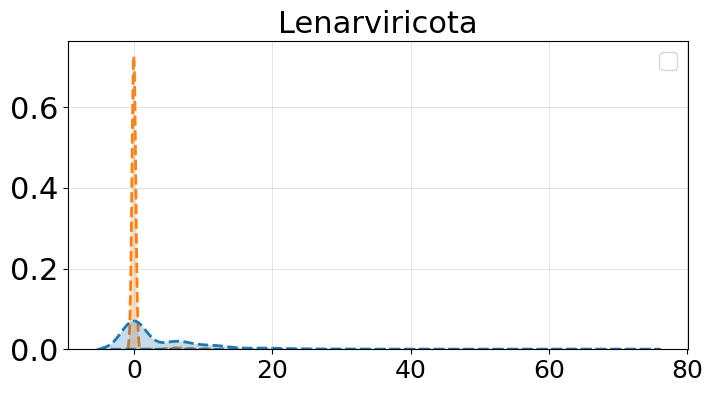

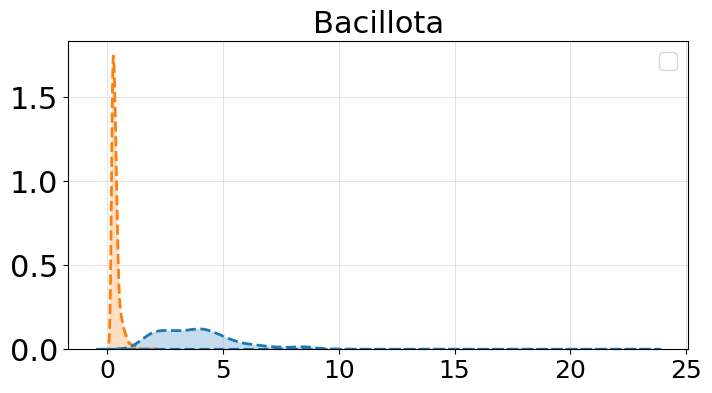

In [59]:
top = 100
valid_phylums_list = list(valid_phylums)
valid_phylums_list = ["Lenarviricota", "Bacillota"]

for phylum in valid_phylums_list[:top]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))

    temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
                                                                                     value_vars=[f"density_{pattern}",
                                                                                                 f"density_{pattern}_control"],
                                                                                    value_name=f"density_{pattern}",
                                                                                    variable_name="group"
                                                                                                 )
    # print(temp_df.head())

    sns.kdeplot(data=temp_df, 
                x=f"density_{pattern}", 
                hue="group", 
                common_norm=True, 
                bw_adjust=1.0,
                fill=True, 
                lw=2.0, 
                linestyle='--')
    ax.grid(lw=0.4, alpha=0.6,)
    ax.tick_params(axis="y", labelsize=22)
    ax.tick_params(axis="x", labelsize=18)
    ax.set_title(phylum, fontsize=22)
    ax.legend(prop={"size": 16})
    ax.set_ylabel("")
    ax.set_xlabel("")

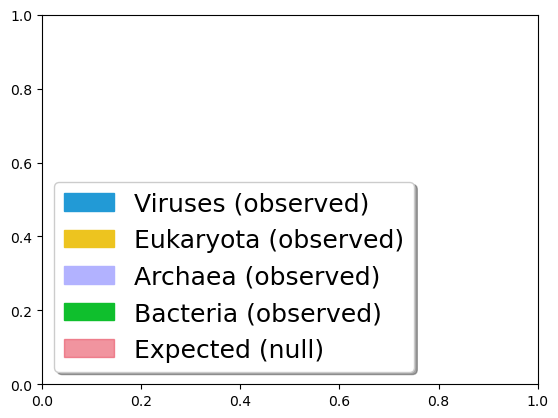

In [69]:
colors = {f"{c} (observed)": l for c, l in domain_colors.items()} | {"Expected (null)": "#E84D6099"}
f = lambda m,c: plt.plot([],[],marker=m, color=c, ls="none")[0]
handles = [mpatches.Patch(color=colors[c], label=c) for c in colors]
legend = plt.legend(handles=handles, loc=3, framealpha=1, frameon=True, shadow=True, fancybox=True, prop={"size": 18})

def export_legend(legend, filename="IR_figures/legend_domains_and_expected_ridge.pdf"):
    fig  = legend.figure
    fig.canvas.draw()
    bbox  = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(filename, dpi="figure", transparent=True, bbox_inches=bbox)

export_legend(legend)
plt.show()


In [70]:
def ridge(category, data, scale=1.0):
    return list(zip([category]*len(data), scale*data))

cats = list(reversed(probly.keys()))

palette = [cc.rainbow[i*15] for i in range(17)]

x = linspace(-6, 18, 300)
source = ColumnDataSource(data=dict(x=x))
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                 'Bacteria': '#0fbf2d',
                 'Archaea': '#b2b2ff',                
            }

# phylums = [phylum for phylum in set(comparison_df_all_phylum_valid["phylum"]) if phylum in valid_phylums]
phylums = [phylum for phylum in list(phylum_stat_assessed_to_list)[::-1] if phylum in valid_phylums]
p = figure(y_range=phylums, width=1200, height=2100, x_range=(-0.99, 6.5), toolbar_location=None)

specific_phyla = {'Streptophyta', 'Nucleocytoviricota', 'Peploviricota', 'Cressdnaviricota', 'Lenarviricota', 'Chordata'}

for i, cat in enumerate(phylums):
    phylum_data = comparison_df_all_phylum_valid.filter(pl.col("phylum") == cat)
    densities = phylum_data[f"density_{pattern}"].to_list()
    pdf = gaussian_kde(densities)

    if cat in specific_phyla:
        scale = 1.6
    else:
        scale = 0.8
    y = ridge(cat, pdf(x), scale=scale)
    # source.add(y, cat)
    source = ColumnDataSource(data=dict(x=x, y=y))
    p.patch('x', 'y', color=domain_colors[phylum_to_domain[cat]], alpha=0.6, line_color="black", source=source)

    # 
    densities_control = phylum_data[f"density_{pattern}_control"].to_list()
    pdf = gaussian_kde(densities_control)
    y = ridge(cat, pdf(x), scale=0.6)
    # source.add(y, cat)
    source = ColumnDataSource(data=dict(x=x, y=y))
    p.patch('x', 'y', color=expected_color, alpha=0.55, line_color="black", source=source)

p.outline_line_color = None
p.background_fill_color = "#ffffff"

# p.xaxis.ticker = FixedTicker(ticks=list(range(0, 101, 10)))
# p.xaxis.formatter = PrintfTickFormatter(format="%d%%")

p.ygrid.grid_line_color = None
p.xgrid.ticker = p.xaxis.ticker

p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
p.xgrid.ticker = p.xaxis.ticker
p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
p.yaxis.major_label_text_font_size = "26pt"
p.xaxis.major_label_text_font_size = "32pt"
p.xaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_size = "36pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"

# # # #
# p.ygrid.grid_line_color = None
# p.xgrid.grid_line_color = "#dddddd"
# p.xgrid.ticker = p.xaxis.ticker

# p.axis.minor_tick_line_color = None
# p.axis.major_tick_line_color = None
# p.axis.axis_line_color = None
# p.background_fill_color = "white"        
# p.outline_line_color = None             
# p.xgrid.grid_line_color = "#dddddd"     
p.ygrid.grid_line_color = None     

p.y_range.range_padding = 0.10
target = Path(f"{pattern}_figures/simulation/phylum").resolve()
export_svg(p, filename=f"{target}/phylum_{pattern}_ridgeplot_density.svg", webdriver=driver)
show(p)

# Viral Host Analysis

In [71]:
viruses_df = pl.read_csv("viruses.txt", ignore_errors=True, separator="\t")
viruses_df

#Organism/Name,TaxID,BioProject Accession,BioProject ID,Group,SubGroup,Size (Kb),GC%,Host,Segmemts,Genes,Proteins,Release Date,Modify Date,Status
str,i64,str,i64,str,str,f64,f64,str,str,str,i64,str,str,str
"""Plasmavirus L2""",46014,null,0,"""Other""","""Plasmaviridae""",11.965,32.0,"""bacteria""",""" Unknown:NC_001447.1/L13696.1""","""14""",14,"""1993/06/11""","""2020/12/20""","""Complete Genome"""
"""Pseudoalteromonas phage PM2""",2905728,null,0,"""Other""","""Corticoviridae""",10.079,42.2,"""bacteria""",""" Unknown:NC_000867.1/AF155037.…","""22""",22,"""1999/07/13""","""2021/12/22""","""Complete Genome"""
"""Circular ssDNA virus sp.""",2805939,"""PRJNA418044""",418044,"""unclassified viruses""","""unclassified""",2.201,57.8,"""human,vertebrates""","""MG571900.1""","""-""",2,"""2018/06/15""","""2018/06/20""","""Complete Genome"""
"""Mushroom bacilliform virus""",32625,null,0,"""Other""","""Barnaviridae""",4.009,46.3,"""fungi""",""" Unknown:NC_001633.1/U07551.1""","""4""",4,"""1994/10/08""","""2018/08/13""","""Complete Genome"""
"""Shrimp white spot syndrome vir…",92652,null,0,"""Other""","""Nimaviridae""",305.119,41.0,"""invertebrates""","""AF332093.3""","""-""",524,"""2001/11/20""","""2014/11/14""","""Complete Genome"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Siphoviridae environmental sam…",2133760,"""PRJEB49206""",840256,"""Other""","""Other""",22.509,34.8,"""-""","""CAOIBP000000000.1""","""-""",null,"""2023/01/16""","""2023/01/18""","""Contig"""
"""Siphoviridae environmental sam…",2133760,"""PRJEB49206""",840256,"""Other""","""Other""",22.467,36.4,"""-""","""CAODQX000000000.1""","""-""",null,"""2023/01/15""","""2023/01/17""","""Contig"""
"""Siphoviridae environmental sam…",2133760,"""PRJEB49206""",840256,"""Other""","""Other""",22.399,36.4,"""-""","""CAOGHG000000000.1""","""-""",null,"""2023/01/16""","""2023/01/18""","""Contig"""


In [72]:
host_eukaryota = {
                    'plants', 
                    'eukaryotic algae',
                    'invertebrates',
                    'fungi',
                    'land plants',
                    'human',
                    'protozoa',
                    'vertebrates'
        }

assembly_df = pd.read_table("assembly_summary_with_tree.csv.gz", 
                     usecols=["#assembly_accession", 
                              "organism_name",
                              "species_taxid", 
                              "taxid",
                              "domain", 
                              "kingdom", 
                              "phylum", 
                              "gc_percent", 
                              "genome_size"]
                              )
def map_kingdom(row) -> str:
    if row["domain"] == "Viruses":
        return "Viruses"
    if row["domain"] == "Eukaryota":
        return row["kingdom"]
    if row["domain"] == "Bacteria":
        return "Bacteria"
    if row["domain"] == "Archaea":
        return "Archaea"
    raise ValueError()
assembly_df = pl.from_pandas(assembly_df).with_columns(pl.struct(["domain", "kingdom"]).map_elements(map_kingdom, return_dtype=pl.Utf8).alias("kingdom_reduced"))

def detect_kingdom_host(host: str) -> str:
    host = host.strip()
    host = list(map(lambda x: x.lower().strip(), host.split(",")))

    if len(host) == 1:
        host = host[0]
        if host == "fungi":
            return "Fungi"
        if host == "plants" or host == "land plants":
            return "Plantae"
        if host == "invertebrates" or host == "vertebrates" or host == "human":
            return "Animalia"
        if host == "protozoa" or host == "eukaryotic algae":
            return "Protista"
        if host == "bacteria":
            return "Bacteria"
        if host == "archaea":
            return "Archaea"
        return host.capitalize()
    else:
        if all(i in {"invertebrates", "vertebrates", "human"} for i in host):
            return "Animalia"
        if all(i in {"plants", "land plants"} for i in host):
            return "Plantae"
        if all(i in {"protozoa", "eukaryotic algae"} for i in host):
            return "Protista"
        if all(i.strip() == "fungi" for i in host):
            return "Fungi"
        elif all(i.strip() == "bacteria" for i in host):
            return "Bacteria"
        elif all(i.strip() == "archaea" for i in host):
            return "Archaea"
        elif all(i.strip() in host_eukaryota for i in host):
            return "Eukaryota"
        elif "bacteria" in host and "archaea" in host:
            return "Prokaryota"
        return "Multiple Hosts"
    

def detect_domain_host(host: str) -> str:
    host = host.strip()
    host = list(map(lambda x: x.lower().strip(), host.split(",")))

    if all(i in host_eukaryota for i in host):
        return "Eukaryota"
    elif all(i == "bacteria" for i in host):
        return "Bacteria"
    elif all(i == "archaea" for i in host):
        return "Archaea"
    elif "bacteria" in host and "archaea" in host:
        return "Prokaryota"
    elif "viruses" in host:
        return "Viruses"
    return "Multiple Domains"

def extract_baltimore_group(molecule_type: str) -> str:
    if "ssDNA" in molecule_type:
        return "ssDNA" 
    
    if "dsRNA" in molecule_type:
        return "dsRNA" 
    
    if "ssRNA" in molecule_type and "+" in molecule_type:
        return "ssRNA(+)"
    
    if "ssRNA" in molecule_type and "-" in molecule_type:
        return "ssRNA(-)"
    
    if molecule_type == "dsDNA-RT":
        return "dsDNA-RT"
    
    if molecule_type == "ssRNA-RT":
        return "ssRNA-RT"
    
    if "dsDNA" in molecule_type:
        return "dsDNA"
    
    return "Other"
    
molecule_viruses_df = (
                        pl.read_csv("viruses_molecule_type.csv",
                                  columns=["Assembly", "Organism_Name", "Species", "Host", "Molecule_type"]
                                  )
                        # .filter(pl.col("Molecule_type") != "unknown")
                    .with_columns(
                            group=pl.col("Molecule_type").map_elements(extract_baltimore_group, return_dtype=pl.Utf8)
                        )
                    .join(
                                                    assembly_df.select(["organism_name", "species_taxid", "domain", "kingdom_reduced"]).unique(["organism_name"]),
                                                    left_on="Host",
                                                    right_on="organism_name",
                                                    how="inner",
                                                    suffix="_host"
                    )
                    .rename({"kingdom_reduced": "kingdom_host"})
                  
)

viruses_df = pl.read_csv("viruses.txt", ignore_errors=True, separator="\t")
viruses_df = (
    viruses_df.filter(pl.col("Host") != "-") 
              .with_columns(
                  domain_host=pl.col("Host").map_elements(detect_domain_host, return_dtype=pl.Utf8),
                  kingdom_host=pl.col("Host").map_elements(detect_kingdom_host, return_dtype=pl.Utf8),
              )
              .unique(["TaxID"])
)
for host in viruses_df["domain_host"].unique():
    count = len(viruses_df.filter(pl.col("domain_host") == host))
                                                

viruses_df = (
            viruses_df
            .select(["#Organism/Name", "TaxID", "Host", "Group", "domain_host", "kingdom_host"])
            .unique(["TaxID"])
)
viruses_df = pl.concat([
    viruses_df.select([
        "#Organism/Name",
        "TaxID",
        "domain_host",
        "kingdom_host",
    ]),
    molecule_viruses_df.select([
        "Organism_Name",
        "species_taxid",
        "domain",
        "kingdom_host"
    ]).rename({
        "Organism_Name": "#Organism/Name",
        "species_taxid": "TaxID",
        "domain": "domain_host"
    })
])
viruses_df = viruses_df.unique(["TaxID"])
viruses_df

#Organism/Name,TaxID,domain_host,kingdom_host
str,i64,str,str
"""Maize streak virus - Reunion […",268334,"""Eukaryota""","""Plantae"""
"""Wuhan insect virus 28""",1923732,"""Eukaryota""","""Animalia"""
"""Hepatitis C virus JFH-1""",356411,"""Eukaryota""","""Animalia"""
"""Cow vetch latent virus alphasa…",2056781,"""Eukaryota""","""Plantae"""
"""Escherichia phage vB_EcoS-2602…",2576514,"""Bacteria""","""Bacteria"""
…,…,…,…
"""Streptomyces phage Starbow""",2283266,"""Bacteria""","""Bacteria"""
"""Enterobacteria phage KhF1""",1651203,"""Bacteria""","""Bacteria"""
"""Mycobacterium phage Cornie""",2704043,"""Bacteria""","""Bacteria"""


In [73]:
viruses_df.filter(pl.col("TaxID") == 1314)

#Organism/Name,TaxID,domain_host,kingdom_host
str,i64,str,str
"""Streptococcus phage 315.6""",1314,"""Bacteria""","""Bacteria"""


In [88]:
comparison_df_with_viruses = comparison_df.filter(pl.col("partition") == ".").join(
                 viruses_df,
                 left_on="organism_name",
                 right_on="#Organism/Name",
                 how="inner",
                 suffix="_virus"
).unique(["#assembly_accession"])
comparison_df_with_viruses

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,TaxID,domain_host,kingdom_host
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,i64,str,str
"""GCA_003622515.1""",0,""".""",2748378,"""Cressdnaviricota sp.""",1710,43.0,"""Viruses""","""Cressdnaviricota""","""Shotokuvirae""",0.0,1710,0,0.0,0.0,2748378,"""Eukaryota""","""Animalia"""
"""GCA_003623775.1""",0,""".""",2748378,"""Cressdnaviricota sp.""",1917,49.5,"""Viruses""","""Cressdnaviricota""","""Shotokuvirae""",0.0,1917,0,0.0,0.0,2748378,"""Eukaryota""","""Animalia"""
"""GCA_002681495.1""",0,""".""",28875,"""Porcine rotavirus A""",18444,34.0,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,18444,51,2.765,-1.0,10967,"""Eukaryota""","""Animalia"""
"""GCA_031088475.1""",0,""".""",222459,"""Cotton leaf curl Gezira virus-…",2761,44.5,"""Viruses""","""Cressdnaviricota""","""Shotokuvirae""",0.0,2761,0,0.0,0.0,222463,"""Eukaryota""","""Plantae"""
"""GCF_002612025.1""",0,""".""",2733679,"""Klebsiella phage vB_KpnP_KpV76…",40765,53.0,"""Viruses""","""Uroviricota""","""Heunggongvirae""",0.0,40765,0,0.0,0.0,1882400,"""Bacteria""","""Bacteria"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCA_002657575.1""",54,""".""",28875,"""Rotavirus A""",18039,32.0,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",2.994,18039,0,0.0,1.0,28875,"""Eukaryota""","""Animalia"""
"""GCA_029970275.1""",118,""".""",38018,"""Bacteriophage sp.""",67398,55.5,"""Viruses""",null,null,1.751,67398,0,0.0,1.0,38018,"""Multiple Domains""","""Multiple Hosts"""
"""GCA_003620715.1""",0,""".""",2748378,"""Cressdnaviricota sp.""",1914,40.0,"""Viruses""","""Cressdnaviricota""","""Shotokuvirae""",0.0,1914,0,0.0,0.0,2748378,"""Eukaryota""","""Animalia"""


In [75]:
comparison_df_with_viruses.filter(pl.col("domain") != "Viruses")

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,TaxID,domain_host,kingdom_host
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,i64,str,str


<Axes: xlabel='density_IR', ylabel='phylum'>

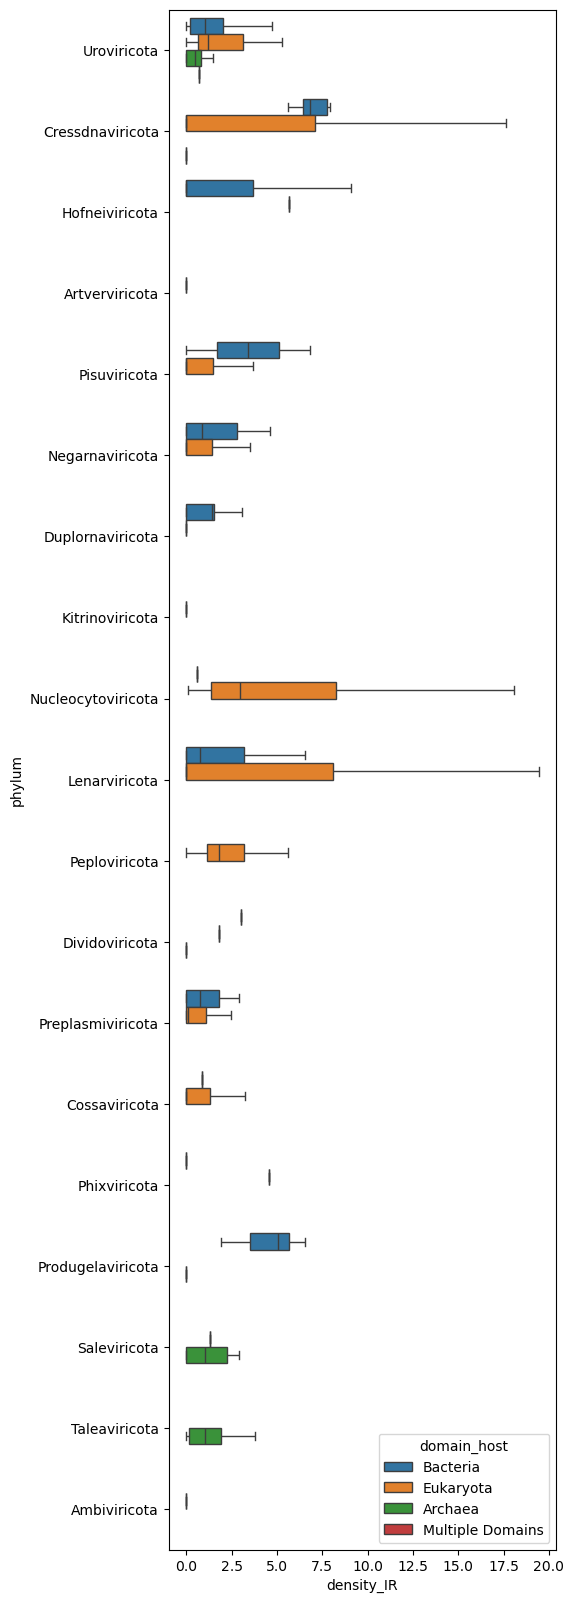

In [76]:
df_viral_species = comparison_df_with_viruses.group_by("species_taxid").agg(
                                                                    pl.col("domain_host").first(), 
                                                                    pl.col(f"density_{pattern}").mean(),
                                                                    pl.col(f"density_{pattern}_control").mean(),
                                                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                                                    pl.col("phylum").first(),
                                                                )
plt.figure(figsize=(5, 20))
sns.boxplot(data=df_viral_species.to_pandas(),
            y="phylum",
            hue="domain_host",
            x="density_IR",
            showfliers=False,
            orient="h"
           )

In [77]:
groups = ["Bacteria", "Eukaryota", "Archaea"]
col = "domain_host"
groups_paired = [c for c in itertools.combinations(groups, r=2)]
df_viral_species = comparison_df_with_viruses.group_by("species_taxid").agg(
                                                                    pl.col(col).first(), 
                                                                    pl.col(f"density_{pattern}").mean(),
                                                                    pl.col(f"density_{pattern}_control").mean(),
                                                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                                                    pl.col("phylum").first(),
                                                                )

results = []
# Intra-Viral Host Domain Comparison
for pair in groups_paired:
    if pair[0] != pair[1]:
        domain_obs_A = df_viral_species.filter(pl.col(col) == pair[0])[f"density_{pattern}"].to_list()
        domain_obs_B = df_viral_species.filter(pl.col(col) == pair[1])[f"density_{pattern}"].to_list()
        # # # # # # #
        # # # # # # #

        n_A = len(domain_obs_A)
        n_B = len(domain_obs_B)
        empty_A = sum(l == 0.0 for l in domain_obs_A)
        empty_B = sum(l == 0.0 for l in domain_obs_B)
        print(f"Group {pair[0]}: n={n_A}, empty={empty_A} ({(empty_A/n_A)*100:.2f}%)")
        print(f"Group {pair[1]}: n={n_B}, empty={empty_B} ({(empty_B/n_B)*100:.2f}%)")
        diff = np.mean(domain_obs_A) - np.mean(domain_obs_B)
        mw_result = mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided')
        welsch_result = ttest_ind(domain_obs_A, domain_obs_B, equal_var=False)
        
        cles = (mw_result.statistic) / (len(domain_obs_A) * len(domain_obs_B))
        # cles = 2 * cles - 1
        print(pair, cles)
        results.append({
                        "group_A": pair[0],
                        "group_B": pair[1],
                        "empty_A": empty_A,
                        "empty_B": empty_B,
                        "pct_empty_A": (empty_A / n_A) * 100,
                        "pct_empty_B": (empty_B / n_B) * 100,
                        "n_A": len(domain_obs_A),
                        "n_B": len(domain_obs_B),
                        "cles_mwu": cles,
                        "mannwhitneyu_statistic": mw_result.statistic,
                        "mannwhitneyu_pvalue": mw_result.pvalue,
                        "welsch_t_statistic": welsch_result.statistic,
                        "welsch_pvalue": welsch_result.pvalue,
                       })
        print(pair, mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided'), diff)
        print(pair, ttest_ind(domain_obs_A, domain_obs_B, equal_var=False), diff)

        print(' ')
        print("*" * 10)

results = pd.DataFrame(results)
results

Group Bacteria: n=8235, empty=2151 (26.12%)
Group Eukaryota: n=7560, empty=4928 (65.19%)
('Bacteria', 'Eukaryota') 0.6270688810503625
('Bacteria', 'Eukaryota') MannwhitneyuResult(statistic=np.float64(39039176.5), pvalue=np.float64(1.6163797966288387e-184)) -1.2722011113961966
('Bacteria', 'Eukaryota') TtestResult(statistic=np.float64(-13.666531847982194), pvalue=np.float64(4.6700831257525675e-42), df=np.float64(8147.13344176569)) -1.2722011113961966
 
**********
Group Bacteria: n=8235, empty=2151 (26.12%)
Group Archaea: n=118, empty=48 (40.68%)
('Bacteria', 'Archaea') 0.5781528819733877
('Bacteria', 'Archaea') MannwhitneyuResult(statistic=np.float64(561808.5), pvalue=np.float64(0.003210370197707979)) 0.3978181284883022
('Bacteria', 'Archaea') TtestResult(statistic=np.float64(3.4979428854147065), pvalue=np.float64(0.0006531285336934958), df=np.float64(123.09661394160523)) 0.3978181284883022
 
**********
Group Eukaryota: n=7560, empty=4928 (65.19%)
Group Archaea: n=118, empty=48 (40.68%)

,group_A,group_B,empty_A,empty_B,pct_empty_A,pct_empty_B,n_A,n_B,cles_mwu,mannwhitneyu_statistic,mannwhitneyu_pvalue,welsch_t_statistic,welsch_pvalue
0,Bacteria,Eukaryota,2151,4928,26.120219,65.185185,8235,7560,0.627069,39039176.5,1.616380e-184,-13.666532,4.670083e-42
1,Bacteria,Archaea,2151,48,26.120219,40.677966,8235,118,0.578153,561808.5,3.210370e-03,3.497943,6.531285e-04
2,Eukaryota,Archaea,4928,48,65.185185,40.677966,7560,118,0.435171,388207.0,4.549806e-03,11.537697,5.399571e-26


In [78]:
groups = ["Bacteria", "Archaea", "Protista", "Fungi", "Plantae", "Animalia"]
col = "kingdom_host"
groups_paired = [c for c in itertools.combinations(groups, r=2)]
df_viral_species = comparison_df_with_viruses.group_by("species_taxid").agg(
                                                                    pl.col(col).first(), 
                                                                    pl.col(f"density_{pattern}").mean(),
                                                                    pl.col(f"density_{pattern}_control").mean(),
                                                                    pl.col("fold_enrichment").mean().alias("fold_enrichment")
                                                                )

results = []
# Intra-Viral Host Domain Comparison
for pair in groups_paired:
    if pair[0] != pair[1]:
        domain_obs_A = df_viral_species.filter(pl.col(col) == pair[0])[f"density_{pattern}"].to_list()
        domain_obs_B = df_viral_species.filter(pl.col(col) == pair[1])[f"density_{pattern}"].to_list()

        n_A = len(domain_obs_A)
        n_B = len(domain_obs_B)
        empty_A = sum(l == 0.0 for l in domain_obs_A)
        empty_B = sum(l == 0.0 for l in domain_obs_B)
        print(f"Group {pair[0]}: n={n_A}, empty={empty_A} ({(empty_A/n_A)*100:.2f}%)")
        print(f"Group {pair[1]}: n={n_B}, empty={empty_B} ({(empty_B/n_B)*100:.2f}%)")
        # # # # # # #
        # # # # # # #
        diff = np.mean(domain_obs_A) - np.mean(domain_obs_B)
        mw_result = mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided')
        welsch_result = ttest_ind(domain_obs_A, domain_obs_B, equal_var=False)
        
        cles = (mw_result.statistic) / (len(domain_obs_A) * len(domain_obs_B))
        # cles = 2 * cles - 1
        print(pair, cles)
        results.append({
                        "group_A": pair[0],
                        "group_B": pair[1],
                        "n_A": len(domain_obs_A),
                        "n_B": len(domain_obs_B),
                        "empty_A": empty_A * 1e2 / len(domain_obs_A),
                        "empty_B": empty_A * 1e2 / len(domain_obs_B),
                        "cles_mwu": cles,
                        "mannwhitneyu_statistic": mw_result.statistic,
                        "mannwhitneyu_pvalue": mw_result.pvalue,
                        "welsch_t_statistic": welsch_result.statistic,
                        "welsch_pvalue": welsch_result.pvalue,
                       })
        print(pair, mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided'), diff)
        print(pair, ttest_ind(domain_obs_A, domain_obs_B, equal_var=False), diff)

        print(' ')
        print("*" * 10)

results = pd.DataFrame(results)
results

Group Bacteria: n=8235, empty=2151 (26.12%)
Group Archaea: n=118, empty=48 (40.68%)
('Bacteria', 'Archaea') 0.5781528819733877
('Bacteria', 'Archaea') MannwhitneyuResult(statistic=np.float64(561808.5), pvalue=np.float64(0.003210370197707979)) 0.397818128488302
('Bacteria', 'Archaea') TtestResult(statistic=np.float64(3.4979428854147043), pvalue=np.float64(0.0006531285336935008), df=np.float64(123.09661394160523)) 0.397818128488302
 
**********
Group Bacteria: n=8235, empty=2151 (26.12%)
Group Protista: n=99, empty=34 (34.34%)
('Bacteria', 'Protista') 0.44756551550722773
('Bacteria', 'Protista') MannwhitneyuResult(statistic=np.float64(364884.5), pvalue=np.float64(0.06986373543595342)) -2.995315158557273
('Bacteria', 'Protista') TtestResult(statistic=np.float64(-4.672772023810639), pvalue=np.float64(9.463301101241456e-06), df=np.float64(98.15493462573072)) -2.995315158557273
 
**********
Group Bacteria: n=8235, empty=2151 (26.12%)
Group Fungi: n=500, empty=383 (76.60%)
('Bacteria', 'Fungi

,group_A,group_B,n_A,n_B,empty_A,empty_B,cles_mwu,mannwhitneyu_statistic,mannwhitneyu_pvalue,welsch_t_statistic,welsch_pvalue
0,Bacteria,Archaea,8235,118,26.120219,1822.881356,0.578153,561808.5,3.210370e-03,3.497943,6.531285e-04
1,Bacteria,Protista,8235,99,26.120219,2172.727273,0.447566,364884.5,6.986374e-02,-4.672772,9.463301e-06
2,Bacteria,Fungi,8235,500,26.120219,430.200000,0.689767,2840114.0,2.543502e-47,-1.806665,7.140996e-02
3,Bacteria,Plantae,8235,2219,26.120219,96.935557,0.601477,10991073.5,6.147545e-51,-12.490378,1.169926e-34
4,Bacteria,Animalia,8235,4704,26.120219,45.727041,0.637385,24690679.5,1.485519e-159,-5.262451,1.477243e-07
5,Archaea,Protista,118,99,40.677966,48.484848,0.389188,4546.5,3.878278e-03,-5.215977,9.363600e-07
6,Archaea,Fungi,118,500,40.677966,9.600000,0.627136,37001.0,1.229596e-07,-3.153731,1.690435e-03
7,Archaea,Plantae,118,2219,40.677966,2.163137,0.545676,142881.0,4.930447e-02,-12.899349,1.524609e-36
8,Archaea,Animalia,118,4704,40.677966,1.020408,0.572047,317527.0,1.874533e-03,-5.892339,1.360975e-08
9,Protista,Fungi,99,500,34.343434,6.800000,0.701919,34745.0,5.975556e-15,3.755161,2.632490e-04


In [80]:
# comparison_df_general_baltimore = comparison_df_general_baltimore.join(
#                                             assembly_df.select(["organism_name", "species_taxid", "domain"]).unique(["organism_name"]),
#                                             left_on="Host",
#                                             right_on="organism_name",
#                                             how="left",
#                                             suffix="_host"
# )
# comparison_df_general_baltimore

In [89]:
# comparison_df_general_baltimore.filter(~pl.col("domain_host").is_null())["domain_host"].value_counts()

In [83]:
# df_viral_species = comparison_df_general_baltimore.filter(~pl.col("domain_host").is_null()).group_by("species_taxid").agg(
#                                                                     pl.col("group").first(), 
#                                                                     pl.col("domain_host").first(),
#                                                                     pl.col(f"density_{pattern}").mean(),
#                                                                     pl.col(f"density_{pattern}_control").mean(),
#                                                                     pl.col("fold_enrichment").mean().alias("fold_enrichment")
#                                                                 )
# sns.boxplot(data=df_viral_species.to_pandas(),
#             x="group",
#             y=f"density_{pattern}",
#             hue="domain_host",
#             showfliers=False,
#            )
# plt.xticks(rotation=45)

In [85]:
# groups = comparison_df_general_baltimore["group"].unique().to_list()
# col = "group"
# groups_paired = [c for c in itertools.combinations(groups, r=2)]
# df_viral_species = comparison_df_general_baltimore.group_by("species_taxid").agg(
#                                                                     pl.col(col).first(), 
#                                                                     pl.col(f"density_{pattern}").mean(),
#                                                                     pl.col(f"density_{pattern}_control").mean(),
#                                                                     pl.col("fold_enrichment").mean().alias("fold_enrichment")
#                                                                 )

# results_baltimore = []
# # Intra-Viral Host Domain Comparison
# for pair in groups_paired:
#     if pair[0] != pair[1]:
#         domain_obs_A = df_viral_species.filter(pl.col(col) == pair[0])[f"density_{pattern}"].to_list()
#         domain_obs_B = df_viral_species.filter(pl.col(col) == pair[1])[f"density_{pattern}"].to_list()

#         total_empty_A = sum(l == 0.0 for l in domain_obs_A)
#         total_empty_B = sum(l == 0.0 for l in domain_obs_B)
#         print(f"{pair}: n_A={len(domain_obs_A)}, n_B={len(domain_obs_B)}, empty_A={total_empty_A}, empty_B={total_empty_B}")
#         # # # # # # #
#         # # # # # # #
#         diff = np.mean(domain_obs_A) - np.mean(domain_obs_B)
#         mw_result = mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided')
#         welsch_result = ttest_ind(domain_obs_A, domain_obs_B, equal_var=False)
        
#         cles = (mw_result.statistic) / (len(domain_obs_A) * len(domain_obs_B))
#         # cles = 2 * cles - 1
#         print(pair, cles)
#         results.append({
#                         "group_A": pair[0],
#                         "group_B": pair[1],
#                         "n_A": len(domain_obs_A),
#                         "n_B": len(domain_obs_B),
#                         "cles_mwu": cles,
#                         "mannwhitneyu_statistic": mw_result.statistic,
#                         "mannwhitneyu_pvalue": mw_result.pvalue,
#                         "welsch_t_statistic": welsch_result.statistic,
#                         "welsch_pvalue": welsch_result.pvalue,
#                        })
#         print(pair, mannwhitneyu(domain_obs_A, domain_obs_B, alternative='two-sided'), diff)
#         print(pair, ttest_ind(domain_obs_A, domain_obs_B, equal_var=False), diff)

#         print(' ')
#         print("*" * 10)

# results_baltimore = pd.DataFrame(results_baltimore)
# results_baltimore

### Statistical Evaluation of STR enrichment in viral hosts

In [97]:
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',                
            }

df = (
        comparison_df_with_viruses.group_by("species_taxid").agg(
                pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                pl.col("domain").first().alias("domain"),
                pl.col("domain_host").first().alias("domain_host"),
                pl.col("kingdom").first().alias("kingdom"),
                pl.col("phylum").first().alias("phylum"),
            )
            .filter(pl.col("domain_host") != "Multiple Domains")
            .to_pandas()
            .copy()
)

group_col = "domain_host"
value_col = "fold_enrichment"
hosts = {"Bacteria", "Archaea", "Eukaryota"}
cmap = {host: domain_colors[host] for host in hosts}
hosts = list(hosts)
df.loc[:, "domain_color"] = df["domain_host"].map(cmap)

groups = sorted(df[group_col].dropna().unique())
qs = df.groupby(group_col)[value_col].quantile([0.25, 0.5, 0.75]).unstack().reset_index()
qs.columns = [group_col, "q1", "q2", "q3"]
df = df.merge(qs, on=group_col, how="left")

# Compute IQR whisker bounds
df["iqr"] = df["q3"] - df["q1"]
df["upper"] = df["q3"] + 1.5 * df["iqr"]
df["lower"] = df["q1"] - 1.5 * df["iqr"]

# Source for whiskers and boxes (aggregated)
box_stats = df[[group_col, "q1", "q2", "q3", "upper", "lower", "domain_color"]].drop_duplicates()
source = ColumnDataSource(box_stats)

# Outliers
outliers = df[~df[value_col].between(df["lower"], df["upper"])]
out_source = ColumnDataSource(outliers)

p = figure( # x_range=["Bacteria", "Eukaryota", "Archaea"], 
           height=600, 
           width=900,
           title="",
           border_fill_color=None,
           output_backend="svg",
           y_axis_label=f"{pattern} Enrichment")
whisker = Whisker(base=group_col, upper="upper", lower="lower", source=source)
whisker.upper_head.size = whisker.lower_head.size = 25
p.add_layout(whisker)

top_box = p.vbar(x=group_col, width=0.4, top="q3", bottom="q2", source=source, color="domain_color", line_color="black")
p.vbar(x=group_col, width=0.4, top="q2", bottom="q1", source=source, color="domain_color", line_color="black")
hline = Span(location=0, dimension='width', line_color='black', line_width=2, line_dash='dashed')
p.add_layout(hline)

p.xgrid.grid_line_color = None
p.title.text_font_size = "26pt"
p.title.align = "center"

# p.y_range.end = 1.0
# p.y_range.start = -1.0

p.xaxis.axis_label_text_font_size = "28pt"
p.yaxis.axis_label_text_font_size = "34pt"
p.xaxis.major_label_text_font_size = "32pt"
p.yaxis.major_label_text_font_size = "28pt"
p.title.text_font_style = "normal"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"

# Save SVGs
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True, parents=True)
show(p)
# export_svg(p, filename=target / f"viral_host_enrichment_{pattern}.svg", webdriver=driver)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Archaea vs. Eukaryota: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.365e-02 U_stat=5.039e+05
Bacteria vs. Archaea: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:9.631e-03 U_stat=5.618e+05
Bacteria vs. Eukaryota: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.849e-184 U_stat=3.904e+07


/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/3663488123.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


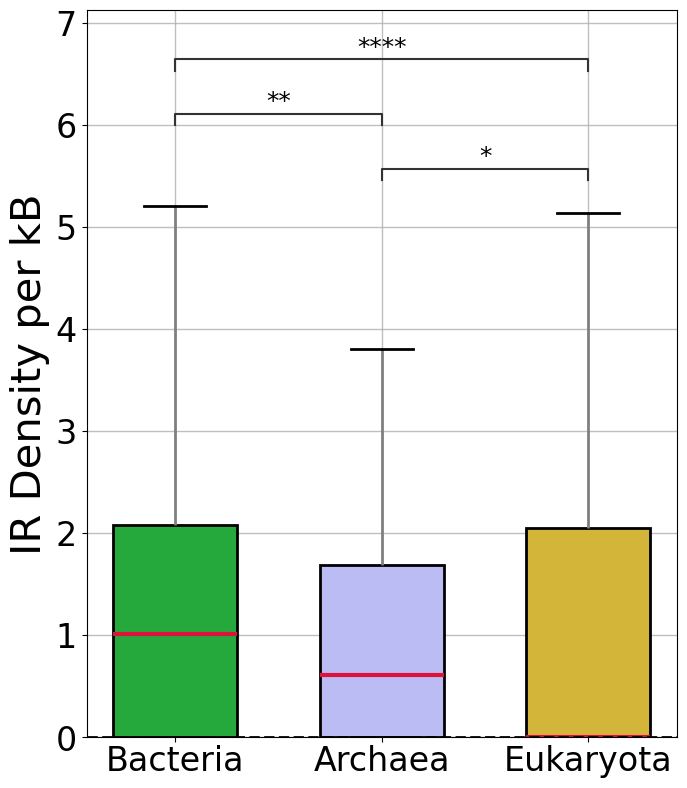

In [99]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))
df = comparison_df_with_viruses.group_by("species_taxid").agg(
    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
    pl.col("domain").first().alias("domain"),
    pl.col("domain_host").first().alias("domain_host"),
).to_pandas().copy()
group_col = "domain_host"
value_col = f"density_{pattern}"

# # # # Plotting
hosts = {"Eukaryota", "Bacteria", "Archaea"}
cmap = {host: domain_colors[host] for host in hosts}
df.loc[:, "domain_color"] = df["domain_host"].map(cmap)
order = ["Eukaryota", "Archaea", "Bacteria"][::-1]

sns.boxplot(data=df,
            x=group_col,
            y=value_col,
            palette=cmap,
            width=0.6,
            linewidth=1.5,
            # edgecolor="black",
            order=order,
            ax=ax,
            showfliers=False,
            # saturation=0.8,
            # capsize=0.4,
            boxprops=dict(linewidth=2, edgecolor='black'),
            medianprops=dict(color='crimson', linewidth=3), 
            whiskerprops=dict(linewidth=2, color='gray'),
            capprops=dict(linewidth=2, color='black'),
            flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, pad=2)
ax.set_xlabel('')
ax.set_ylabel(f"{pattern} Density per kB", fontsize=30)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=24)
ax.tick_params(axis="x", 
               labelsize=24, 
               zorder=0)
ax.set_ylim(ymin=0)
ax.legend(handles=[], frameon=False)
pairs=[("Eukaryota", "Archaea"), ("Archaea", "Bacteria"), ("Eukaryota", "Bacteria")]
annotator = Annotator(ax, 
                      pairs, 
                      data=df,
                      x=group_col,
                      y=value_col,
                      order=order
                     )
annotator.configure(test='Mann-Whitney',  
                    comparisons_correction="Bonferroni",
                    text_format='star',
                    fontsize=18,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
ax.axhline(0, color='black', zorder=5, linestyle='--', linewidth=2)
target = Path(f"{pattern}_figures/simulation").resolve()
plt.tight_layout()
fig.savefig(f"{target}/density_comparison_{pattern}_viral_hosts.pdf", 
            transparent=True, 
            bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Archaea vs. Eukaryota: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.575e+05
Bacteria vs. Archaea: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.564e-02 U_stat=5.530e+05
Bacteria vs. Eukaryota: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.838e-134 U_stat=3.793e+07


/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/887068498.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


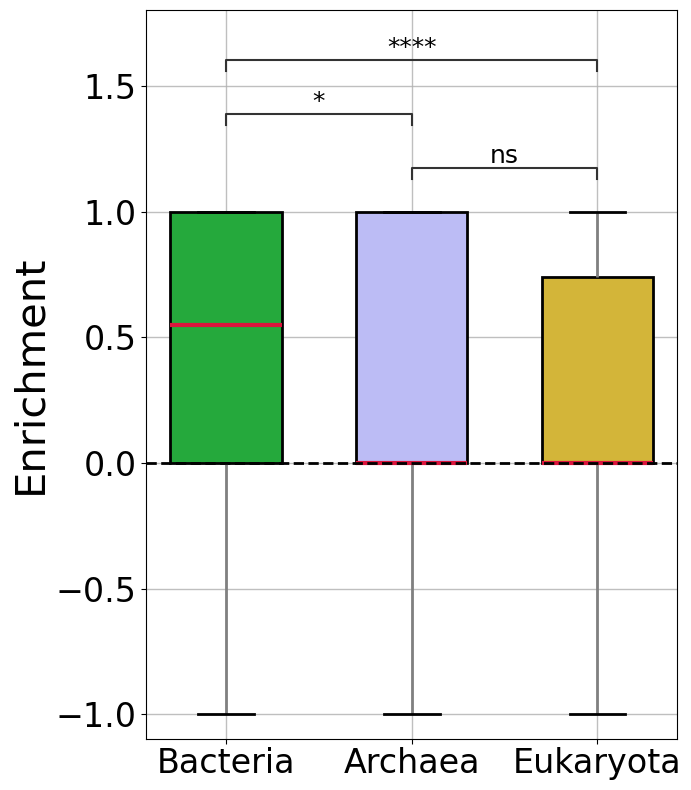

In [100]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))
df = comparison_df_with_viruses.group_by("species_taxid").agg(
    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
    pl.col("domain").first().alias("domain"),
    pl.col("domain_host").first().alias("domain_host"),
    pl.col("kingdom").first().alias("kingdom"),
    pl.col("phylum").first().alias("phylum"),
).to_pandas().copy()
group_col = "domain_host"
value_col = "fold_enrichment"

hosts = {"Eukaryota", "Bacteria", "Archaea"}
cmap = {host: domain_colors[host] for host in hosts}
df.loc[:, "domain_color"] = df["domain_host"].map(cmap)
order = ["Eukaryota", "Archaea", "Bacteria"][::-1]

sns.boxplot(data=df,
            x=group_col,
            y=value_col,
            palette=cmap,
            width=0.6,
            linewidth=1.5,
            # edgecolor="black",
            order=order,
            ax=ax,
            # saturation=0.8,
            # capsize=0.4,
            boxprops=dict(linewidth=2, edgecolor='black'),
            medianprops=dict(color='crimson', linewidth=3), 
            whiskerprops=dict(linewidth=2, color='gray'),
            capprops=dict(linewidth=2, color='black'),
            flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, pad=2)
ax.set_xlabel('')
ax.set_ylabel("Enrichment")
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=24)
ax.tick_params(axis="x", 
               labelsize=24, 
               zorder=0)
ax.legend(handles=[], frameon=False)
pairs=[("Eukaryota", "Archaea"), ("Archaea", "Bacteria"), ("Eukaryota", "Bacteria")]
annotator = Annotator(ax, 
                      pairs, 
                      data=df,
                      x=group_col,
                      y=value_col,
                      order=order
                     )
annotator.configure(test='Mann-Whitney',  
                    comparisons_correction="Bonferroni",
                    text_format='star',
                    fontsize=18,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
ax.axhline(0, color='black', zorder=5, linestyle='--', linewidth=2)
target = Path(f"{pattern}_figures/simulation").resolve()
plt.tight_layout()
fig.savefig(f"{target}/fold_enrichment_{pattern}_viral_hosts.pdf", transparent=True, bbox_inches="tight")

# STR Contribution in IR Enrichment

In [102]:
valid_STR_accessions = set()
with open("STR_valid_accessions.txt") as f: 
    for line in f:
        valid_STR_accessions.add(extract_id(line))

valid_STR_accessions_shuffled = set()
with open("STR_valid_accessions_shuffled.txt") as f: 
    for line in f:
        valid_STR_accessions_shuffled.add(extract_id(line))

mutual_STR_accessions = valid_STR_accessions_shuffled.intersection(valid_STR_accessions)
len(mutual_STR_accessions)

117900

In [103]:
partition_col = "spacer_length"
effect_df = pl.read_csv("STR_effects/STR_effect_results/STR_effects_on_IR_normal.tsv",
                        has_header=False,
                        separator="\t",
                        new_columns=["#assembly_accession", "partition", f"total_bp_{pattern}", "total_STR_bp", "overlap_ratio"]
                        ) 
shuffled_effect_df = pl.read_csv("STR_effects/STR_effect_results_shuffled/STR_effects_on_IR_shuffled.tsv",
                        has_header=False,
                        separator="\t",
                        new_columns=["#assembly_accession", "partition", f"total_bp_{pattern}_control", "total_STR_bp_control", "overlap_ratio_control"]
)

effect_df = (
    effect_df
    .join(
        shuffled_effect_df,
        on=["#assembly_accession", "partition"],
        how="left"
    )
    .filter(
        pl.col("#assembly_accession").is_in(mutual_assemblies.intersection(mutual_STR_accessions))
    )
)   
effect_df

#assembly_accession,partition,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control
str,str,i64,i64,f64,i64,i64,f64
"""GCF_000009305.1""","""0""",154,0,0.0,60,0,0.0
"""GCF_000009305.1""","""1""",198,0,0.0,132,0,0.0
"""GCF_000009305.1""","""2""",204,0,0.0,28,0,0.0
"""GCF_000009305.1""","""3""",308,0,0.0,92,0,0.0
"""GCF_000009305.1""","""4""",152,0,0.0,100,0,0.0
…,…,…,…,…,…,…,…
"""GCA_963681965.1""","""5""",1043,0,0.0,104,0,0.0
"""GCA_963681965.1""","""6""",1026,4,0.39,52,0,0.0
"""GCA_963681965.1""","""7""",571,0,0.0,191,0,0.0


In [104]:
effect_df.filter(pl.col("total_bp_IR") == 0, 
                 pl.col("partition") == "."
                 )["#assembly_accession"].shape

(32731,)

In [200]:
def calculate_enrichment(row: dict) -> float:
    o, e = None, None
    for key, value in row.items():
        if "control" in key:
            e = value
        else:
            o = value
    if o == e:
        return 0.0
    return (o-e)/(o+e)

comparison_df_general = (
            comparison_df.filter(pl.col("partition") != ".")
                .select([
                        "#assembly_accession", 
                        "species_taxid", 
                        "partition",
                        "organism_name", 
                        "domain", 
                        "phylum",
                        "kingdom",
                        "genome_size",
                        f"density_{pattern}", 
                        f"density_{pattern}_control", 
                        "total_bp",
                        "total_bp_control",
                        "fold_enrichment", 
                    ])
                .join(
                    effect_df.filter(pl.col("partition") != "."),
                        # .filter(pl.col("partition") == ".")
                        # .drop(["partition"]),
                    on=["#assembly_accession", "partition"],
                    how="inner"
                )
                .with_columns(
                    (pl.col(f"total_bp_{pattern}") - pl.col("total_STR_bp")).alias(f"total_bp_{pattern}_nonSTR"),
                    (pl.col(f"total_bp_{pattern}_control") - pl.col("total_STR_bp_control")).alias(f"total_bp_{pattern}_control_nonSTR"),
                )
                .with_columns(
                    density_corrected=pl.col(f"total_bp_{pattern}_nonSTR") * 1e3 / pl.col("genome_size"),
                    density_control_corrected=pl.col(f"total_bp_{pattern}_control_nonSTR") * 1e3 / pl.col("genome_size"),
                )
                .with_columns(
                    enrichment=pl.struct([f"total_bp_{pattern}", f"total_bp_{pattern}_control"]).map_elements(calculate_enrichment, return_dtype=float),
                    enrichment_corrected=pl.struct([f"total_bp_{pattern}_nonSTR", f"total_bp_{pattern}_control_nonSTR"]).map_elements(calculate_enrichment, 
                                                                                                                                      return_dtype=float),

                    enrichment_usual=pl.col(f"total_bp_{pattern}") / pl.col(f"total_bp_{pattern}_control"),
                    enrichment_corrected_usual=pl.col(f"total_bp_{pattern}_nonSTR") / pl.col(f"total_bp_{pattern}_control_nonSTR"),
                )   
                                                                                           
)
comparison_df_general

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control,total_bp_IR_nonSTR,total_bp_IR_control_nonSTR,density_corrected,density_control_corrected,enrichment,enrichment_corrected,enrichment_usual,enrichment_corrected_usual
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64
"""GCA_002637055.1""",28875,"""0""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,0.0,0.0,0,0,0.0,0,0,null,0,0,null,0,0,0.0,0.0,0.0,0.0,NaN,NaN
"""GCA_002637055.1""",28875,"""1""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,0.0,0.0,0,0,0.0,0,0,null,0,0,null,0,0,0.0,0.0,0.0,0.0,NaN,NaN
"""GCA_002637055.1""",28875,"""2""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,0.0,0.0,0,0,0.0,0,0,null,0,0,null,0,0,0.0,0.0,0.0,0.0,NaN,NaN
"""GCA_002637055.1""",28875,"""3""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,0.0,0.0,0,0,0.0,0,0,null,0,0,null,0,0,0.0,0.0,0.0,0.0,NaN,NaN
"""GCA_002637055.1""",28875,"""4""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,1.376,0.0,24,0,1.0,24,0,0.0,0,0,null,24,0,1.376226,0.0,1.0,1.0,inf,inf
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",573,"""4""","""Klebsiella pneumoniae""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",5654862,0.787,0.031,4448,174,0.924205,4448,9,0.2,174,0,0.0,4439,174,0.784988,0.03077,0.924708,0.924561,25.563218,25.511494
"""GCF_903993005.2""",573,"""5""","""Klebsiella pneumoniae""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",5654862,0.447,0.059,2526,331,0.766798,2526,0,0.0,331,0,0.0,2526,331,0.446695,0.058534,0.768288,0.768288,7.63142,7.63142
"""GCF_903993005.2""",573,"""6""","""Klebsiella pneumoniae""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",5654862,0.3,0.028,1696,160,0.829268,1696,0,0.0,160,21,13.12,1696,139,0.299919,0.024581,0.827586,0.848501,10.6,12.201439


In [201]:
pattern = "IR" 
comparison_df_avg = (
    comparison_df_general
            .group_by(["species_taxid", "partition"], maintain_order=True)
            .agg(
                                    pl.col("enrichment").mean().alias("fold_enrichment"),
                                    pl.col("enrichment_corrected").mean().alias("fold_enrichment_corrected"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col(f"density_corrected").mean().alias(f"density_{pattern}_corrected"),
                                    pl.col(f"density_control_corrected").mean().alias(f"density_{pattern}_control_corrected"),
                                    pl.col("organism_name").first().alias("organism_name"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col("total_bp").sum().alias("total_bp"),
                                    pl.col("total_bp_control").sum().alias("total_bp_control"),
                                    pl.col("total_STR_bp").sum().alias("total_STR_bp"),
                                    pl.col("total_STR_bp_control").sum().alias("total_STR_bp_control"),
                                    # pl.col("density_STR").mean().alias("density_STR"),
                                    # pl.col("density_STR_control").mean().alias("density_STR_control"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
    )
comparison_df_avg.head()

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
28875,"""0""",-0.016214,-0.016214,"""Viruses""",0.038938,0.062648,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",1744,2694,0,18,0.03894,0.063057
28875,"""1""",-0.051233,-0.051377,"""Viruses""",0.005153,0.074275,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",256,3129,24,11,0.005686,0.074071
28875,"""2""",-0.035513,-0.035513,"""Viruses""",0.00239,0.050592,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",110,2158,0,16,0.00239,0.050956
28875,"""3""",-0.02499,-0.02499,"""Viruses""",0.006856,0.041327,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",308,1783,0,0,0.006856,0.041326
28875,"""4""",0.120928,0.120975,"""Viruses""",0.215967,0.053637,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",9496,2302,0,5,0.215964,0.053749


In [161]:
decrease_df = comparison_df_avg.with_columns(diff=
                                             pl.when(
                                                 pl.col("fold_enrichment") == pl.col("fold_enrichment_corrected")
                                                 )
                                                 .then(0.0)
                                                 .otherwise(
                                                     (pl.col("fold_enrichment") - pl.col("fold_enrichment_corrected")) / pl.col("fold_enrichment") * 100)
                                                    ).filter(pl.col("domain") == "Eukaryota").sort(["diff"], descending=True)
decrease_df

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control,diff
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64,f64
564305,""".""",0.077053,-0.12575,"""Eukaryota""",0.19065,0.245495,"""Kwoniella shivajii""","""Fungi""","""Basidiomycota""",5809,5462,2147,19,0.262,0.246,263.198897
1268659,""".""",0.09465,-0.130095,"""Eukaryota""",0.183681,0.23862,"""Kwoniella botswanensis""","""Fungi""","""Basidiomycota""",5998,5500,2424,10,0.261,0.239,237.447867
2770022,""".""",0.077356,-0.087852,"""Eukaryota""",0.157986,0.188418,"""Kwoniella sp. CBS 9459""","""Fungi""","""Basidiomycota""",5100,4759,1570,4,0.202,0.189,213.568754
498019,""".""",0.078486,-0.051307,"""Eukaryota""",0.208571,0.229847,"""[Candida] auris""","""Fungi""","""Ascomycota""",152000,136772,37206,321,0.255979,0.230354,165.370575
5476,""".""",0.239631,-0.085207,"""Eukaryota""",0.497028,0.589618,"""Candida albicans""","""Fungi""","""Ascomycota""",12357,8699,6919,83,0.846,0.595,135.557515
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5537,""".""",-0.094005,-0.140979,"""Eukaryota""",0.254054,0.337442,"""Rhodotorula mucilaginosa""","""Fungi""","""Basidiomycota""",5667,6956,612,116,0.279,0.342,-49.969323
2163413,""".""",-0.043886,-0.077419,"""Eukaryota""",0.217198,0.253651,"""Metschnikowia aff. pulcherrima""","""Fungi""","""Ascomycota""",3594,4008,239,0,0.227,0.254,-76.410453
84753,""".""",-0.043942,-0.078259,"""Eukaryota""",0.297969,0.348567,"""Moesziomyces antarcticus""","""Fungi""","""Basidiomycota""",5927,6557,434,40,0.317,0.351,-78.096915


In [164]:
decrease_df = (
                        comparison_df_avg
                            .with_columns(
                                    pl.when(
                                                 pl.col("fold_enrichment") == pl.col("fold_enrichment_corrected")
                                                )
                                            .then(0.0)
                                            .otherwise(
                                                (pl.col("fold_enrichment") - pl.col("fold_enrichment_corrected")) / pl.col("fold_enrichment") * 100)
                                                .alias("fold_enrichment_decrease_pct"),

                                            pl.when(
                                                 pl.col(f"density_{pattern}") == pl.col(f"density_{pattern}_corrected")
                                                )
                                            .then(0.0)
                                            .otherwise(
                                                (pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_corrected")) / pl.col(f"density_{pattern}") * 100)
                                            .alias(f"density_{pattern}_decrease_pct"),
                                               pl.when(
                                                 pl.col(f"density_{pattern}_control") == pl.col(f"density_{pattern}_control_corrected")
                                                )
                                            .then(0.0)
                                            .otherwise(
                                                (pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_corrected")) / pl.col(f"density_{pattern}") * 100)
                                            .alias(f"density_{pattern}_control_decrease_pct")
                            )
)
decrease_df

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control,fold_enrichment_decrease_pct,density_IR_decrease_pct,density_IR_control_decrease_pct
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
28875,""".""",0.38901,0.389334,"""Viruses""",1.275298,0.505991,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",56295,21682,24,88,1.275281,0.507538,-0.083359,-0.001375,-0.001375
2928988,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""Wenzhou Rattus losea jeilongvi…","""Orthornavirae""","""Negarnaviricota""",0,0,0,0,0.0,0.0,0.0,0.0,0.0
813,""".""",0.819216,0.819404,"""Bacteria""",2.610998,0.261221,"""Chlamydia trachomatis RC-J/943""","""Pseudomonadati""","""Chlamydiota""",681709,68617,1395,215,2.601637,0.261895,-0.022973,-0.359826,-0.359826
562,""".""",0.848748,0.848949,"""Bacteria""",2.707728,0.220773,"""Escherichia coli""","""Pseudomonadati""","""Pseudomonadota""",60525539,4944952,128435,17807,2.712266,0.221512,-0.023615,0.167314,0.167314
12305,""".""",-0.016064,-0.016064,"""Viruses""",0.059247,0.195122,"""Cucumber mosaic virus""","""Orthornavirae""","""Kitrinoviricota""",139,243,12,0,0.064839,0.195124,0.0,8.625218,8.625218
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2844048,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""ssRNA phage Gerhypos.4_60""","""Orthornavirae""","""Lenarviricota""",0,0,0,0,0.0,0.0,0.0,0.0,0.0
2844689,""".""",1.0,1.0,"""Viruses""",5.41272,0.0,"""ssRNA phage Zoerhiza.2_15""","""Orthornavirae""","""Lenarviricota""",24,0,0,0,5.413,0.0,0.0,0.005175,0.0
2845045,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""ssRNA phage SRR7976325_15""","""Orthornavirae""","""Lenarviricota""",0,0,0,0,0.0,0.0,0.0,0.0,0.0


In [165]:
decrease_df.head(20).sort(["fold_enrichment_decrease_pct"], descending=False)

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control,fold_enrichment_decrease_pct,density_IR_decrease_pct,density_IR_control_decrease_pct
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
2591644,""".""",-0.037873,-0.039479,"""Viruses""",0.465643,0.421474,"""Prokaryotic dsDNA virus sp.""",null,null,5705,4427,244,20,0.486792,0.421463,-4.242227,4.344564,4.344564
28095,""".""",0.532755,0.546875,"""Bacteria""",3.559389,1.042359,"""Burkholderia gladioli""","""Pseudomonadati""","""Pseudomonadota""",430480,130468,6350,6972,3.609857,1.093571,-2.650242,1.398078,1.398078
1496,""".""",0.642033,0.643926,"""Bacteria""",3.817246,0.826774,"""Clostridioides difficile""","""Bacillati""","""Bacillota""",2425774,530563,16837,7052,3.829086,0.836724,-0.294791,0.309207,0.309207
615,""".""",0.781493,0.783674,"""Bacteria""",3.211633,0.389601,"""Serratia marcescens""","""Pseudomonadati""","""Pseudomonadota""",3873629,475122,13312,6995,3.220693,0.395035,-0.279053,0.28131,0.28131
1247,""".""",0.703723,0.705355,"""Bacteria""",3.032451,0.524063,"""Oenococcus oeni""","""Bacillati""","""Bacillota""",62272,10871,347,130,3.037818,0.530455,-0.231907,0.176664,0.176664
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2170004,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""megrivirus B3CP-APO""","""Orthornavirae""","""Pisuviricota""",0,0,0,0,0.0,0.0,0.0,0.0,0.0
2968432,""".""",-0.017544,-0.017544,"""Viruses""",1.249693,1.294325,"""Staphylococcus phage phiSa2wa-…","""Heunggongvirae""","""Uroviricota""",56,58,0,0,1.25,1.294,0.0,0.024548,0.024548
2995135,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""Ascunsovirus oldenburgi""","""Sangervirae""","""Phixviricota""",0,0,0,0,0.0,0.0,0.0,0.0,0.0


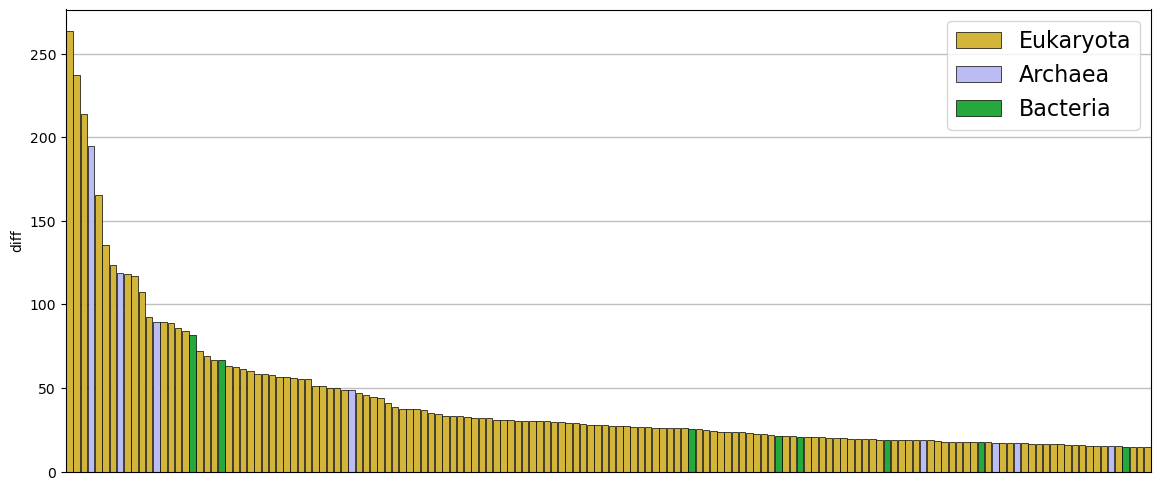

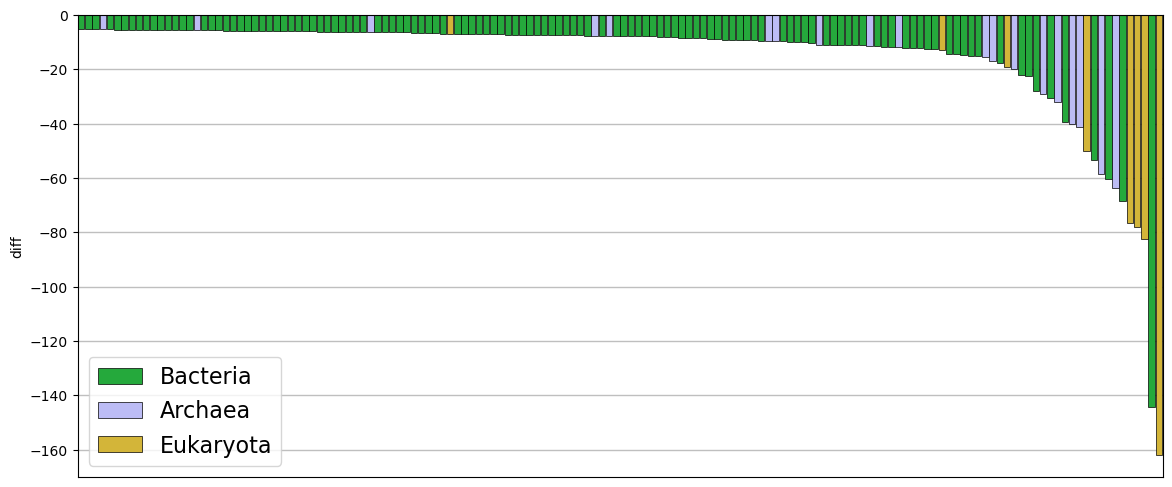

In [147]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6))

sns.barplot(data=decrease_df.with_columns(species_taxid=pl.col("species_taxid").cast(pl.Utf8)).head(150).sort(["diff"], descending=True),
            y="diff",
            hue="domain",
            palette=domain_colors,
            dodge=False,
            width=0.9,
            ax=ax,
            edgecolor="black",
            linewidth=0.5,
            x="species_taxid")
ax.set_xticks([])
# ax.set_ylim(ymin=-20, ymax=20)
ax.grid(lw=1.0, alpha=0.8, zorder=0, axis='y')
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.legend(title="", prop={"size": 16})
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6))

sns.barplot(data=decrease_df.with_columns(species_taxid=pl.col("species_taxid").cast(pl.Utf8)).tail(150).sort(["diff"], descending=True),
            y="diff",
            hue="domain",
            palette=domain_colors,
            dodge=False,
            width=0.9,
            ax=ax,
            edgecolor="black",
            linewidth=0.5,
            x="species_taxid")
ax.set_xticks([])
# ax.set_ylim(ymin=-20, ymax=20)
ax.grid(lw=1.0, alpha=0.8, zorder=0, axis='y')
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.legend(title="", prop={"size": 16})
plt.show()

In [166]:
comparison_df_avg.melt(id_vars=["species_taxid", "partition", "domain"], 
                       value_vars=["fold_enrichment", "fold_enrichment_corrected"], 
                       value_name="enrichment")

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/3466051369.py:1: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  comparison_df_avg.melt(id_vars=["species_taxid", "partition", "domain"],


species_taxid,partition,domain,variable,enrichment
i64,str,str,str,f64
28875,""".""","""Viruses""","""fold_enrichment""",0.38901
2928988,""".""","""Viruses""","""fold_enrichment""",0.0
813,""".""","""Bacteria""","""fold_enrichment""",0.819216
562,""".""","""Bacteria""","""fold_enrichment""",0.848748
12305,""".""","""Viruses""","""fold_enrichment""",-0.016064
…,…,…,…,…
2844048,""".""","""Viruses""","""fold_enrichment_corrected""",0.0
2844689,""".""","""Viruses""","""fold_enrichment_corrected""",1.0
2845045,""".""","""Viruses""","""fold_enrichment_corrected""",0.0


In [167]:
mini = comparison_df_avg.filter(pl.col("domain") == "Eukaryota")["fold_enrichment_corrected"].min()
comparison_df_avg.filter(pl.col("domain") == "Eukaryota",
                         pl.col("fold_enrichment_corrected") == mini
                         )

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
27973,""".""",-0.403015,-0.403015,"""Eukaryota""",0.079774,0.201036,"""Encephalitozoon hellem""","""Fungi""","""Microsporidia""",431,1087,0,0,0.08,0.201


In [168]:
comparison_df_avg.filter(pl.col("kingdom") == "Plantae",
                         pl.col("fold_enrichment_corrected") > pl.col("fold_enrichment")
                         )

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
4641,""".""",0.600592,0.677776,"""Eukaryota""",5.911135,1.135259,"""Musa acuminata subsp. malaccen…","""Plantae""","""Streptophyta""",9209453,2099272,8406529,2417169,9.797,2.233


In [204]:
effect_size_reduction

name,rank,partition,hedges_g_no_STR,cliffs_delta_no_STR,pval_no_STR,hedges_g,cliffs_delta,pval,effect_size_reduction,cliffs_delta_change
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""Bacteria""","""domain""",0,0.381911,0.969329,0.0,0.382758,0.966271,0.0,-0.221504,0.316485
"""Bacteria""","""domain""",1,0.923772,0.952689,0.0,0.902879,0.95224,0.0,2.314062,0.047228
"""Bacteria""","""domain""",2,1.208867,0.968969,0.0,1.194129,0.96816,0.0,1.234238,0.083612
"""Bacteria""","""domain""",3,0.954048,0.966001,0.0,0.948885,0.965371,0.0,0.544142,0.065219
"""Bacteria""","""domain""",4,1.56878,0.985249,0.0,1.562962,0.985159,0.0,0.372243,0.00913
"""Bacteria""","""domain""",5,1.614491,0.980572,0.0,1.602653,0.980572,0.0,0.738659,0.0
"""Bacteria""","""domain""",6,1.489389,0.980662,0.0,1.482878,0.980302,0.0,0.439123,0.036701
"""Bacteria""","""domain""",7,1.312926,0.969689,0.0,1.302085,0.968699,0.0,0.832591,0.102136
"""Bacteria""","""domain""",8,1.303949,0.966901,0.0,1.297137,0.966721,0.0,0.525141,0.018608


In [ ]:
effect_size_reduction = defaultdict(list)

kingdoms = ["Fungi", "Protista", "Plantae", "Metazoa"]
domains = ["Bacteria", "Archaea", "Eukaryota", "Viruses"]
categories = [(domain, "domain") for domain in domains] + [(kingdom, "kingdom") for kingdom in kingdoms]

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, None] > y[None, :])
    less = np.sum(x[:, None] < y[None, :])
    return (greater - less) / (n1 * n2)

def cles_from_mwu(x, y):
    mwu_statistic, _ = mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    cles = mwu_statistic / (n1 * n2)
    cles = 2 * cles - 1
    return cles

def calculate_paired_hedges(x, y):
    d = np.array(x) - np.array(y)
    n = len(d)
    mean_diff = np.mean(d)
    sd_diff = np.std(d, ddof=1)
    cohen_d = mean_diff / sd_diff
    correction = 1 - (3 / (4 * n - 5))
    hedges_g = cohen_d * correction
    return hedges_g

def calculate_paired_cliffs(x, y):
    d = np.array(x) - np.array(y)
    n = len(d)
    greater = ( np.sum(d > 0) + 0.5 * np.sum(d == 0) ) / n
    cliffs_delta = 2 * greater - 1
    return cliffs_delta

partition_list = range(0, 9)
for category, rank in categories:
    for partition in partition_list:
        obs = (
                        comparison_df_avg
                        .filter(pl.col("partition") == str(partition))
                        .filter(pl.col(rank) == category)[f"density_{pattern}_corrected"]
                        .to_pandas()
            )
        ctrl = (
                    comparison_df_avg.filter(pl.col("partition") == str(partition))
                    .filter(pl.col(rank) == category)[f"density_{pattern}_control_corrected"]
                    .to_pandas()
        )

        result = wilcoxon(obs, ctrl, alternative="two-sided")
        delta = calculate_paired_cliffs(obs, ctrl)
        g = calculate_paired_hedges(obs, ctrl)

        effect_size_reduction["name"].append(category)
        effect_size_reduction["rank"].append(rank)
        if category in kingdoms:
            effect_size_reduction["domain"].append("Eukaryota")
        else:
            effect_size_reduction["domain"].append(category)
        # # #
        effect_size_reduction["partition"].append(partition)
        effect_size_reduction["hedges_g_no_STR"].append(g)
        effect_size_reduction["cliffs_delta_no_STR"].append(delta)
        effect_size_reduction["pval_no_STR"].append(result.pvalue)

        obs = comparison_df_avg.filter(pl.col("partition") == str(partition)).filter(pl.col(rank) == category)[f"density_{pattern}"].to_pandas()
        ctrl = comparison_df_avg.filter(pl.col("partition") == str(partition)).filter(pl.col(rank) == category)[f"density_{pattern}_control"].to_pandas()

        result = wilcoxon(obs, ctrl, alternative="two-sided")
        delta = calculate_paired_cliffs(obs, ctrl)
        g = calculate_hedges(obs, ctrl)
        effect_size_reduction["hedges_g"].append(g)
        effect_size_reduction["cliffs_delta"].append(delta)
        effect_size_reduction["pval"].append(result.pvalue)

effect_size_reduction = pl.from_pandas(pd.DataFrame(effect_size_reduction)) \
    .with_columns(
        effect_size_reduction=(
            (pl.col("hedges_g_no_STR") - pl.col("hedges_g"))
            / pl.col("hedges_g") * 100
        ),
        cliffs_delta_change=(
            (pl.col("cliffs_delta_no_STR") - pl.col("cliffs_delta"))
            / pl.col("cliffs_delta") * 100
        )
    )

effect_size_reduction.select(["name", "domain", "partition", "hedges_g", "hedges_g_no_STR", "effect_size_reduction",
                             "cliffs_delta", "cliffs_delta_no_STR", "cliffs_delta_change",
                             "pval", "pval_no_STR"]).filter(pl.col("domain") == "Eukaryota").to_pandas().head(40)

,name,domain,partition,hedges_g,hedges_g_no_STR,effect_size_reduction,cliffs_delta,cliffs_delta_no_STR,cliffs_delta_change,pval,pval_no_STR
0,Eukaryota,Eukaryota,0,0.252054,0.378652,50.226438,0.972414,0.927586,-4.609929,6.848427e-49,2.154343e-48
1,Eukaryota,Eukaryota,1,0.394517,0.324407,-17.771150,0.893103,0.831034,-6.949807,4.793356e-47,2.196087e-44
2,Eukaryota,Eukaryota,2,0.309306,0.247394,-20.016499,0.827586,0.775862,-6.250000,4.615343e-45,1.832931e-42
3,Eukaryota,Eukaryota,3,0.615503,0.614029,-0.239377,0.734483,0.693103,-5.633803,8.598178e-40,7.613493e-37
4,Eukaryota,Eukaryota,4,0.569218,0.534555,-6.089594,0.744828,0.706897,-5.092593,1.103062e-41,2.609598e-39
5,Eukaryota,Eukaryota,5,0.655528,0.636462,-2.908483,0.789655,0.768966,-2.620087,3.965409e-43,1.364212e-41
6,Eukaryota,Eukaryota,6,0.633394,0.629316,-0.643751,0.841379,0.793103,-5.737705,2.328242e-44,3.106547e-43
7,Eukaryota,Eukaryota,7,0.507416,0.589615,16.199689,0.762069,0.734483,-3.619910,4.275807e-42,1.565419e-39
8,Eukaryota,Eukaryota,8,0.177535,0.139400,-21.479965,0.775862,0.751724,-3.111111,5.031483e-43,1.125741e-40
9,Fungi,Eukaryota,0,0.928113,1.002467,8.011336,0.966981,0.905660,-6.341463,2.984520e-36,1.192442e-35


In [ ]:
effect_size_reduction = defaultdict(list)
kingdoms = ["Fungi", "Protista", "Plantae", "Metazoa"]
categories = [(domain, "domain") for domain in domains] + [(kingdom, "kingdom") for kingdom in kingdoms]

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, None] > y[None, :])
    less = np.sum(x[:, None] < y[None, :])
    return (greater - less) / (n1 * n2)

def cles_from_mwu(x, y):
    mwu_statistic, _ = mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    cles = mwu_statistic / (n1 * n2)
    cles = 2 * cles - 1
    return cles

def calculate_paired_hedges(x, y):
    d = np.array(x) - np.array(y)
    n = len(d)
    mean_diff = np.mean(d)
    sd_diff = np.std(d, ddof=1)
    cohen_d = mean_diff / sd_diff
    correction = 1 - (3 / (4 * n - 5))
    hedges_g = cohen_d * correction
    return hedges_g

def calculate_paired_cliffs(x, y):
    d = np.array(x) - np.array(y)
    n = len(d)
    greater = ( np.sum(d > 0) + 0.5 * np.sum(d == 0) ) / n
    cliffs_delta = 2 * greater - 1
    return cliffs_delta

for category, rank in categories:
    obs = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}_corrected"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}_control_corrected"].to_pandas()

    result = wilcoxon(obs, ctrl, alternative="two-sided")
    delta = calculate_paired_cliffs(obs, ctrl)
    g = calculate_paired_hedges(obs, ctrl)

    effect_size_reduction["name"].append(category)
    effect_size_reduction["rank"].append(rank)
    effect_size_reduction["hedges_g_no_STR"].append(g)
    effect_size_reduction["cliffs_delta_no_STR"].append(delta)
    effect_size_reduction["pval_no_STR"].append(result.pvalue)

    obs = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}_control"].to_pandas()

    result = wilcoxon(obs, ctrl, alternative="two-sided")
    delta = calculate_paired_cliffs(obs, ctrl)
    g = calculate_hedges(obs, ctrl)
    effect_size_reduction["hedges_g"].append(g)
    effect_size_reduction["cliffs_delta"].append(delta)
    effect_size_reduction["pval"].append(result.pvalue)

effect_size_reduction = pl.from_pandas(pd.DataFrame(effect_size_reduction)) \
    .with_columns(
        effect_size_reduction=(
            (pl.col("hedges_g_no_STR") - pl.col("hedges_g"))
            / pl.col("hedges_g") * 100
        ),
        cliffs_delta_change=(
            (pl.col("cliffs_delta_no_STR") - pl.col("cliffs_delta"))
            / pl.col("cliffs_delta") * 100
        )
    )

effect_size_reduction.select(["name", "hedges_g", "hedges_g_no_STR", "effect_size_reduction",
                             "cliffs_delta", "cliffs_delta_no_STR", "cliffs_delta_change",
                             "pval", "pval_no_STR"])

name,hedges_g,hedges_g_no_STR,effect_size_reduction,cliffs_delta,cliffs_delta_no_STR,cliffs_delta_change,pval,pval_no_STR
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Bacteria""",1.574347,1.589454,0.959581,0.990106,0.990106,0.0,0.0,0.0
"""Eukaryota""",0.435404,0.399098,-8.338481,0.924138,0.862069,-6.716418,1.9402e-48,4.6119e-47
"""Archaea""",0.70172,0.69872,-0.427581,0.912879,0.909091,-0.414938,1.7311e-85,1.6052e-85
"""Viruses""",0.328918,0.326602,-0.703844,0.396597,0.394915,-0.424261,0.0,0.0
"""Fungi""",0.810177,0.672712,-16.967326,0.896226,0.820755,-8.421053,2.3658e-35,9.4854e-34
"""Protista""",0.333554,0.697828,109.209791,1.0,0.904762,-9.52381,9.5367e-7,0.000002
"""Plantae""",1.408006,1.608775,14.259088,1.0,1.0,0.0,5.8208e-11,5.8208e-11
"""Metazoa""",0.715413,0.437178,-38.891521,1.0,1.0,0.0,4.7684e-7,4.7684e-7


In [183]:
comparison_df_avg.filter(pl.col("domain") == "Eukaryota", pl.col(f"density_{pattern}_corrected") >= pl.col(f"density_{pattern}_control_corrected"))

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
151069,""".""",0.80228,0.716434,"""Eukaryota""",4.174352,0.689487,"""Litchi chinensis""","""Plantae""","""Streptophyta""",7760750,966590,3102724,21815,5.639,0.702333
4932,""".""",0.557342,0.353237,"""Eukaryota""",0.866883,0.408287,"""Saccharomyces cerevisiae""","""Fungi""","""Ascomycota""",359507,114600,171478,3687,1.311261,0.418043
392538,""".""",0.162962,0.073241,"""Eukaryota""",0.407009,0.351458,"""Salmacisia buchloeana""","""Fungi""","""Basidiomycota""",9272,7052,1647,12,0.462,0.352
3076,""".""",0.387189,0.326723,"""Eukaryota""",1.382603,0.701635,"""Chlorella sorokiniana""","""Plantae""","""Chlorophyta""",60326,27381,8595,289,1.562,0.709
27337,""".""",0.365344,0.353509,"""Eukaryota""",1.283917,0.614032,"""Verticillium dahliae VdLs.17""","""Fungi""","""Ascomycota""",97866,46130,6962,2047,1.357,0.6395
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
648681,""".""",0.254622,0.24229,"""Eukaryota""",0.291798,0.177976,"""Clitopilus hobsonii""","""Fungi""","""Basidiomycota""",10995,6572,287,0,0.298,0.178
334518,""".""",0.521995,0.424278,"""Eukaryota""",0.499598,0.201947,"""Allantophomopsis lycopodina""","""Fungi""","""Ascomycota""",20733,6851,4895,12,0.612,0.202
76774,""".""",0.108848,0.116382,"""Eukaryota""",1.238759,0.98048,"""Malassezia obtusa""","""Fungi""","""Basidiomycota""",10951,8811,984,914,1.34,1.079


In [182]:
comparison_df_avg.filter(pl.col("domain") == "Eukaryota", pl.col(f"density_{pattern}") >= pl.col(f"density_{pattern}_corrected"))

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
151069,""".""",0.80228,0.716434,"""Eukaryota""",4.174352,0.689487,"""Litchi chinensis""","""Plantae""","""Streptophyta""",7760750,966590,3102724,21815,5.639,0.702333
4932,""".""",0.557342,0.353237,"""Eukaryota""",0.866883,0.408287,"""Saccharomyces cerevisiae""","""Fungi""","""Ascomycota""",359507,114600,171478,3687,1.311261,0.418043
392538,""".""",0.162962,0.073241,"""Eukaryota""",0.407009,0.351458,"""Salmacisia buchloeana""","""Fungi""","""Basidiomycota""",9272,7052,1647,12,0.462,0.352
3076,""".""",0.387189,0.326723,"""Eukaryota""",1.382603,0.701635,"""Chlorella sorokiniana""","""Plantae""","""Chlorophyta""",60326,27381,8595,289,1.562,0.709
27337,""".""",0.365344,0.353509,"""Eukaryota""",1.283917,0.614032,"""Verticillium dahliae VdLs.17""","""Fungi""","""Ascomycota""",97866,46130,6962,2047,1.357,0.6395
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
334518,""".""",0.521995,0.424278,"""Eukaryota""",0.499598,0.201947,"""Allantophomopsis lycopodina""","""Fungi""","""Ascomycota""",20733,6851,4895,12,0.612,0.202
76774,""".""",0.108848,0.116382,"""Eukaryota""",1.238759,0.98048,"""Malassezia obtusa""","""Fungi""","""Basidiomycota""",10951,8811,984,914,1.34,1.079
1268659,""".""",0.09465,-0.130095,"""Eukaryota""",0.183681,0.23862,"""Kwoniella botswanensis""","""Fungi""","""Basidiomycota""",5998,5500,2424,10,0.261,0.239


In [ ]:
comparison_df_avg.filter(pl.col("fold_enrichment_corrected") >= pl.col("fold_enrichment"), 
                         pl.col("domain") == "Eukaryota")

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_IR_corrected,density_IR_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
27973,""".""",-0.403015,-0.403015,"""Eukaryota""",0.079774,0.201036,"""Encephalitozoon hellem""","""Fungi""","""Microsporidia""",431,1087,0,0,0.08,0.201
1821823,""".""",0.078582,0.078582,"""Eukaryota""",0.232219,0.198381,"""Malassezia psittaci""","""Fungi""","""Basidiomycota""",1901,1624,0,0,0.232,0.198
186038,""".""",1.0,1.0,"""Eukaryota""",2.543285,0.0,"""Fragilariopsis kerguelensis""","""Protista""","""Bacillariophyta""",26,0,0,0,2.543,0.0
156630,""".""",-0.015075,-0.013858,"""Eukaryota""",0.287722,0.295809,"""Alternaria arborescens""","""Fungi""","""Ascomycota""",686,707,10,12,0.292,0.301
4641,""".""",0.600592,0.677776,"""Eukaryota""",5.911135,1.135259,"""Musa acuminata subsp. malaccen…","""Plantae""","""Streptophyta""",9209453,2099272,8406529,2417169,9.797,2.233
58839,""".""",-0.270073,-0.270073,"""Eukaryota""",0.095806,0.166702,"""Encephalitozoon intestinalis""","""Fungi""","""Microsporidia""",250,435,0,0,0.096,0.167
116153,""".""",0.609829,0.631795,"""Eukaryota""",45.613631,10.292459,"""Aethina tumida""","""Metazoa""","""Arthropoda""",8901690,2840025,766870,384178,34.242,10.925
6035,""".""",-0.069817,-0.069817,"""Eukaryota""",0.152077,0.174907,"""Encephalitozoon cuniculi""","""Fungi""","""Microsporidia""",433,498,0,0,0.152,0.175
1821822,""".""",0.233712,0.240898,"""Eukaryota""",1.167329,0.714097,"""Malassezia brasiliensis""","""Fungi""","""Basidiomycota""",10155,6276,981,697,1.269,0.784


In [ ]:
def paired_rank_biserial(x, y):
    d = np.asarray(x) - np.asarray(y)
    d = d[d != 0]
    ranks = rankdata(np.abs(d))
    W_pos = ranks[d > 0].sum()
    W_neg = ranks[d < 0].sum()
    return (W_pos - W_neg) / (W_pos + W_neg)


def calculate_paired_hedges(obs, ctrl):
    diffs = obs - ctrl
    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs, ddof=1)
    d = mean_diff / sd_diff if sd_diff else np.nan
    n = len(diffs)
    J = 1.0 - (3.0 / (4 * (n - 1) - 1)) if n > 1 else 1.0
    g = d * J
    return g 
    
phylum_stat_assessed_STR = defaultdict(list) 
wilcoxon_results_phyla = {}
hedges_g_phyla = {}
partition_list = list(map(str, range(0, 9))) + ["."]

for phylum in phyla:
    for partition in ["."]:
        temp_df = comparison_df_avg.filter(pl.col("partition") == partition, pl.col("phylum") == phylum)
        obs = temp_df[f"density_{pattern}_corrected"].to_pandas()
        ctrl = temp_df[f"density_{pattern}_control_corrected"].to_pandas()
        assert len(obs) == len(ctrl)
        if len(obs) < 5:
            print(f"Skipping {phylum} with n={len(obs)}.")
            continue
        
        # Per Species within Phylum Comparison
        res = wilcoxon(obs, ctrl, alternative="two-sided")
        stat, p_val = res.statistic, res.pvalue
        wilcoxon_results_phyla[phylum] = (t_stat, p_val)

        # Hedges' g calculation
        g_corrected = calculate_paired_hedges(obs, ctrl)
        wilcoxon_results_phyla[phylum] = g_corrected
        cles = cles_from_mwu(obs, ctrl)
        biserial = paired_rank_biserial(obs, ctrl)
        diff = np.mean(obs - ctrl)

        phylum_stat_assessed_STR["partition"].append(partition)
        phylum_stat_assessed_STR["phylum"].append(phylum)
        phylum_stat_assessed_STR["n_obs"].append(n1)
        phylum_stat_assessed_STR["n_ctrl"].append(n2)
        phylum_stat_assessed_STR["mean_obs"].append(np.mean(obs))
        phylum_stat_assessed_STR["mean_ctrl"].append(np.mean(ctrl))
        phylum_stat_assessed_STR["std_obs"].append(s1)
        phylum_stat_assessed_STR["std_ctrl"].append(s2)
        phylum_stat_assessed_STR["diff"].append(diff)
        phylum_stat_assessed_STR["biserial"].append(biserial)


        # All
        obs_with_STR = temp_df[f"density_{pattern}"].to_pandas()
        ctrl_with_STR = temp_df[f"density_{pattern}_control"].to_pandas()

        result_with_STR = wilcoxon(obs_with_STR, ctrl_with_STR, alternative="two-sided")
        delta_with_STR = cles_from_mwu(obs_with_STR, ctrl_with_STR)
        g_with_STR = calculate_paired_hedges(obs_with_STR, ctrl_with_STR)
        diff_with_STR = np.mean(obs_with_STR - ctrl_with_STR)
        biserial_with_STR = paired_rank_biserial(obs_with_STR, ctrl_with_STR)
        phylum_stat_assessed_STR["diff_with_STR"].append(diff_with_STR)

        # With STR
        phylum_stat_assessed_STR["hedges_g_with_STR"].append(g_with_STR)
        phylum_stat_assessed_STR["cliffs_delta_with_STR"].append(delta_with_STR)
        phylum_stat_assessed_STR["pvalue_with_STR"].append(result_with_STR.pvalue)

        # Without STR
        phylum_stat_assessed_STR["hedges_g"].append(g_corrected)
        phylum_stat_assessed_STR["pvalue"].append(p_val)
        phylum_stat_assessed_STR["cles"].append(cles)
        phylum_stat_assessed_STR["biserial_with_STR"].append(biserial_with_STR)

        # Changes

        phylum_stat_assessed_STR["effect_size_change"].append(
            (g_corrected - g_with_STR) / g_with_STR * 100
        )
        phylum_stat_assessed_STR["cles_change"].append(
            (cles - delta_with_STR) / delta_with_STR * 100
        )


# Adjustment for multiple hypothesis Testing using Benjamini-Hochberg procedure
pvals = np.array(phylum_stat_assessed_STR["pvalue"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
phylum_stat_assessed_STR["pvalue_adj_corrected"] = pvals_fdr
phylum_stat_assessed_STR["significant"] = reject

# with STR 
pvals = np.array(phylum_stat_assessed_STR["pvalue_with_STR"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
phylum_stat_assessed_STR["pvalue_with_STR"] = pvals_fdr
phylum_stat_assessed_STR["significant"] = reject

# # Merge
phylum_stat_assessed_STR = pd.DataFrame(phylum_stat_assessed_STR).merge(
    mean_density_phyla[["phylum", "domain", "kingdom", "total_species"]],
    how="left",
    on="phylum"
).sort_values(by=["hedges_g", "biserial"], ascending=False)
phylum_stat_assessed_STR.to_csv(f"{target}/{pattern}_phylum_statistical_assessment_with_and_without_STR.csv", index=False, mode="w")
phylum_stat_assessed_STR.dropna(subset=["phylum"], inplace=True)
phylum_stat_assessed_STR[["phylum", "hedges_g", "hedges_g_with_STR", "effect_size_change", "pvalue_adj_corrected", "cles", "cliffs_delta_with_STR", "cles_change", "pvalue_with_STR", "biserial", "biserial_with_STR"]].head(50)

Skipping Minisyncoccota with n=1.
Skipping Candidatus Krumholzibacteriota with n=1.
Skipping Candidatus Bipolaricaulota with n=2.
Skipping Candidatus Auribacterota with n=1.
Skipping Vulcanimicrobiota with n=2.
Skipping Bacillariophyta with n=1.
Skipping Candidatus Falkowiibacteriota with n=1.
Skipping Mucoromycota with n=1.
Skipping Candidatus Micrarchaeota with n=4.
Skipping Candidatus Altimarinota with n=3.
Skipping Candidatus Nanohalarchaeota with n=3.
Skipping Candidatus Kapaibacteriota with n=1.
Skipping Thermodesulfobiota with n=2.
Skipping Candidatus Sumerlaeota with n=1.
Skipping Balneolota with n=2.
Skipping Candidatus Tectimicrobiota with n=1.
Skipping Dictyoglomota with n=2.
Skipping Nanobdellota with n=3.
Skipping Candidatus Melainabacteria with n=2.
Skipping Promethearchaeota with n=2.
Skipping Candidatus Uhriibacteriota with n=1.
Skipping Candidatus Binatota with n=2.
Skipping Candidatus Wolfeibacteriota with n=1.
Skipping Thermosulfidibacterota with n=1.
Skipping Candid

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/4026992321.py:87: RuntimeWarning: invalid value encountered in scalar divide
  (cles - delta_with_STR) / delta_with_STR * 100


,phylum,hedges_g,hedges_g_with_STR,effect_size_change,pvalue_adj_corrected,cles,cliffs_delta_with_STR,cles_change,pvalue_with_STR,biserial,biserial_with_STR
39,Chlorobiota,5.795388,5.751647,0.760495,2.164619e-05,1.000000,1.000000,0.000000,2.216157e-05,1.000000,1.000000
60,Chordata,3.753208,1.123786,233.979030,3.309462e-04,1.000000,1.000000,0.000000,3.309462e-04,1.000000,1.000000
52,Ignavibacteriota,3.483343,3.457640,0.743354,1.702009e-02,1.000000,1.000000,0.000000,1.702009e-02,1.000000,1.000000
22,Nitrospirota,3.450998,3.408959,1.233202,2.837763e-06,1.000000,1.000000,0.000000,2.983289e-06,1.000000,1.000000
58,Chlamydiota,3.103847,3.121747,-0.573414,1.336722e-08,1.000000,1.000000,0.000000,5.634142e-06,1.000000,1.000000
54,Synergistota,2.774379,2.760950,0.486393,8.461692e-05,1.000000,1.000000,0.000000,8.461692e-05,1.000000,1.000000
40,Lentisphaerota,2.635564,2.619187,0.625297,1.702009e-02,1.000000,1.000000,0.000000,1.702009e-02,1.000000,1.000000
34,Bdellovibrionota,2.615541,2.602111,0.516102,1.454353e-06,0.972789,0.972789,0.000000,1.530898e-06,1.000000,1.000000
3,Chloroflexota,2.379044,2.350927,1.196003,9.565375e-13,0.990930,0.990930,0.000000,2.955644e-08,1.000000,1.000000
51,Bacteroidota,2.238815,2.121311,5.539225,8.262551e-148,0.992326,0.992027,0.030117,8.262184e-148,1.000000,1.000000


In [197]:
data["kingdom_reduced"].unique()

kingdom_reduced
str
"""Protista"""
"""Plantae"""
"""Archaea"""
"""Viruses"""
"""Metazoa"""
"""Bacteria"""
"""Fungi"""


/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_38626/496907042.py:9: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  ).melt(


domain Bacteria
Bacteria (domain):  -0.22387119985608928
domain Archaea
Archaea (domain):  0.23106060606060597
kingdom Fungi
Fungi (kingdom):  0.9528301886792452
kingdom Protista
Protista (kingdom):  0.9523809523809523
kingdom Plantae
Plantae (kingdom):  0.9428571428571428
kingdom Metazoa
Metazoa (kingdom):  0.9090909090909092
domain Viruses
Viruses (domain):  0.018820303492973478
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Protista_fold_enrichment vs. Protista_fold_enrichment_corrected: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:8.857e-05 Stat=0.000e+00
Fungi_fold_enrichment vs. Fungi_fold_enrichment_corrected: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.383e-35 Stat=4.700e+01
Plantae_fold_enrichment vs. Plantae_fold_enrichment_corrected: Wilcoxon test (paired samples) with Benja

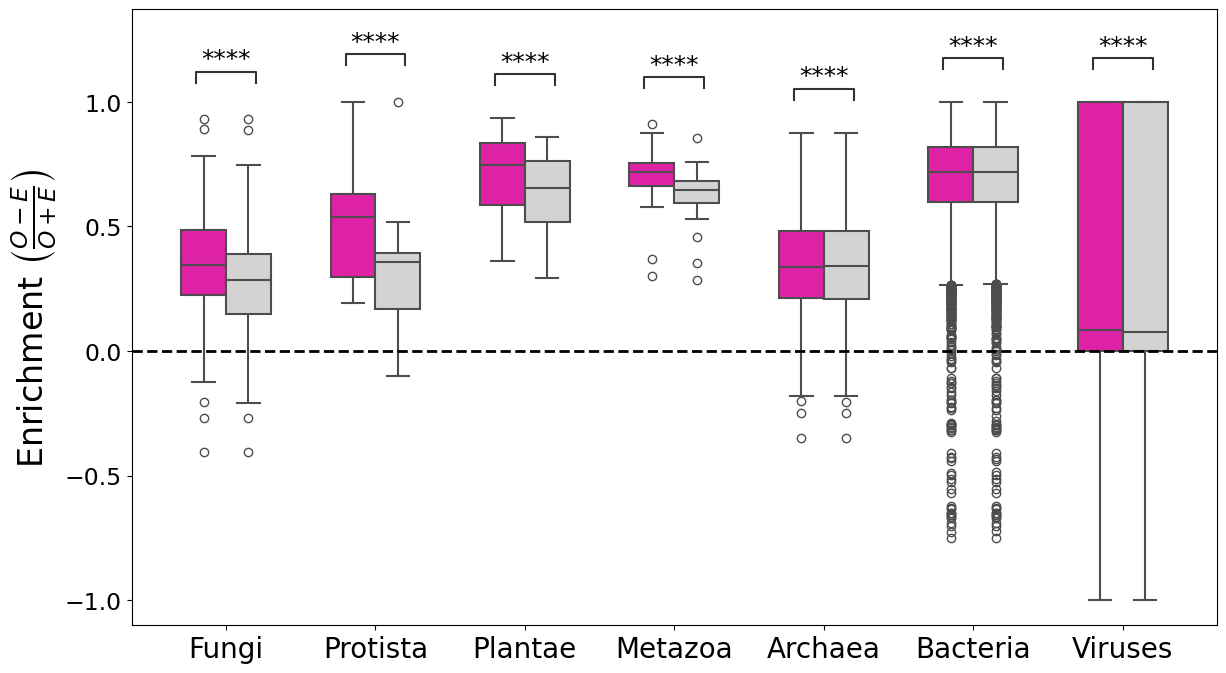

In [199]:
def reduce_kingdoms(row):
    if row["domain"] != "Eukaryota":
        return row["domain"]
    
    return row["kingdom"]

data = comparison_df_avg.with_columns(
            kingdom_reduced=pl.struct(["kingdom", "domain"]).map_elements(reduce_kingdoms, return_dtype=pl.Utf8)
        ).melt(
                id_vars=["species_taxid", "partition", "kingdom_reduced"],
                value_vars=["fold_enrichment", "fold_enrichment_corrected"],
                value_name="enrichment"
        )


domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
kingdoms = [("Bacteria", "domain"), 
            ("Archaea", "domain"), 
            ("Fungi", "kingdom"), 
            ("Protista", "kingdom"), 
            ("Plantae", "kingdom"),
            ("Metazoa", "kingdom"), 
            ("Viruses", "domain")
            ]
for name, rank in kingdoms:
    print(rank, name)
    obs = comparison_df_avg.filter(pl.col(rank) == name)[f"fold_enrichment"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col(rank) == name)[f"fold_enrichment_corrected"].to_pandas()

    result = calculate_paired_cliffs(obs, ctrl)
    print(f"{name} ({rank}): ", result)
order = ["Fungi", "Protista", "Plantae", "Metazoa", "Archaea", "Bacteria", "Viruses"]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 8))
ax = sns.boxplot(
    data=data.to_pandas(),
    x="kingdom_reduced",
    y="enrichment",
    ax=ax,
    hue="variable",
    palette=["#fc03b1", "lightgray"],
    width=0.6,
    linewidth=1.5,
    order=["Fungi", "Protista", "Plantae", "Metazoa", "Archaea", "Bacteria", "Viruses"],
    hue_order=["fold_enrichment", "fold_enrichment_corrected"]
)

ax.axhline(0, color='black', zorder=5, linestyle='--', linewidth=2)
ax.set_ylabel(r"$\text{Enrichment } \left( \frac{O - E}{O + E} \right)$", fontsize=20)
ax.set_xlabel("")
ax.yaxis.label.set_size(24)
ax.xaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=17)
ax.tick_params(axis="x", labelsize=20, zorder=0)
ax.legend(handles=[], frameon=False)

pairs = [
    ("Plantae", "fold_enrichment"),
    ("Plantae", "fold_enrichment_corrected"),
    ("Archaea", "fold_enrichment"),
    ("Archaea", "fold_enrichment_corrected"),
    ("Bacteria", "fold_enrichment"),
    ("Bacteria", "fold_enrichment_corrected"),
    ("Viruses", "fold_enrichment"),
    ("Viruses", "fold_enrichment_corrected")
]
pairs = [
        (("Fungi", "fold_enrichment"), ("Fungi", "fold_enrichment_corrected")),
    (("Protista", "fold_enrichment"), ("Protista", "fold_enrichment_corrected")),
    (("Plantae", "fold_enrichment"), ("Plantae", "fold_enrichment_corrected")),
    (("Metazoa", "fold_enrichment"), ("Metazoa", "fold_enrichment_corrected")),
    (("Archaea", "fold_enrichment"), ("Archaea", "fold_enrichment_corrected")),
    (("Bacteria", "fold_enrichment"), ("Bacteria", "fold_enrichment_corrected")),
    (("Viruses", "fold_enrichment"), ("Viruses", "fold_enrichment_corrected")),
]

annotator = Annotator(ax, 
                      pairs, 
                      data=data.to_pandas(), 
            x="kingdom_reduced", 
            y="enrichment", 
            hue="variable", 
            order=order,
hue_order=["fold_enrichment", "fold_enrichment_corrected"])

annotator.configure(test='Wilcoxon', 
                    text_format='star', 
                    loc='inside', 
                    comparisons_correction='fdr_bh', 
                    fontsize=18, 
                    text_offset=-0.05)
annotator.apply_and_annotate()

target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
plt.savefig(f"{target}/fold_enrichment_{pattern}_all_domains.pdf", transparent=True, bbox_inches="tight")
plt.show()


## Statistical Comparison

In [285]:
alpha = 0.025
quantiles_df = comparison_df_all.group_by(["domain"]).agg(
                                           pl.col(f"density_{pattern}").quantile(alpha/2).alias("lower_ci"),
                                           pl.col(f"density_{pattern}").quantile(1-alpha/2).alias("upper_ci"),
                                           pl.col(f"density_{pattern}_control").quantile(alpha/2).alias("lower_ci_control"),
                                           pl.col(f"density_{pattern}_control").quantile(1-alpha/2).alias("upper_ci_control")
                                           )
quantiles_df

domain,lower_ci,upper_ci,lower_ci_control,upper_ci_control
str,f64,f64,f64,f64
"""Eukaryota""",0.181,9.797,0.175,2.4105
"""Bacteria""",0.738,8.605667,0.166,1.808
"""Viruses""",0.0,18.235,0.0,2.959
"""Archaea""",0.249,4.453,0.136,1.488


# Repeating Unit Comparison

In [64]:
def calculate_enrichment(row):
    o, e = None, None
    for key, value in row.items():
        if "control" in key:
            e = value
        else:
            o = value
    if o == e:
        return 0.0
    return (o-e)/(o+e)

comparison_df_general = (
            comparison_df.filter(pl.col("partition") == ".")
                .select([
                        "#assembly_accession", 
                        "species_taxid", 
                        "partition",
                        "organism_name", 
                        "domain", 
                        "phylum",
                        "kingdom",
                        "genome_size",
                        f"density_{pattern}", 
                        f"density_{pattern}_control", 
                        "total_bp",
                        "total_bp_control",
                        "fold_enrichment", 
                        "pvalue", 
                        "significance"
                    ])
)
comparison_df_general

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,pvalue,significance
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,f64,str
"""GCA_002637055.1""",28875,""".""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,1.376,0.0,24,0,1.0,1.1827e-7,"""****"""
"""GCA_031311805.1""",2928988,""".""","""Wenzhou Rattus losea jeilongvi…","""Viruses""","""Negarnaviricota""","""Orthornavirae""",18077,0.0,0.0,0,0,0.0,1.0,"""ns"""
"""GCF_000441655.1""",813,""".""","""Chlamydia trachomatis RC-J/943""","""Bacteria""","""Chlamydiota""","""Pseudomonadati""",1038797,2.665,0.248,2768,258,0.829729,0.0,"""****"""
"""GCA_029720955.1""",562,""".""","""Escherichia coli""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",4847823,2.618,0.196,12690,952,0.860697,0.0,"""****"""
"""GCA_003129245.1""",12305,""".""","""Cucumber mosaic virus""","""Viruses""","""Kitrinoviricota""","""Orthornavirae""",8511,0.0,0.0,0,0,0.0,1.0,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_003008555.2""",2605946,""".""","""Pukyongiella litopenaei""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",4262966,1.566,0.643,6675,2741,0.417836,0.0,"""****"""
"""GCF_016128055.1""",1254,""".""","""Pediococcus acidilactici""","""Bacteria""","""Bacillota""","""Bacillati""",2009583,2.342,0.233,4706,468,0.819029,0.0,"""****"""
"""GCA_902990965.1""",2100421,""".""","""uncultured Caudovirales phage""","""Viruses""","""Uroviricota""","""Heunggongvirae""",15402,0.0,3.181,0,49,-1.0,3.4194e-15,"""****"""


In [65]:
indir = Path("../data").resolve()
# comparison_df = pl.read_csv(indir / "group_comparison_STR_density_accessions.sru.csv.gz")
comparison_df_partition = comparison_df_avg.filter(pl.col("partition") != ".")
viral_kingdoms = set(comparison_df.filter(pl.col("domain") == "Viruses")["kingdom"])
comparison_df_partition = comparison_df.with_columns(kingdom_n=pl.col("kingdom").map_elements(lambda x: "Viruses" if x in viral_kingdoms else x, return_dtype=pl.Utf8))
comparison_df_partition

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,odds,pvalue,significance,reduced_significance,kingdom_n
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,f64,f64,str,str,str
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0,inf,1.1827e-7,"""****""","""*""","""Viruses"""
"""GCA_002637055.1""",0,"""0""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""1""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""2""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""3""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",4448,"""4""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.787,5654862,174,0.031,0.924205,25.582555,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",2526,"""5""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.447,5654862,331,0.059,0.766798,7.634383,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",1696,"""6""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.3,5654862,160,0.028,0.829268,10.60288,0.0,"""****""","""*""","""Pseudomonadati"""


In [286]:
domains = ["Eukaryota", "Viruses", "Archaea", "Bacteria"]
comparison_df_partition_avg_list = []
comparison_df_avg_partition = comparison_df\
                                .group_by(["species_taxid", "partition"])\
                                .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )

for domain in domains:
    comparison_df_sru_avg = calculate_average_density(comparison_df_avg_partition.filter(pl.col("partition") != ".",
                                                                           pl.col("domain") == domain), 
                                                      on="partition", 
                                                      value=f"density_{pattern}")
    comparison_df_sru_avg.loc[:, "domain"] = domain
    comparison_df_partition_avg_list.append(comparison_df_sru_avg)

comparison_df_partition_avg_list = pd.concat(comparison_df_partition_avg_list)
comparison_df_partition_avg_list

,partition,mean,upper_ci,lower_ci,domain
0,0,0.612697,0.909726,0.418497,Eukaryota
8,8,0.252418,0.428004,0.164724,Eukaryota
1,1,0.197458,0.249515,0.156368,Eukaryota
2,2,0.174834,0.236452,0.132063,Eukaryota
4,4,0.170363,0.198667,0.146641,Eukaryota
6,6,0.164608,0.190576,0.142208,Eukaryota
7,7,0.161665,0.191698,0.136409,Eukaryota
5,5,0.149504,0.173414,0.129716,Eukaryota
3,3,0.141666,0.162560,0.124433,Eukaryota
4,4,0.302334,0.322144,0.284612,Viruses


In [ ]:

sru_sorted = list(map(str, range(0, 9)))
# comparison_df_partition_avg_list = comparison_df_partition_avg_list.query("partition < 7")
comparison_df_partition_avg_list.loc[:, "partition"] = comparison_df_partition_avg_list["partition"].astype(str)
domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812'
}

bar_fig = figure(
    x_range=sru_sorted,
    height=600,
    width=800,
    border_fill_color=None,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)

bar_width = 0.2
domains = ["Eukaryota", "Viruses", "Bacteria", "Archaea"]
num_domains = len(domains)
legend_items = []

for i, domain in enumerate(domains):
    color = domain_colors[domain]
    # Subset data for partition
    df_domain = comparison_df_partition_avg_list.query("domain == @domain")
    source = ColumnDataSource(df_domain)
    # Dodge offset for group position
    offset = -bar_width * (num_domains - 1) / 2 + i * bar_width
    # Add bars
    renderer = bar_fig.vbar(
        x=dodge("partition", offset, range=bar_fig.x_range),
        top="mean",
        width=bar_width,
        color=color,
        line_color="black",
        line_width=1.5,
        source=source,
        # legend_label=f""
    )
    # Optional: Add error bars
    whisker = Whisker(
        source=source,
        base=dodge("partition", offset, range=bar_fig.x_range),
        upper="upper_ci",
        lower="lower_ci",
        level="overlay"
    )
    whisker.upper_head.size = 10
    whisker.lower_head.size = 10
    whisker.line_width = 2
    bar_fig.add_layout(whisker)

# Styling
bar_fig.y_range.start = 0
bar_fig.y_range.end = comparison_df_partition_avg_list["upper_ci"].max() * 1.1
bar_fig.xgrid.grid_line_color = None
bar_fig.xaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label = "Spacer Length"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.axis_label_text_font_size = "22pt"
# bar_fig.legend.label_text_font_size = "12pt"
# bar_fig.legend.location = "top_left"
# bar_fig.legend.orientation = "vertical"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.major_label_text_font_style = "normal"
bar_fig.yaxis.major_label_text_font_style = "normal"

show(bar_fig)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svgs(bar_fig, filename=target / f"{pattern}_density_domains_of_life.svg", webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/IR_density_domains_of_life.svg']

In [288]:
comparison_df["kingdom"].unique()
comparison_df_filtered = comparison_df.with_columns(
                    kingdom_n=pl.struct(["kingdom", "domain"]).map_elements(
                                lambda x: "Viruses" if x["domain"] == "Viruses" else x["kingdom"],
                                return_dtype=str
                    )
            ).filter(~pl.col("kingdom_n").is_null())
comparison_df_filtered

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,kingdom_n
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,str
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0,"""Viruses"""
"""GCA_002637055.1""",0,"""0""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,"""Viruses"""
"""GCA_002637055.1""",0,"""1""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,"""Viruses"""
"""GCA_002637055.1""",0,"""2""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,"""Viruses"""
"""GCA_002637055.1""",0,"""3""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,"""Viruses"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",4448,"""4""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.787,5654862,174,0.031,0.924205,"""Pseudomonadati"""
"""GCF_903993005.2""",2526,"""5""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.447,5654862,331,0.059,0.766798,"""Pseudomonadati"""
"""GCF_903993005.2""",1696,"""6""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.3,5654862,160,0.028,0.829268,"""Pseudomonadati"""


In [ ]:
kingdoms = comparison_df_filtered["kingdom_n"].unique()
comparison_df_partition_avg_list = []
kingdom_to_domain = dict(zip(comparison_df_filtered["kingdom_n"], comparison_df_filtered["domain"]))
comparison_df_filtered = comparison_df_filtered.group_by(["species_taxid", "partition"])\
                                .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("kingdom_n").first().alias("kingdom_n"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
for kingdom in tqdm(kingdoms):
    comparison_df_sru_avg = calculate_average_density(comparison_df_filtered.filter(pl.col("kingdom_n") == kingdom,
                                                                           pl.col("partition") != "."), 
                                                      on="partition", 
                                                      value=f"density_{pattern}")
    comparison_df_sru_avg.loc[:, "kingdom"] = kingdom
    comparison_df_sru_avg.loc[:, "domain"] = kingdom_to_domain[kingdom]
    comparison_df_partition_avg_list.append(comparison_df_sru_avg)

comparison_df_partition_avg_list = pd.concat(comparison_df_partition_avg_list)
comparison_df_partition_avg_list

100%|██████████| 13/13 [00:01<00:00,  6.51it/s]


,partition,mean,upper_ci,lower_ci,kingdom,domain
0,0,0.150571,0.213862,0.092066,Nanobdellati,Archaea
4,4,0.149464,0.251859,0.060817,Nanobdellati,Archaea
3,3,0.137786,0.242657,0.053000,Nanobdellati,Archaea
1,1,0.128679,0.185397,0.079850,Nanobdellati,Archaea
2,2,0.128036,0.212086,0.061420,Nanobdellati,Archaea
...,...,...,...,...,...,...
0,0,0.332198,0.395470,0.277435,Fusobacteriati,Bacteria
5,5,0.328496,0.389874,0.275825,Fusobacteriati,Bacteria
1,1,0.323327,0.380819,0.270364,Fusobacteriati,Bacteria
2,2,0.274939,0.319321,0.232886,Fusobacteriati,Bacteria


In [290]:
kingdom_color_palette = {
                     'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                     'Thermoproteati': '#380e8c',
                      'Promethearchaeati': '#672fd6',
                      'Nanobdellati': '#8154eb',
                      'Methanobacteriati': '#1fc46a',
                      'Fusobacteriati': '#94cc2d',
                      'Pseudomonadati': '#b2d8b2',
                      'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'
                     }

In [291]:
sru_sorted = list(map(str, range(0, 9)))
# comparison_df_partition_avg_list = comparison_df_partition_avg_list.query("partition < 7")
comparison_df_partition_avg_list.loc[:, "partition"] = comparison_df_partition_avg_list["partition"].astype(str)
bar_fig = figure(
    x_range=sru_sorted,
    height=600,
    width=900,
    border_fill_color=None,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)
bar_width = 0.2
eukaryotic_kingdoms = comparison_df_partition_avg_list.query("domain == 'Eukaryota'")
kingdoms = eukaryotic_kingdoms["kingdom"].unique().tolist()
num_kingdoms = len(kingdoms)
legend_items = []

for i, kingdom in enumerate(kingdoms):
    color = kingdom_color_palette[kingdom]
    # Subset data for partition
    df_kingdom = eukaryotic_kingdoms.query("kingdom == @kingdom")
    source = ColumnDataSource(df_kingdom)
    # Dodge offset for group position
    offset = -bar_width * (num_kingdoms - 1) / 2 + i * bar_width
    renderer = bar_fig.vbar(
        x=dodge("partition", offset, range=bar_fig.x_range),
        top="mean",
        width=bar_width,
        color=color,
        line_color="black",
        line_width=1.5,
        source=source,
        # legend_label=f""
    )
    whisker = Whisker(
        source=source,
        base=dodge("partition", offset, range=bar_fig.x_range),
        upper="upper_ci",
        lower="lower_ci",
        level="overlay"
    )
    whisker.upper_head.size = 10
    whisker.lower_head.size = 10
    whisker.line_width = 1
    bar_fig.add_layout(whisker)

# Styling
bar_fig.y_range.start = 0
bar_fig.y_range.end = comparison_df_partition_avg_list["upper_ci"].max() * 1.1
bar_fig.xgrid.grid_line_color = None
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label = "Spacer Length"
bar_fig.xaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.axis_label_text_font_size = "22pt"
# bar_fig.legend.label_text_font_size = "12pt"
# bar_fig.legend.location = "top_left"
# bar_fig.legend.orientation = "vertical"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.major_label_text_font_style = "normal"
bar_fig.yaxis.major_label_text_font_style = "normal"

show(bar_fig)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svgs(bar_fig, filename=target / f"{pattern}_density_eukaryotic_kingdoms.svg", webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/IR_density_eukaryotic_kingdoms.svg']

In [292]:
comparison_df_melted  = comparison_df\
        .filter(pl.col("partition") == ".", ~pl.col("kingdom").is_null())\
        .group_by("species_taxid")\
        .agg(
            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
            pl.col("kingdom").first().alias("kingdom"),
            pl.col("domain").first().alias("domain"),
            pl.col("phylum").first().alias("phylum"),
            pl.col("organism_name").first().alias("organism_name"),
            pl.col("gc_percent").mean().alias("gc_percent"),
            pl.col("partition").first().alias("partition"),
        )\
    .melt(
        id_vars=["species_taxid", "partition", "organism_name", "domain", "kingdom", "phylum", "gc_percent"],
        value_vars=[f"density_{pattern}", f"density_{pattern}_control"],
        variable_name=f"density_{pattern}"
    )\
        .with_columns(
            pl.col(f"density_{pattern}")
                            .replace(f"density_{pattern}", pattern)
                            .replace(f"density_{pattern}_control", "Control")
        )

order = (
        comparison_df_melted.filter(pl.col(f"density_{pattern}") == pattern)
                        .group_by("kingdom")
                        .agg(pl.col("value").mean().alias("density"))
                        .sort("density", descending=True).select("kingdom").to_series().to_list()
)
comparison_df_melted

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/3748858782.py:14: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(


species_taxid,partition,organism_name,domain,kingdom,phylum,gc_percent,density_IR,value
i64,str,str,str,str,str,f64,str,f64
2818493,""".""","""Polaribacter cellanae""","""Bacteria""","""Pseudomonadati""","""Bacteroidota""",30.5,"""IR""",3.521
1346082,""".""","""Ustilaginoidea virens partitiv…","""Viruses""","""Orthornavirae""","""Pisuviricota""",50.0,"""IR""",0.0
1395624,""".""","""Francisella sp. LA112445""","""Bacteria""","""Pseudomonadati""","""Pseudomonadota""",32.0,"""IR""",1.078
2880897,""".""","""Vibrio phage vB_VpP_WS1""","""Viruses""","""Sangervirae""","""Phixviricota""",42.0,"""IR""",0.0
2734200,""".""","""Gordonia phage Getalong""","""Viruses""","""Heunggongvirae""","""Uroviricota""",63.0,"""IR""",3.042
…,…,…,…,…,…,…,…,…
2843898,""".""","""Guangdong fish caecilians pico…","""Viruses""","""Orthornavirae""","""Pisuviricota""",40.5,"""Control""",0.0
2821747,""".""","""Fig badnavirus 2""","""Viruses""","""Pararnavirae""","""Artverviricota""",44.0,"""Control""",0.0
2935268,""".""","""Ralstonia phage YO107_1""","""Viruses""","""Heunggongvirae""","""Uroviricota""",66.5,"""Control""",0.0


In [293]:
comparison_df_melted.group_by(["kingdom", f"density_{pattern}"]).agg(pl.col("value").mean()).filter(pl.col("kingdom") == "Fusobacteriati")

kingdom,density_IR,value
str,str,f64
"""Fusobacteriati""","""IR""",3.13165
"""Fusobacteriati""","""Control""",0.92627


## Phylum Level Comparison

In [ ]:
comparison_df_all = comparison_df_all.with_columns(
                kingdom_n=pl.struct(["kingdom", "domain"])
                        .map_elements(lambda x: "Bacteria" if x["domain"] == "Bacteria" else ("Archaea" if x["domain"] == "Archaea" else ("Viruses" if x["domain"] == "Viruses" else x["kingdom"])), 
                                      return_dtype=pl.Utf8)
)
phyla_all = comparison_df_all.filter(~pl.col("phylum").is_null())

valid_phyla = phyla_all.group_by("phylum").agg(
                            pl.col(f"density_{pattern}")
                                .count()
                                .alias("count")
                    )\
                    .filter(pl.col("count") >= 7)["phylum"].to_list()

phyla_all = phyla_all.filter(pl.col("phylum").is_in(valid_phyla))
print(f"Number of phyla with at least 7 species: {len(valid_phyla)}")

top_phyla_df = phyla_all.filter(pl.col("phylum").is_in(top_phyla)) 
bottom_phyla_df = phyla_all.filter(pl.col("phylum").is_in(bottom_phyla)) 
print(len(top_phyla_df), len(bottom_phyla_df))

top_phyla_df_avg = calculate_average_density(top_phyla_df, on="phylum", value=f"density_{pattern}")
top_phyla_df = top_phyla_df.with_columns(
    kingdom_nn=pl.struct(["kingdom_n", "domain"])
    .map_elements(lambda x: x["kingdom_n"] if x["domain"] == "Eukaryota" else x["domain"], return_dtype=str)
)
phylum_to_kingdom_color = dict(zip(top_phyla_df["phylum"], top_phyla_df["kingdom_nn"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
if isinstance(top_phyla_df_avg, pl.DataFrame):
    top_phyla_df_avg = top_phyla_df_avg.to_pandas()
top_phyla_df_avg["kingdom_color"] = top_phyla_df_avg["phylum"].map(phylum_to_kingdom_color)
top_phyla_df_avg = top_phyla_df_avg.sort_values(by=["mean"], ascending=True).reset_index(drop=True)
print(top_phyla_df_avg)

source_bars = ColumnDataSource(top_phyla_df_avg)
phylum_order = list(top_phyla_df_avg["phylum"])

source_scatter = ColumnDataSource(comparison_df_all)

Number of phyla with at least 7 species: 59
15234 24603
                         phylum      mean   upper_ci  lower_ci kingdom_color
0                   Chlorobiota  1.893176   2.056413  1.736876       #0fbf2d
1              Ignavibacteriota  1.970485   2.243014  1.680763       #0fbf2d
2                   Chlamydiota  1.985666   2.170061  1.810570       #0fbf2d
3                Armatimonadota  2.014036   3.120000  1.005357       #0fbf2d
4              Deferribacterota  2.066429   2.765900  1.493429       #0fbf2d
5   Candidatus Saccharimonadota  2.146389   2.531049  1.768982       #0fbf2d
6             Produgelaviricota  2.359833   3.233173  1.562222       #229ad6
7                   Chlorophyta  2.466750   3.690877  1.429311       #b50996
8              Bdellovibrionota  2.545592   2.901754  2.122081       #0fbf2d
9                 Chloroflexota  2.550343   2.815857  2.266596       #0fbf2d
10      Thermodesulfobacteriota  2.576922   2.784965  2.385593       #0fbf2d
11                 D

In [295]:
def calculate_enrichment(row):
    o = row[f"density_{pattern}"]
    e = row[f"density_{pattern}_control"]
    return (o-e)/(o+e) if o + e > 0 else 0.0 

comparison_df_all = comparison_df_all.with_columns(
    enrichment=pl.struct([f"density_{pattern}", 
                          f"density_{pattern}_control"]).map_elements(calculate_enrichment,
                                                                                            return_dtype=pl.Float64),
    classic_fe=pl.col(f"density_{pattern}") / pl.col(f"density_{pattern}_control")
)
comparison_df_all.head()

species_taxid,domain,kingdom,phylum,total_bp,total_bp_control,density_IR,density_IR_control,enrichment,classic_fe,kingdom_n
i64,str,str,str,i64,i64,f64,f64,f64,f64,str
2966625,"""Bacteria""","""Pseudomonadati""","""Bacteroidota""",19935,2349,3.99,0.47,0.789238,8.489362,"""Bacteria"""
33962,"""Bacteria""","""Bacillati""","""Bacillota""",15712,1270,3.1565,0.255,0.850506,12.378431,"""Bacteria"""
12466,"""Viruses""","""Orthornavirae""","""Pisuviricota""",0,0,0.0,0.0,0.0,NaN,"""Viruses"""
2761335,"""Viruses""",null,null,0,0,0.0,0.0,0.0,NaN,"""Viruses"""
2846682,"""Viruses""","""Heunggongvirae""","""Uroviricota""",219,144,1.295,0.852,0.206334,1.519953,"""Viruses"""


In [296]:

comparison_df_all.group_by("phylum").agg(pl.col("enrichment").count().alias("counts"), 
                                         pl.col("enrichment").mean()).filter(pl.col("enrichment") < 0)

phylum,counts,enrichment
str,u32,f64
"""Candidatus Nanohalarchaeota""",3,-0.016634
"""Candidatus Heimdallarchaeota""",2,-0.021273
"""Promethearchaeota""",2,-0.110781
"""Microsporidia""",3,-0.256968
"""Candidatus Bathyarchaeota""",1,-0.09865


In [297]:
comparison_phylum_avg_enrichment = ( 
    comparison_df_all.group_by("phylum").agg(
        pl.col("kingdom").first().alias("kingdom"), 
        pl.col("enrichment").quantile(0.2).alias("lower_ci"),
        pl.col("enrichment").quantile(0.8).alias("upper_ci"),
        pl.col("enrichment").mean().alias("mean"),
        pl.col("enrichment").count().alias("counts"),
        pl.col("domain").first().alias("domain")
        )
        .sort("mean", descending=True)
)
comparison_phylum_avg_enrichment 

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = phylum_stat_assessed.filter(~pl.col("phylum").is_null())
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"])
    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
)

In [298]:
comparison_phylum_avg_enrichment = ( 
    comparison_df_all.group_by("phylum").agg(
        pl.col("kingdom").first().alias("kingdom"), 
        pl.col("enrichment").quantile(0.2).alias("lower_ci"),
        pl.col("enrichment").quantile(0.8).alias("upper_ci"),
        pl.col("enrichment").mean().alias("mean"),
        pl.col("enrichment").count().alias("counts"),
        pl.col("domain").first().alias("domain")
        )
        .sort("mean", descending=True)
)

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
} 
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = phylum_stat_assessed.filter(~pl.col("phylum").is_null())
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"])
    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
)

## Mann-Whitney U Test Results Visualization

In [ ]:
 phylum_order = (
    comparison_phylum_avg_enrichment
    .filter( # ((pl.col("counts") >= 7) | (pl.col("domain") == "Eukaryota") & (pl.col("counts") >= 4)), 
            ~pl.col("phylum").is_null())

    .sort("mean", descending=True).select("phylum").to_series().to_list()
)
# print(phylum_order)
# max_ = len(phylum_order) - 20

# phylum_data = comparison_df_all.filter(pl.col("phylum").is_in(phylum_order[:max_]))
effect_size_phyla = list(phylum_stat_assessed.sort("hedges_g")["phylum"])
phylum_data = comparison_df_all.filter(~pl.col("phylum").is_null(), 
                                       pl.col("phylum").is_in(effect_size_phyla))

p = figure(
    height=2000,
    width=900,
    toolbar_location=None,
    output_backend="svg",
    # y_range=phylum_order[:max_][::-1],
    y_range=effect_size_phyla,
    x_axis_label="",
    y_axis_label=""
)

def offset(category, data, scale=6):
    return list(zip([category] * len(data), scale * data))

bw = 3
for phylum in effect_size_phyla:
    phylum_df = phylum_data.filter(pl.col("phylum") == phylum).to_pandas()
    tavg = phylum_df["enrichment"].values * 1e2
    temps = np.linspace(tavg.min(), tavg.max(), 50)
    kde = KernelDensity(kernel="gaussian", bandwidth=bw).fit(tavg[:, np.newaxis])
    density = np.exp(kde.score_samples(temps[:, np.newaxis]))
    x1, x2 = offset(phylum, density), offset(phylum, -density)
    p.varea(y1=x1, y2=x2, x=temps, alpha=0.8, color="#E0E0E0")
    tavg_density = np.exp(kde.score_samples(tavg[:, np.newaxis]))
    jitter = (np.random.random(len(tavg)) * 2 - 1) * tavg_density
    # jitter = np.random.random(len(tavg)) * 0.1 * tavg_density
    p.scatter(y=offset(phylum, jitter), 
              x=phylum_df["enrichment"].values * 1e2, 
              size=3,
              alpha=0.3,
              color="black")
vlin = Span(location=0, dimension='height', line_color='crimson', line_dash='dashed', line_width=4)
p.add_layout(vlin)

# p.grid.grid_line_color = None
p.x_range.end = 100
p.x_range.start = -100
p.xgrid.visible = True
p.ygrid.visible = False
p.xaxis.axis_label = f"{pattern} Enrichment" + r"$$\left( 100\frac{O-E}{O+E} \right)$$"
p.yaxis.axis_label = ""
p.xaxis.axis_label_text_font_size = "22pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "22pt"
p.xaxis.major_label_text_font_size = "26pt"
p.yaxis.major_label_text_font_size = "22pt"
p.title.text_font_size = '16pt'
p.title.align = 'center'
target = Path(f"{pattern}_figures/simulation").resolve()
export_svgs(p, filename=target / f"{pattern}_enrichment_across_top_phyla.svg", webdriver=driver)
show(p)

NameError: name 'export_svgs' is not defined

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Promethearchaeati_IR vs. Promethearchaeati_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.000e+00 Stat=7.000e+00
Pararnavirae_IR vs. Pararnavirae_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:3.845e-06 Stat=7.255e+02
Zilligvirae_IR vs. Zilligvirae_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.285e-01 Stat=1.060e+02
Thermoproteati_IR vs. Thermoproteati_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.567e-18 Stat=7.700e+01
Trapavirae_IR vs. Trapavirae_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:4.742e-03 Stat=3.000e+00
Loebvirae_IR vs. Loebvirae_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correctio

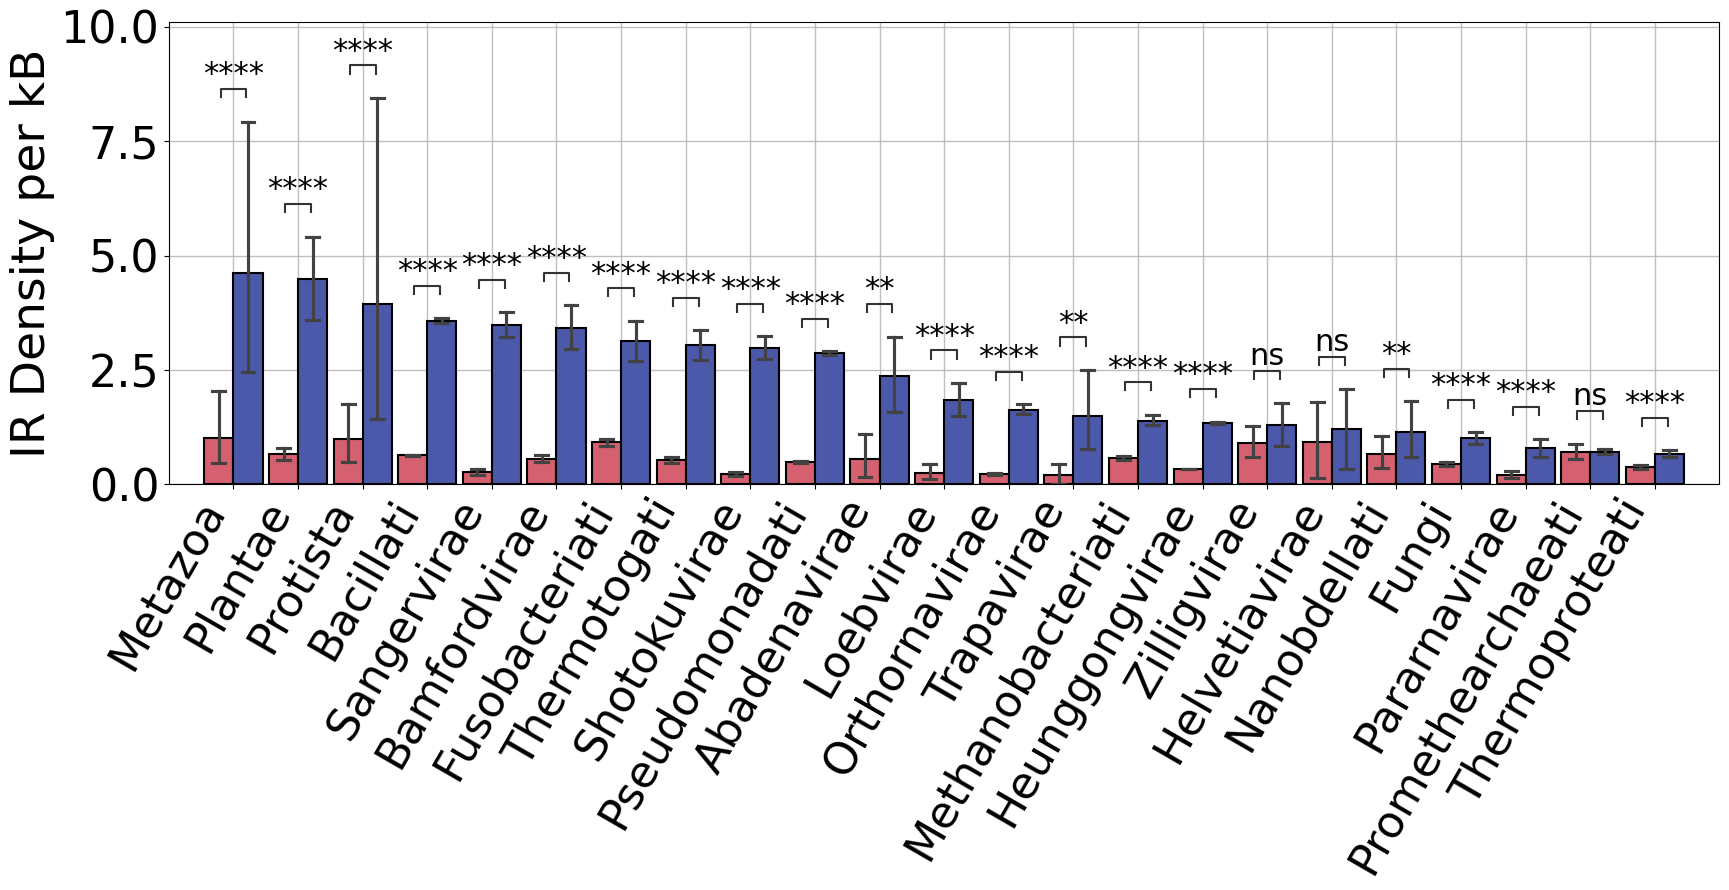

In [ ]:
pattern = "IR"
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
expected_color = "#e84d60"
observed_color = "#3c4cba"
palette = {
           "Control": expected_color,
           pattern: observed_color
          }

sns.barplot(data=comparison_df_melted.to_pandas(),
            x="kingdom",
            y="value",
            hue=f"density_{pattern}",
            palette=palette,
            width=0.9,
            linewidth=1.5,
            edgecolor="black",
            # showfliers=False,
            order=order,
            hue_order=["Control", pattern],
            ax=ax,
            capsize=0.4,
            # boxprops=dict(linewidth=2, edgecolor='black'),
            # medianprops=dict(color='crimson', linewidth=3), 
            # whiskerprops=dict(linewidth=2, color='gray'),
            # capprops=dict(linewidth=2, color='black'),
            # saturation=0.8,
            # flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=60, pad=2)
ax.set_xlabel('')
ax.set_ylabel(f"{pattern} Density per kB")
ax.yaxis.label.set_size(34)
ax.tick_params(axis="both", 
               labelsize=32, 
               zorder=0)
ax.tick_params(axis="x", labelsize=32, 
               zorder=0)
ax.legend(handles=[], frameon=False)
ranks = comparison_df_melted["kingdom"].unique()
pairs=[((q, "Control"), (q, pattern)) for q in ranks]

annotator = Annotator(ax, 
                      pairs, 
                      data=comparison_df_melted.to_pandas(), 
                      x="kingdom", 
                      hue=f"density_{pattern}",
                      y="value", 
                      order=order
                     )
annotator.configure(test='Wilcoxon',  
                    comparisons_correction="fdr_bh",
                    text_format='star',
                    fontsize=22,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
for tick in ax.get_xticklabels():
    tick.set_ha('right')
    # tick.set_x(tick.get_position()[0] - 0.006) 
x0, x1 = ax.get_xlim()
ax.set_xlim(x0 + 0.6, x1 - 0.6) 
fig.savefig(f"{target}/{pattern}_density_kingdom_vs_controls_boxplot.pdf", transparent=True, bbox_inches="tight")

In [301]:
comparison_df_melted  = comparison_df\
        .filter(pl.col("partition") != ".")\
        .group_by(["species_taxid", "partition"], maintain_order=True)\
        .agg(
            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
            pl.col("kingdom").first().alias("kingdom"),
            pl.col("domain").first().alias("domain"),
            pl.col("phylum").first().alias("phylum"),
            pl.col("organism_name").first().alias("organism_name"),
            pl.col("gc_percent").mean().alias("gc_percent"),
        )\
    .melt(
        id_vars=["species_taxid", "partition", "organism_name", "domain", "kingdom", "phylum", "gc_percent"],
        value_vars=[f"density_{pattern}", f"density_{pattern}_control"],
        variable_name=f"density_{pattern}"
    )\
        .with_columns(
            pl.col(f"density_{pattern}")
            .replace(f"density_{pattern}", pattern)
            .replace(f"density_{pattern}_control", "Control")
        )\
        .with_columns(
            partition=pl.col("partition").cast(pl.Int16)
        )

comparison_df_melted["partition"].unique()

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/4165053796.py:13: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(


partition
i16
0
1
2
3
4
5
6
7
8


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

8_IR vs. 8_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:5.239e-46 Stat=1.774e+04
1_IR vs. 1_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:4.949e-72 Stat=6.204e+03
0_IR vs. 0_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:2.552e-81 Stat=2.692e+03
2_IR vs. 2_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.269e-59 Stat=1.201e+04
3_IR vs. 3_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:2.522e-67 Stat=8.214e+03
4_IR vs. 4_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:1.330e-58 Stat=1.240e+04
5_IR vs. 5_Control: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:3.047e-

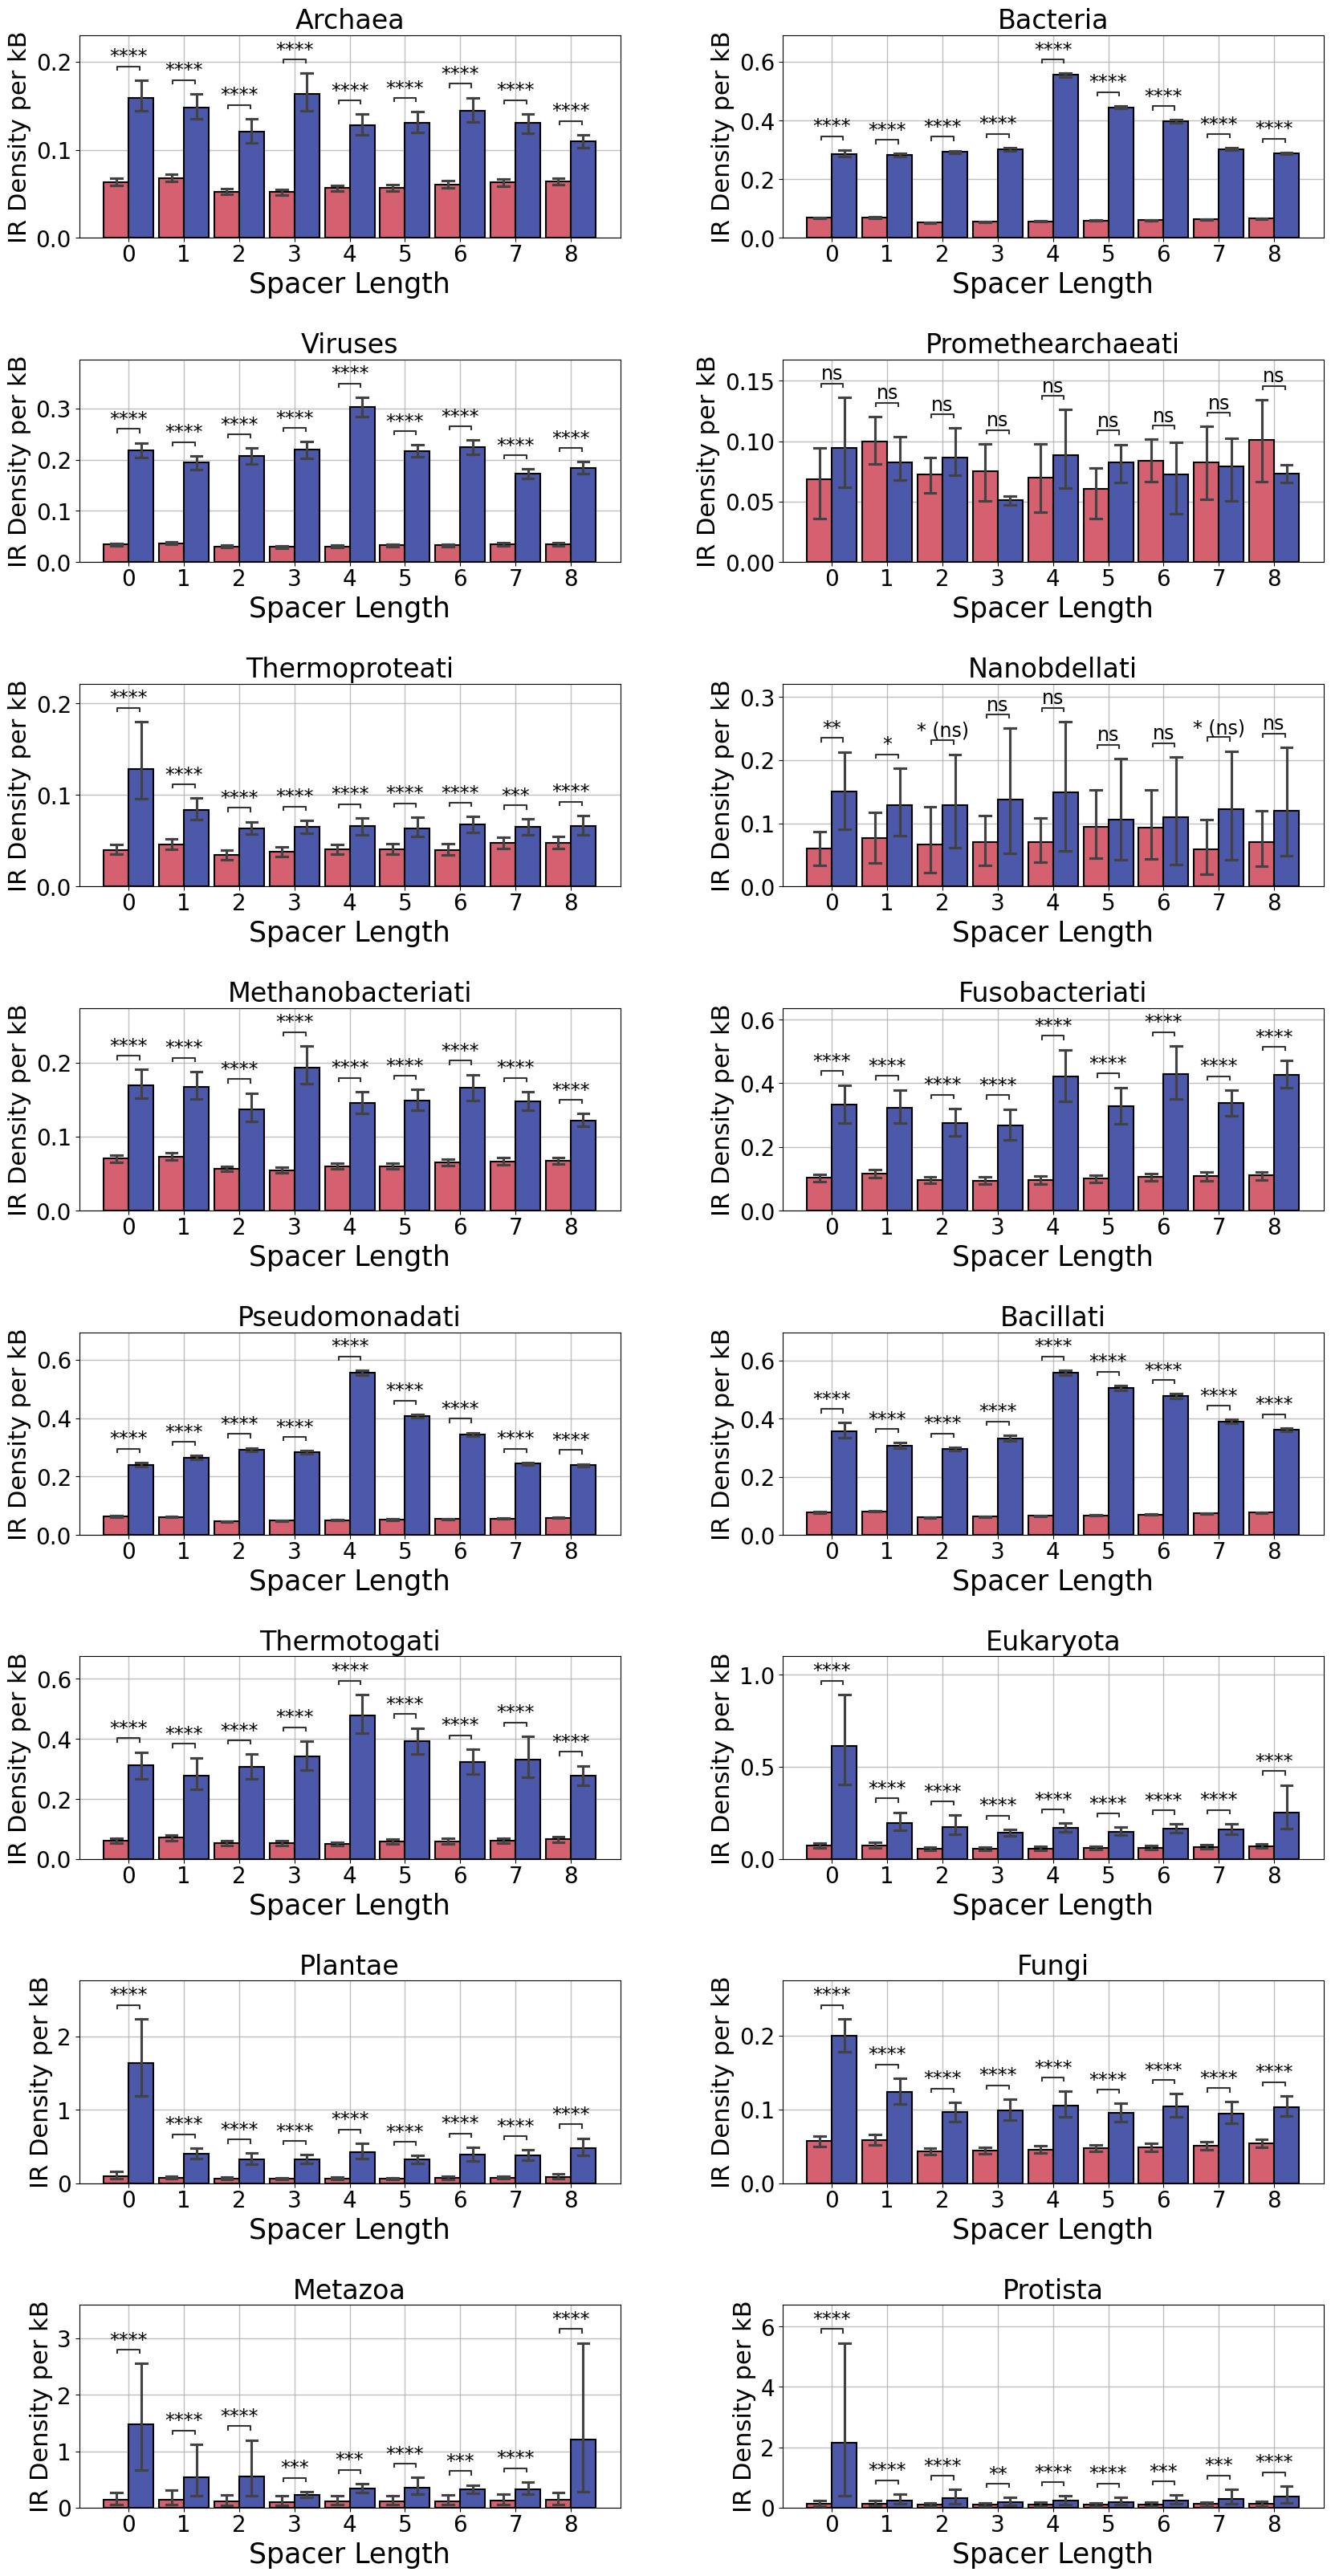

In [ ]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(20, 40))
axes = axes.flatten()
fig.subplots_adjust(hspace=0.6, wspace=0.3)
expected_color = "#e84d60"
observed_color = "#3c4cba"
palette = {
           "Control": expected_color,
           pattern: observed_color
          }

combinations = [("Archaea", "domain"),
                ("Bacteria", "domain"),
                ("Viruses", "domain"),
                ("Promethearchaeati", "kingdom"),
                ("Thermoproteati", "kingdom"),
                ("Nanobdellati", "kingdom"),
                ("Methanobacteriati", "kingdom"),
                ("Fusobacteriati", "kingdom"),
                ("Pseudomonadati", "kingdom"),
                ("Bacillati", "kingdom"),
                ("Thermotogati", "kingdom"),
                ("Eukaryota", "domain"),
                ("Plantae", "kingdom"),
                ("Fungi", "kingdom"),
                ("Metazoa", "kingdom"),
                ("Protista", "kingdom"),
                ]
for i, combination in enumerate(combinations):
    ax = axes[i]
    kingdom, ranking = combination 
    sns.barplot(data=comparison_df_melted.filter(pl.col(ranking) == kingdom).to_pandas(),
                x="partition",
                y="value",
                hue=f"density_{pattern}",
                # showfliers=False,
                palette=palette,
                width=0.9,
                linewidth=1.5,
                edgecolor="black",
                order=list(range(0, 9, 1)),
                hue_order=["Control", pattern],
                ax=ax,
                    # boxprops=dict(linewidth=2, edgecolor='black'),
                    # medianprops=dict(color='crimson', linewidth=3), 
                    # whiskerprops=dict(linewidth=2, color='gray'),
                    # capprops=dict(linewidth=2, color='black'),
                # saturation=0.8,
                    capsize=0.4,
                    # flierprops=dict(marker='o', color='orange', markersize=5)
               )
    ax.grid(lw=1.0, alpha=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=0, pad=2)
    ax.set_xlabel('Spacer Length')
    ax.xaxis.label.set_size(25)
    ax.set_ylabel(f"{pattern} Density per kB")
    ax.yaxis.label.set_size(22)
    ax.tick_params(axis="both", 
                   labelsize=20, 
                   zorder=0)
    # ax.legend(handles=[], frameon=False)
    ax.legend(frameon=True, fancybox=True, prop={"size": 16}, title="")
    ax.legend(handles=[], frameon=False)
    pairs=[((q, "Control"), (q, pattern)) for q in range(0, 9, 1)]

    ax.set_title(kingdom, fontsize=24)
    annotator = Annotator(ax, 
                          pairs, 
                          data=comparison_df_melted.filter(pl.col(ranking) == kingdom).to_pandas(), 
                          x="partition", 
                          hue=f"density_{pattern}",
                          y="value", 
                          order=list(range(0, 9, 1))
                         )
    annotator.configure(test='Wilcoxon',
                        comparisons_correction="fdr_bh",
                        text_format='star',
                        fontsize=17,
                        text_offset=-0.05,
                        loc='inside')
    annotator.apply_and_annotate()
    # for tick in ax.get_xticklabels():
    #    tick.set_ha('right')
    #    tick.set_x(tick.get_position()[0] - 0.006) 
    # x0, x1 = ax.get_xlim()
    # ax.set_xlim(x0 + 0.6, x1 - 0.6) 
fig.savefig(f"{target}/{pattern}_density_kingdom_vs_controls_sru_comparison.pdf", transparent=True, pad_inches=0, bbox_inches="tight")

## Phylum Level Comparisons

In [ ]:
# Parameters
pattern = "IR"
partition_col = "partition"
stats = defaultdict(list)
phylums = comparison_df["phylum"]
N_iterations = 1000 
partition = range(0, 9, 1)

def assign_stars(pval: float) -> str:
    # if pval < 0.0001:
    #    return "****"
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

comparison_df_avged = comparison_df.group_by(["species_taxid", partition_col, "phylum"])\
                            .agg(
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                            )

for phylum in tqdm(phylums.unique(), 
                   desc="Processing phylums", 
                   total=phylums.n_unique()):
    df = comparison_df_avged.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
    for partitioning_element in partition:
        df_sru = df.filter(pl.col(partition_col) == str(partitioning_element))
        densities = list(df_sru.select([f"density_{pattern}"])[f"density_{pattern}"])
        densities_controls = list(df_sru.select([f"density_{pattern}_control"])[f"density_{pattern}_control"])
        group_A = densities
        group_B = densities_controls
        if len(group_A) < 2 or len(group_B) < 2:
            continue

        stats["phylum"].append(phylum)
        stats[partition_col].append(partitioning_element)
        stats["counts"].append(df_sru.shape[0])
        stats["enrichment"].append(
            df_sru.select(pl.col("fold_enrichment")).to_numpy().mean()
        )
        stats[f"density_{pattern}"].append(
            df_sru.select(pl.col(f"density_{pattern}")).to_numpy().mean()
        )
        stats[f"density_{pattern}_control"].append(
            df_sru.select(pl.col(f"density_{pattern}_control")).to_numpy().mean()
        )
        result = wilcoxon(densities, densities_controls).pvalue
        if np.isnan(result):
            result = 1.0
        stats["pval"].append(result)

stats_df = pl.DataFrame(stats)
# FDR correction
rejected, pvals_corrected, _, _ = multipletests(stats_df["pval"].to_numpy(), method='fdr_bh')
# rejected, pvals_corrected_permutation, _, _ = multipletests(stats_df["pval_permutation"].to_numpy(), method='fdr_bh')

Processing phylums:  10%|█         | 13/129 [00:00<00:01, 115.94it/s]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
Processing phylums:  85%|████████▌ | 110/129 [00:01<00:00, 75.30it/s]/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/803226463.py:41: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  df = comparison_df_avged.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
Processing phylums: 100%|██████████| 129/129 [00:01<00:00, 79.15it/s]


In [329]:
stats_df = stats_df.with_columns(pval_adjusted=pl.Series(pvals_corrected))
stats_df

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted
str,i64,i64,f64,f64,f64,f64,f64
"""Arthropoda""",0,7,0.690193,1.577429,0.238714,0.015625,0.029283
"""Arthropoda""",1,7,0.541541,1.169429,0.321571,0.015625,0.029283
"""Arthropoda""",2,7,0.597659,1.265857,0.236143,0.015625,0.029283
"""Arthropoda""",3,7,0.376113,0.274,0.211571,0.296875,0.439676
"""Arthropoda""",4,7,0.482161,0.429143,0.216143,0.21875,0.35267
…,…,…,…,…,…,…,…
"""Pseudomonadota""",4,4790,0.810396,0.581583,0.049729,0.0,0.0
"""Pseudomonadota""",5,4790,0.758504,0.41234,0.051802,0.0,0.0
"""Pseudomonadota""",6,4790,0.70937,0.333519,0.053387,0.0,0.0


In [330]:
stats_df.filter(pl.col("pval_adjusted").is_null())

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted
str,i64,i64,f64,f64,f64,f64,f64


In [ ]:
stats_df = stats_df.with_columns(pval_adjusted=pl.Series(pvals_corrected))
stats_df = stats_df.with_columns(
    pl.col("pval_adjusted").map_elements(assign_stars, return_dtype=pl.Utf8).alias("pval_adjusted_stars")
)
# stats_df = stats_df.sort("phylum").sort("partition")
stats_pivot_df = stats_df.pivot(on="partition", 
                                index="phylum", 
                                values="pval_adjusted_stars", 
                                aggregate_function="first"
                                ) #.select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
stats_pivot_df

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted,pval_adjusted_stars
str,i64,i64,f64,f64,f64,f64,f64,str
"""Arthropoda""",0,7,0.690193,1.577429,0.238714,0.015625,0.029283,"""*"""
"""Arthropoda""",1,7,0.541541,1.169429,0.321571,0.015625,0.029283,"""*"""
"""Arthropoda""",2,7,0.597659,1.265857,0.236143,0.015625,0.029283,"""*"""
"""Arthropoda""",3,7,0.376113,0.274,0.211571,0.296875,0.439676,"""ns"""
"""Arthropoda""",4,7,0.482161,0.429143,0.216143,0.21875,0.35267,"""ns"""
…,…,…,…,…,…,…,…,…
"""Pseudomonadota""",4,4790,0.810396,0.581583,0.049729,0.0,0.0,"""***"""
"""Pseudomonadota""",5,4790,0.758504,0.41234,0.051802,0.0,0.0,"""***"""
"""Pseudomonadota""",6,4790,0.70937,0.333519,0.053387,0.0,0.0,"""***"""


In [332]:
stats_df["pval_adjusted_stars"].value_counts()

pval_adjusted_stars,count
str,u32
"""***""",344
"""**""",43
"""ns""",381
"""*""",51


In [333]:
MIN_COUNT_THRESHOLD =9
comparison_df_avg = comparison_df.filter(~pl.col("phylum").is_null())\
                    .group_by(["species_taxid", "partition"])\
                    .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                        pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                        pl.col("domain").first().alias("domain"),
                        pl.col("kingdom").first().alias("kingdom"),
                        pl.col("phylum").first().alias("phylum"),
                        pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                    ).group_by(["partition", "phylum"])\
    .agg(
         pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
         pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
         pl.col("domain").first().alias("domain"),
         pl.col("kingdom").first().alias("kingdom"),
         pl.col("fold_enrichment").mean().alias("fold_enrichment"),
         pl.col("fold_enrichment").count().alias("counts"),
         )\
        .filter(pl.col("counts") >= MIN_COUNT_THRESHOLD)\
        .sort(f"density_{pattern}", descending=True)\
        .pivot(
            index="phylum",
            on="partition",
            values="fold_enrichment",
            aggregate_function="mean"
        )\
        .select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
# \ #.filter(pl.col("partition") != ".").with_columns(partition=pl.col("partition").cast(pl.Int32)).sort(["partition"]) 
comparison_df_avg

phylum,0,1,2,3,4,5,6,7,8
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Apicomplexa""",0.616345,0.247692,0.339334,0.140595,0.269826,0.344458,0.332878,0.284461,0.382128
"""Mycoplasmatota""",0.55307,0.4958,0.55252,0.537533,0.643157,0.644929,0.633677,0.526822,0.525182
"""Nucleocytoviricota""",0.555261,0.4227,0.50363,0.4461,0.471803,0.534193,0.470795,0.500995,0.51989
"""Streptophyta""",0.90862,0.683812,0.692988,0.705313,0.72583,0.671712,0.696383,0.680338,0.723006
"""Lenarviricota""",0.048337,0.06938,0.066366,0.078533,0.098008,0.06728,0.037069,0.021433,0.022166
…,…,…,…,…,…,…,…,…,…
"""Thermoplasmatota""",0.408156,0.258437,0.421084,0.355567,0.439339,0.373831,0.380146,0.280701,0.352404
"""Basidiomycota""",0.470925,0.266419,0.182152,0.171023,0.159132,0.225243,0.219257,0.226586,0.214496
"""Duplornaviricota""",0.028134,0.020687,0.003562,0.01407,0.0124,0.014845,0.015677,0.019594,0.010211


In [334]:
stats_pivot_df = stats_df.pivot(on="partition", 
                                index="phylum", 
                                values="pval_adjusted_stars", 
                                aggregate_function="first"
                                ) #.select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
stats_pivot_df

phylum,0,1,2,3,4,5,6,7,8
str,str,str,str,str,str,str,str,str,str
"""Arthropoda""","""*""","""*""","""*""","""ns""","""ns""","""*""","""ns""","""*""","""*"""
"""Verrucomicrobiota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""
"""Lenarviricota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""
"""Vulcanimicrobiota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Fibrobacterota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
…,…,…,…,…,…,…,…,…,…
"""Apicomplexa""","""**""","""**""","""**""","""ns""","""**""","""**""","""**""","""**""","""**"""
"""Methanobacteriota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""
"""Candidatus Saccharimonadota""","""***""","""***""","""**""","""***""","""***""","""***""","""***""","""***""","""***"""


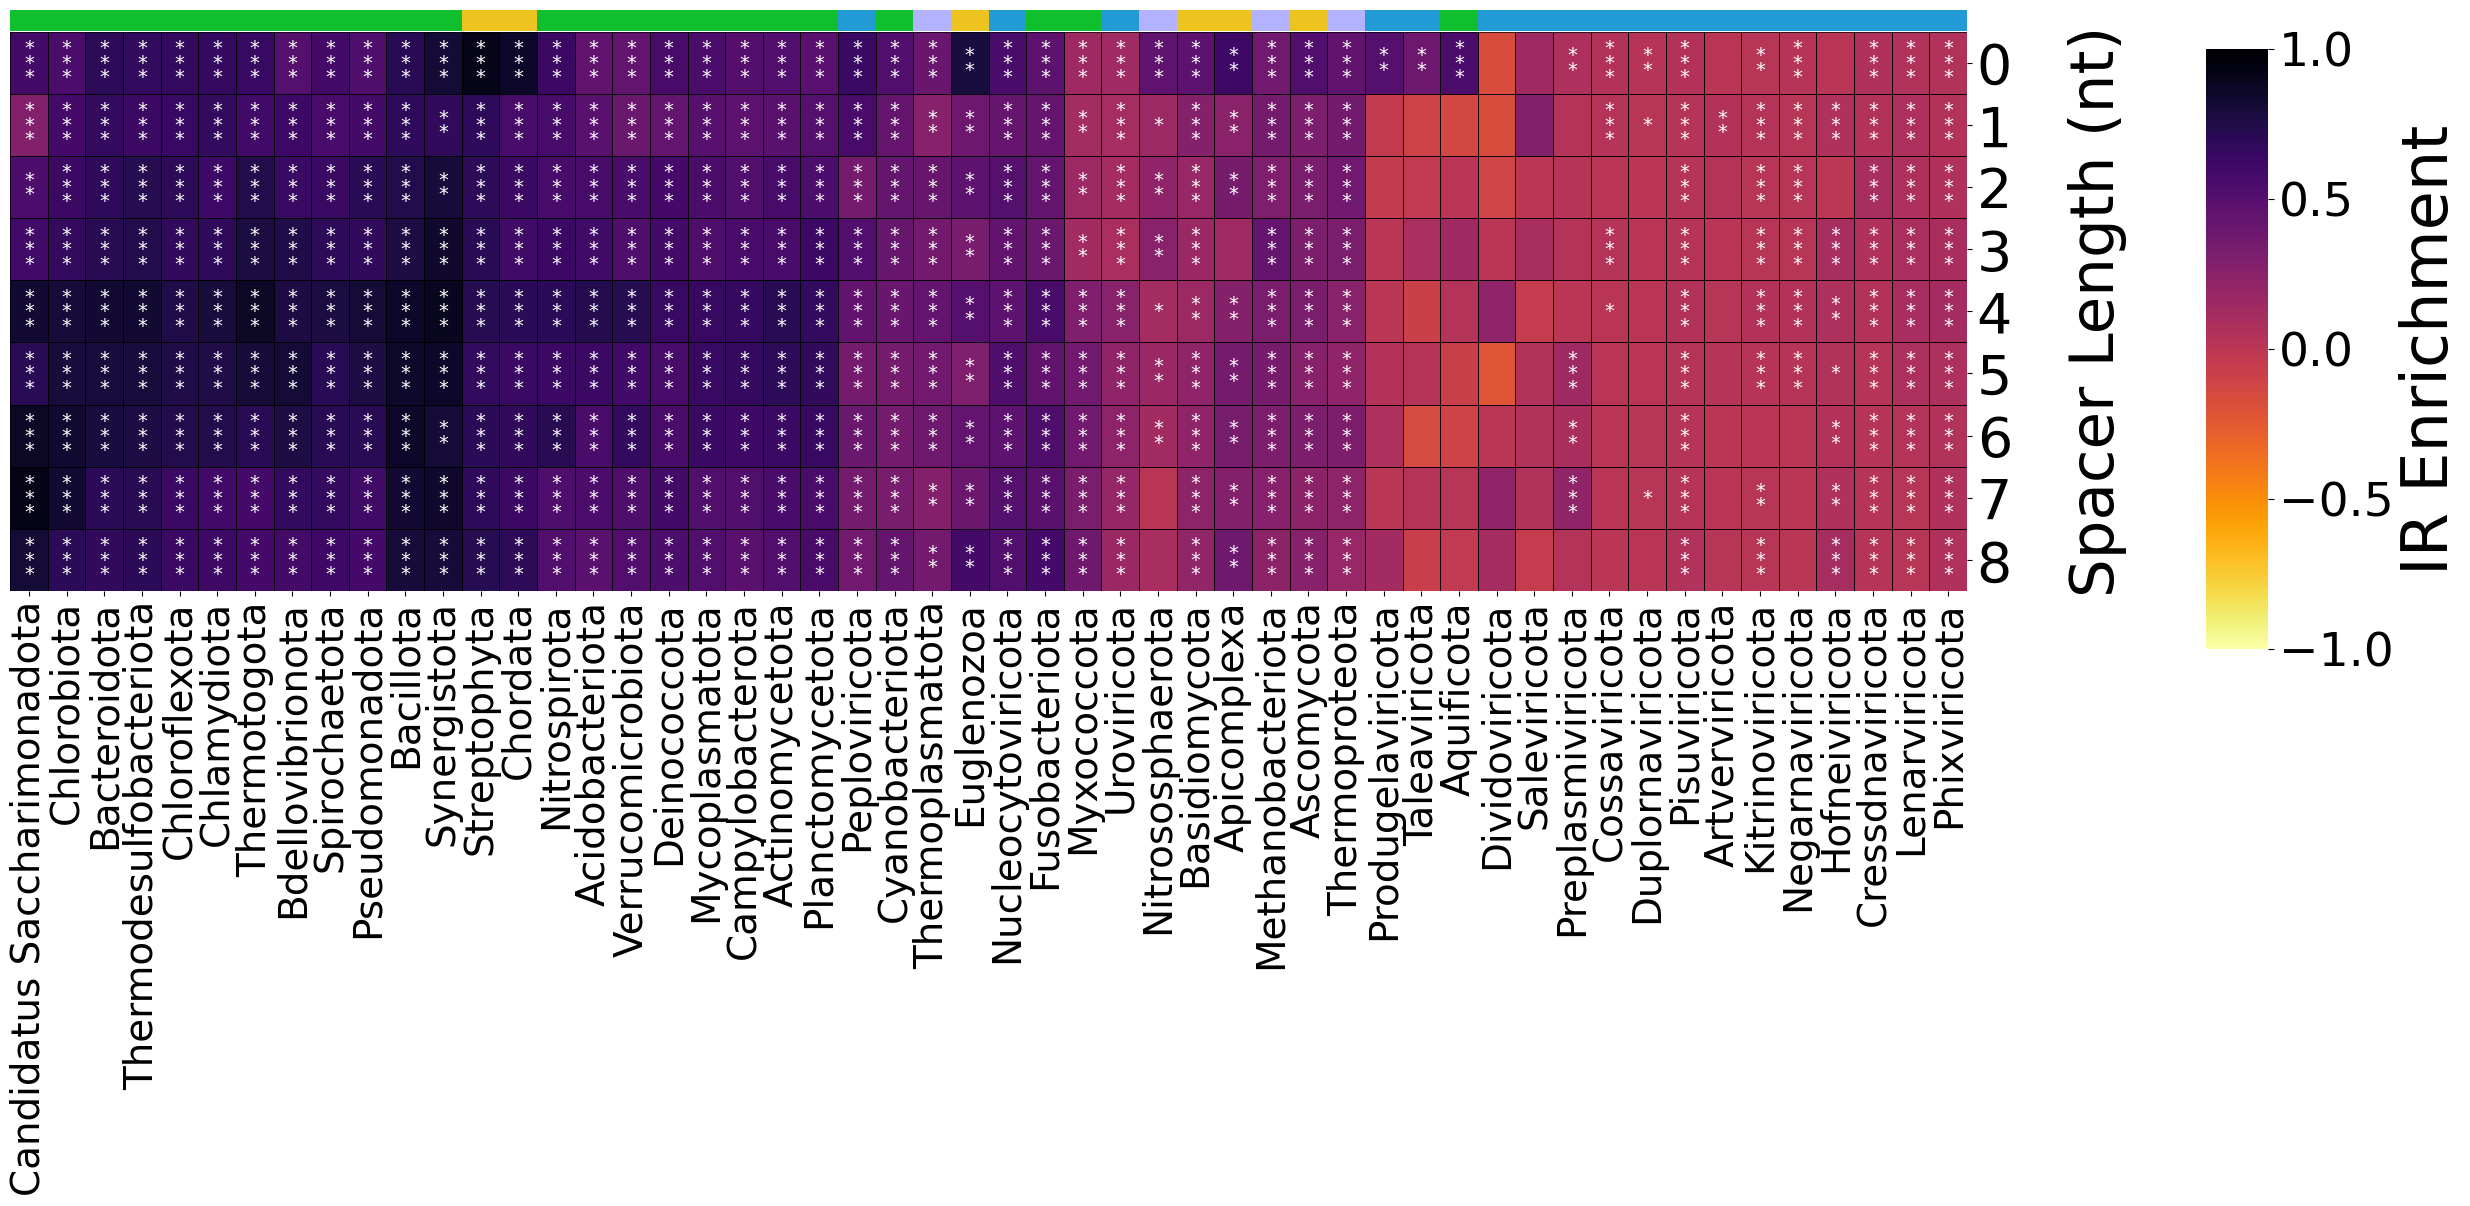

In [ ]:
kws = dict(cbar_kws=dict(location="top", shrink=0.2))
figsize=(15, 36)
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#0fbf2d',
                'Viruses': '#229ad6',
}

# kingdom_to_domain = dict(zip(comparison_df["kingdom"], comparison_df["domain"]))
phylum_to_domain = dict(zip(comparison_df["phylum"], comparison_df["domain"]))
phylum_to_kingdom= dict(zip(comparison_df["phylum"], comparison_df["kingdom"]))
# phylum_to_kingdom = {phylum: kingdom if kingdom_to_domain[kingdom] != "Viruses" else "Viruses" for phylum, kingdom in phylum_to_kingdom.items()}
domains = list(comparison_df_avg.with_columns(pl.col("phylum").replace_strict(phylum_to_domain).alias("domain"))["domain"])
# domains = [phylum_to_domain[col] for col in comparison_df_avg.columns if col != "partition"]
# kingdoms = list(comparison_df_avg.with_columns(pl.col("phylum").replace_strict(phylum_to_kingdom).alias("kingdom"))["kingdom"])
domain_colors = [domain_colors[domain] for domain in domains]

# kingdom_colors = [kingdom_color_palette[kingdom] for kingdom in kingdoms]
cg = sns.clustermap(
                  # comparison_df_avg.to_pandas().set_index("phylum"),
                  comparison_df_avg.to_pandas().set_index("phylum").T,
                   col_colors=[domain_colors], # kingdom_colors],
                   row_cluster=False, 
                   col_cluster=True,
                    method="ward",
                    figsize=(25, 10),
                    vmax=1.0,
                    center=0.0,
                    vmin=-1.0,
                    cmap="inferno_r",
                   robust=True,
                   yticklabels=True, 
                   xticklabels=True,
                   cbar_kws={"shrink": 0.1, 
                             "orientation": "vertical"}
                   )
ax = cg.ax_heatmap
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
ax = cg.ax_heatmap
ax.set_ylabel("")
t = ax.xaxis.get_majorticklocs()
ax.xaxis.label.set_size(52)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", 
               which="major", 
               labelsize=38,
               rotation=0
              )
ax.tick_params(axis="x", 
               which="major", 
               labelsize=28,
               rotation=90
              )
ax.tick_params(axis="y", 
               which="major", 
               labelsize=40,
               rotation=0
              )

x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([1.08, 0.2, 0.025, 0.6])
cg.ax_cbar.tick_params(axis='both', length=4, labelsize=34)
cg.cax.set_ylabel(f'{pattern} Enrichment', size=46) #, labelpad=15, size=12)
for spine in cg.ax_cbar.spines:
    cg.ax_cbar.spines[spine].set_color('black')
    # cg.ax_cbar.spines[spine].set_linewidth(2)

ax.set_ylabel("Spacer Length (nt)", size=44, labelpad=40)
ax.set_xlabel("")
data = comparison_df_avg.to_pandas().loc[cg.dendrogram_col.reordered_ind].set_index("phylum")
n_rows, n_cols = data.T.shape
for i in range(n_rows):
    for j in range(n_cols):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

stars_df = stats_pivot_df.to_pandas().set_index("phylum").loc[data.index, data.columns]  # reorder to match clustered heatmap
stats_df_temp = stats_df.to_pandas().set_index(["phylum", "partition"])["pval_adjusted_stars"]
for i, phylum in enumerate(data.index):
   for j, col in enumerate(data.columns):
       star = stats_df_temp.loc[phylum, int(col)]
       if star != "ns":
            vertical_star = "\n".join(star)   # "***" -> "*\n*\n*"

            ax.text(i + 0.5, j + 0.5, vertical_star,
                    ha='center', 
                    va='center',
                    fontsize=14, 
                    linespacing=0.7,
                    color='white')
fig = plt.gcf()
fig.savefig(target.joinpath(f"{pattern}_clustermap_enrichment_simie_phylum.pdf"), 
            transparent=True,
            bbox_inches='tight', 
            dpi=600)
plt.show()

In [336]:
## Without STR

In [380]:
comparison_df_avg.head()

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_corrected,density_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
28875,"""0""",-0.016214,-0.016214,"""Viruses""",0.038938,0.062648,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",1744,2694,0,18,0.03894,0.063057
28875,"""1""",-0.051233,-0.051377,"""Viruses""",0.005153,0.074275,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",256,3129,24,11,0.005686,0.074071
28875,"""2""",-0.035513,-0.035513,"""Viruses""",0.00239,0.050592,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",110,2158,0,16,0.00239,0.050956
28875,"""3""",-0.02499,-0.02499,"""Viruses""",0.006856,0.041327,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",308,1783,0,0,0.006856,0.041326
28875,"""4""",0.120928,0.120975,"""Viruses""",0.215967,0.053637,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",9496,2302,0,5,0.215964,0.053749


In [384]:

# Parameters
pattern = "IR"
partition_col = "partition"
stats = defaultdict(list)
phylums = comparison_df["phylum"]
N_iterations = 1000 
partition = list(map(str, range(0, 9, 1)))

def assign_stars(pval: float) -> str:
    # if pval < 0.0001:
    #    return "****"
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

# comparison_df_avged = comparison_df_avg.group_by(["species_taxid", partition_col, "phylum"])\
#                             .agg(
#                                 pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
#                                 pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
#                                 pl.col("fold_enrichment").mean().alias("fold_enrichment"),
#                                 pl.col("domain").first().alias("domain"),
#                                 pl.col("kingdom").first().alias("kingdom"),
#                             )

for phylum in tqdm(phylums.unique(), 
                   desc="Processing phylums", 
                   total=phylums.n_unique()):
    df = comparison_df_avg.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
    for partitioning_element in partition:
        df_sru = df.filter(pl.col(partition_col) == str(partitioning_element))
        densities = list(df_sru.select([f"density_corrected"])[f"density_corrected"])
        densities_controls = list(df_sru.select([f"density_control_corrected"])[f"density_control_corrected"])
        group_A = densities
        group_B = densities_controls
        if len(group_A) < 2 or len(group_B) < 2:
            continue

        stats["phylum"].append(phylum)
        stats[partition_col].append(partitioning_element)
        stats["counts"].append(df_sru.shape[0])
        stats["enrichment"].append(
            df_sru.select(pl.col("fold_enrichment")).to_numpy().mean()
        )
        stats[f"density_{pattern}"].append(
            df_sru.select(pl.col(f"density_{pattern}")).to_numpy().mean()
        )
        stats[f"density_{pattern}_control"].append(
            df_sru.select(pl.col(f"density_{pattern}_control")).to_numpy().mean()
        )
        result = wilcoxon(densities, densities_controls).pvalue
        if np.isnan(result):
            result = 1.0
        stats["pval"].append(result)

stats_df = pl.DataFrame(stats)
# FDR correction
rejected, pvals_corrected, _, _ = multipletests(stats_df["pval"].to_numpy(), method='fdr_bh')
# rejected, pvals_corrected_permutation, _, _ = multipletests(stats_df["pval_permutation"].to_numpy(), method='fdr_bh')

Processing phylums:   0%|          | 0/129 [00:00<?, ?it/s]/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_24634/3779288086.py:33: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  df = comparison_df_avg.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
Processing phylums:  22%|██▏       | 29/129 [00:00<00:00, 128.18it/s]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
Processing phylums: 100%|██████████| 129/129 [00:01<00:00, 94.80it/s]


In [382]:
for i, x in enumerate(densities_controls):
    if x is None:
        print(i, x)

In [385]:
stats_df = stats_df.with_columns(pval_adjusted=pl.Series(pvals_corrected))
stats_df = stats_df.with_columns(
    pl.col("pval_adjusted").map_elements(assign_stars, return_dtype=pl.Utf8).alias("pval_adjusted_stars")
)
# stats_df = stats_df.sort("phylum").sort("partition")
stats_pivot_df = stats_df.pivot(on="partition", 
                                index="phylum", 
                                values="pval_adjusted_stars", 
                                aggregate_function="first"
                                ) #.select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
stats_pivot_df

phylum,0,1,2,3,4,5,6,7,8
str,str,str,str,str,str,str,str,str,str
"""Nanobdellota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Candidatus Melainabacteria""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Candidatus Latescibacterota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Fibrobacterota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Promethearchaeota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
…,…,…,…,…,…,…,…,…,…
"""Ambiviricota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Candidatus Heimdallarchaeota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Phixviricota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""


In [386]:
MIN_COUNT_THRESHOLD =9
comparison_df_avg_no_STR = comparison_df_avg.filter(~pl.col("phylum").is_null())\
    .group_by(["partition", "phylum"])\
    .agg(
         pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
         pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
         pl.col("domain").first().alias("domain"),
         pl.col("kingdom").first().alias("kingdom"),
         pl.col("fold_enrichment").mean().alias("fold_enrichment"),
         pl.col("fold_enrichment").count().alias("counts"),
         )\
        .filter(pl.col("counts") >= MIN_COUNT_THRESHOLD)\
        .sort(f"density_{pattern}", descending=True)\
        .pivot(
            index="phylum",
            on="partition",
            values="fold_enrichment",
            aggregate_function="mean"
        )\
        .select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
# \ #.filter(pl.col("partition") != ".").with_columns(partition=pl.col("partition").cast(pl.Int32)).sort(["partition"]) 
comparison_df_avg_no_STR

phylum,0,1,2,3,4,5,6,7,8
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Apicomplexa""",0.659303,0.256402,0.35287,0.144152,0.276644,0.349706,0.338024,0.286284,0.390776
"""Streptophyta""",0.924604,0.685396,0.69818,0.70415,0.728311,0.673053,0.697988,0.680779,0.725352
"""Chordata""",0.87415,0.576037,0.638733,0.608388,0.707409,0.641362,0.678048,0.634963,0.694214
"""Nucleocytoviricota""",0.558254,0.421704,0.503966,0.446322,0.471565,0.534176,0.471028,0.501392,0.521133
"""Produgelaviricota""",0.5,-0.041667,-0.041667,0.0,0.0,0.041667,0.063272,0.0,0.125
…,…,…,…,…,…,…,…,…,…
"""Aquificota""",0.555708,-0.138898,0.011946,0.14346,0.037057,-0.083607,-0.11044,0.019784,-0.025658
"""Basidiomycota""",0.493896,0.268416,0.182436,0.172129,0.158477,0.227638,0.218534,0.226665,0.215249
"""Duplornaviricota""",0.028134,0.020687,0.003562,0.01407,0.0124,0.014845,0.015677,0.019594,0.010211


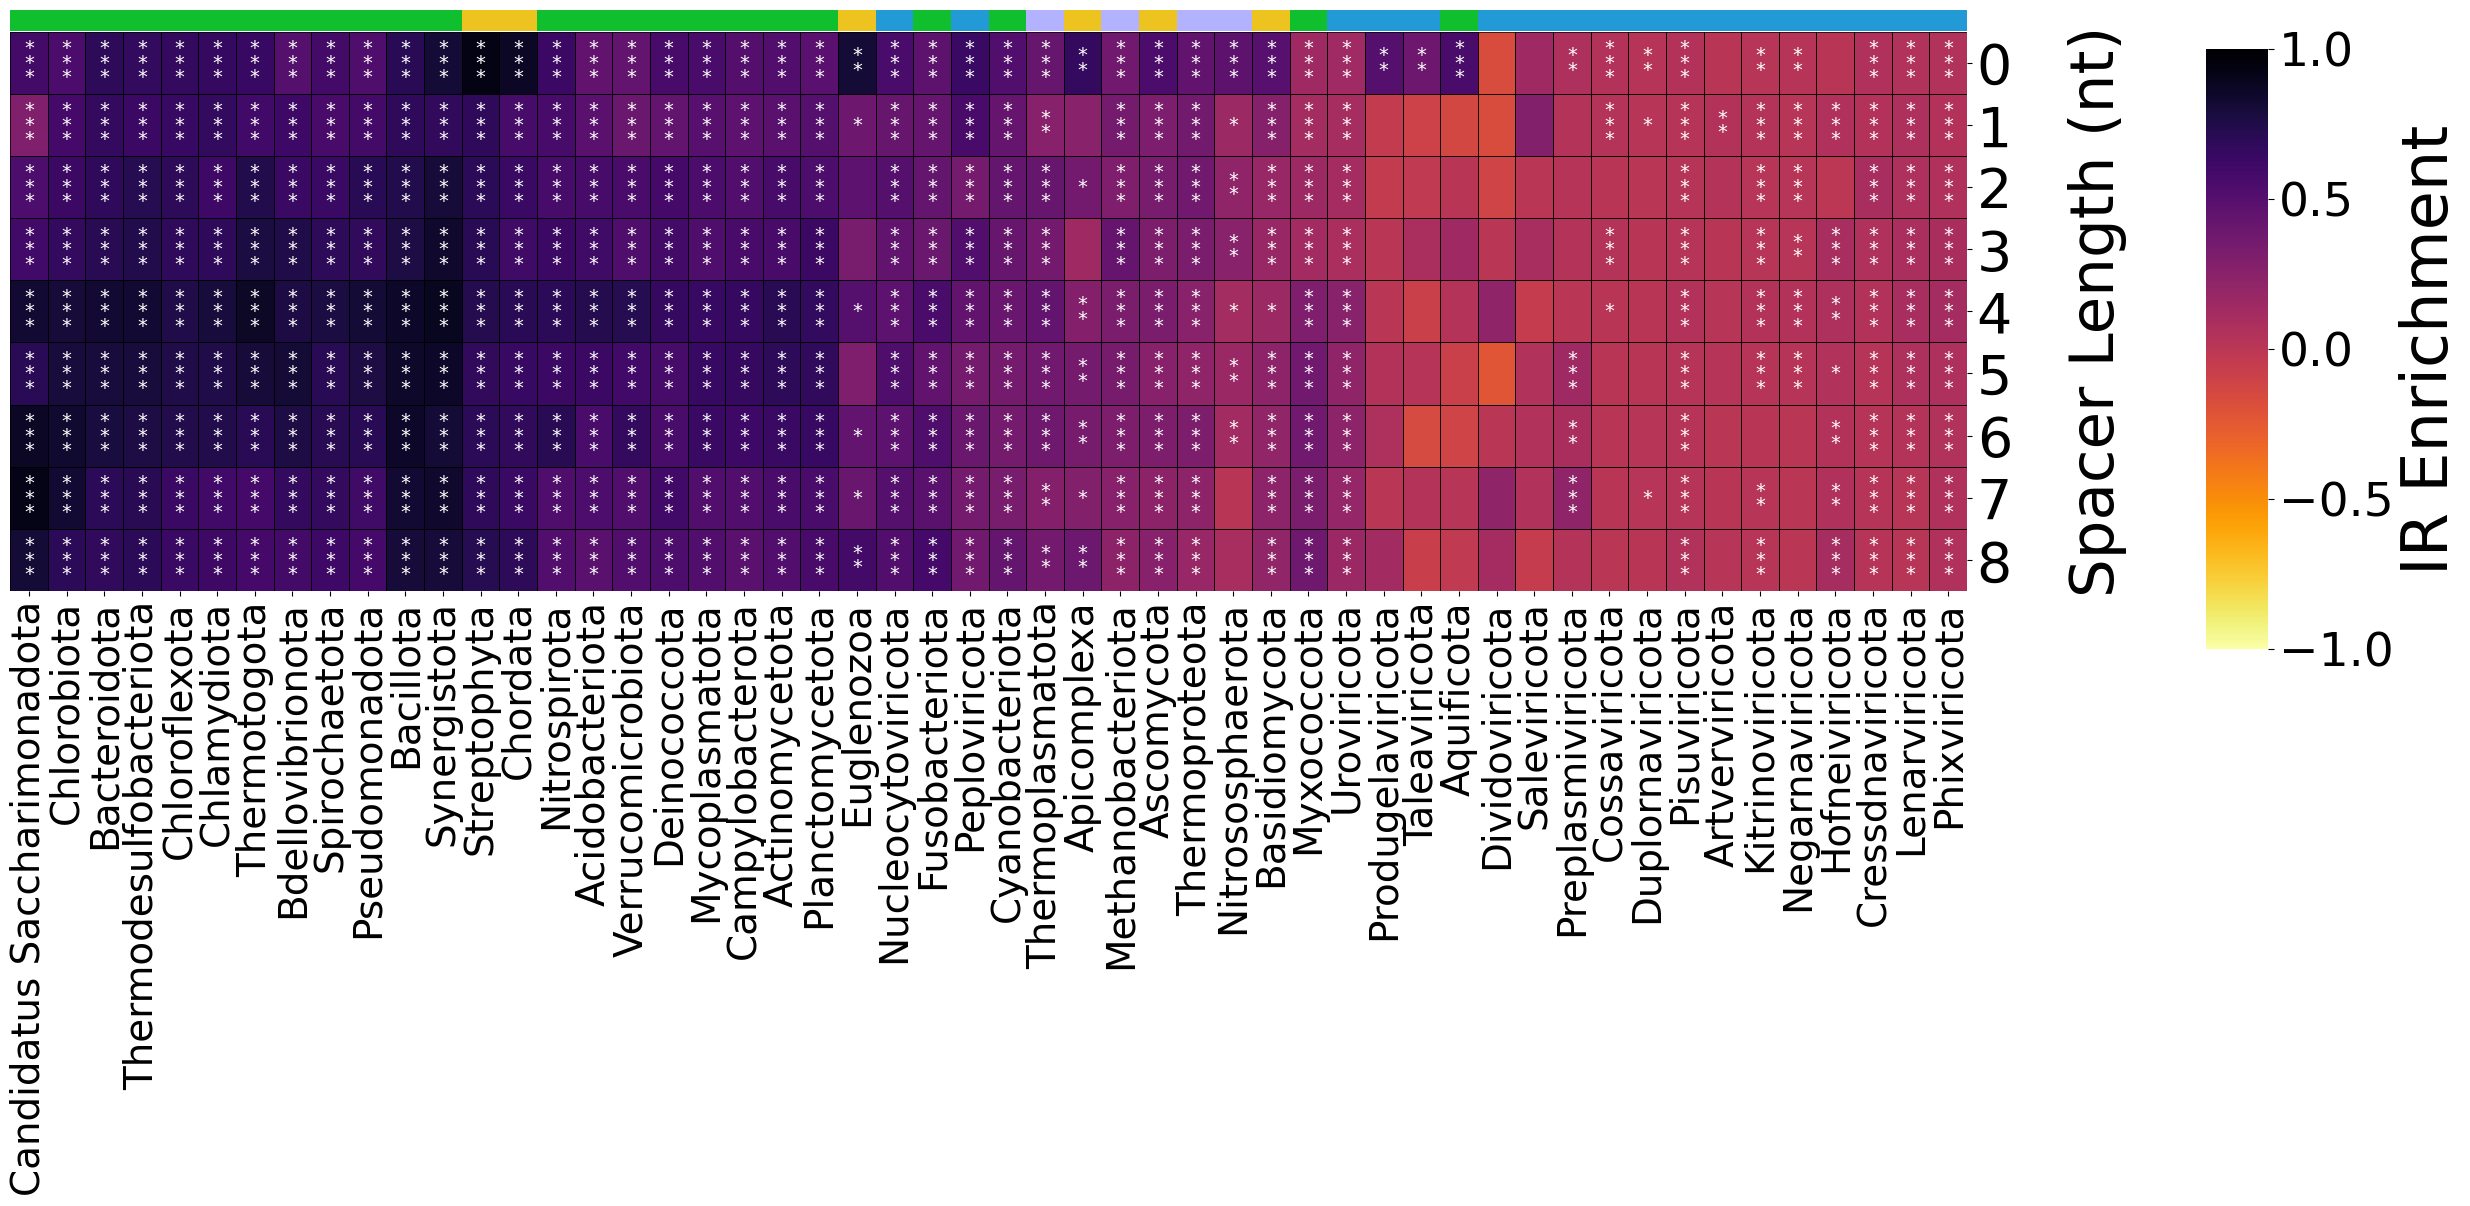

In [388]:
import matplotlib.patches as patches
kws = dict(cbar_kws=dict(location="top", shrink=0.2))
figsize=(15, 36)
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#0fbf2d',
                'Viruses': '#229ad6',
}

phylum_to_domain = dict(zip(comparison_df["phylum"], comparison_df["domain"]))
phylum_to_kingdom= dict(zip(comparison_df["phylum"], comparison_df["kingdom"]))
domains = list(comparison_df_avg_no_STR.with_columns(pl.col("phylum").replace_strict(phylum_to_domain).alias("domain"))["domain"])
domain_colors = [domain_colors[domain] for domain in domains]

# kingdom_colors = [kingdom_color_palette[kingdom] for kingdom in kingdoms]
cg = sns.clustermap(
                  # comparison_df_avg.to_pandas().set_index("phylum"),
                  comparison_df_avg_no_STR.to_pandas().set_index("phylum").T,
                   col_colors=[domain_colors], # kingdom_colors],
                   row_cluster=False, 
                   col_cluster=True,
                    method="ward",
                    figsize=(25, 10),
                    vmax=1.0,
                    center=0.0,
                    vmin=-1.0,
                    cmap="inferno_r",
                   robust=True,
                   yticklabels=True, 
                   xticklabels=True,
                   cbar_kws={"shrink": 0.1, 
                             "orientation": "vertical"}
                   )
ax = cg.ax_heatmap
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
ax = cg.ax_heatmap
ax.set_ylabel("")
t = ax.xaxis.get_majorticklocs()
ax.xaxis.label.set_size(52)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", 
               which="major", 
               labelsize=38,
               rotation=0
              )
ax.tick_params(axis="x", 
               which="major", 
               labelsize=28,
               rotation=90
              )
ax.tick_params(axis="y", 
               which="major", 
               labelsize=40,
               rotation=0
              )

x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([1.08, 0.2, 0.025, 0.6])
cg.ax_cbar.tick_params(axis='both', length=4, labelsize=34)
cg.cax.set_ylabel(f'{pattern} Enrichment', size=46) #, labelpad=15, size=12)
for spine in cg.ax_cbar.spines:
    cg.ax_cbar.spines[spine].set_color('black')
    # cg.ax_cbar.spines[spine].set_linewidth(2)

ax.set_ylabel("Spacer Length (nt)", size=44, labelpad=40)
ax.set_xlabel("")
data = comparison_df_avg_no_STR.to_pandas().loc[cg.dendrogram_col.reordered_ind].set_index("phylum")
n_rows, n_cols = data.T.shape
for i in range(n_rows):
    for j in range(n_cols):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

stars_df = stats_pivot_df.to_pandas().set_index("phylum").loc[data.index, data.columns]  # reorder to match clustered heatmap
stats_df_temp = stats_df.to_pandas().set_index(["phylum", "partition"])["pval_adjusted_stars"]
for i, phylum in enumerate(data.index):
   for j, col in enumerate(data.columns):
       star = stats_df_temp.loc[phylum, str(col)]
       if star != "ns":
            vertical_star = "\n".join(star)   # "***" -> "*\n*\n*"

            ax.text(i + 0.5, j + 0.5, vertical_star,
                    ha='center', 
                    va='center',
                    fontsize=14, 
                    linespacing=0.7,
                    color='white')
fig = plt.gcf()
fig.savefig(target.joinpath(f"{pattern}_clustermap_enrichment_simie_phylum_no_STR.pdf"), 
            transparent=True,
            bbox_inches='tight', 
            dpi=600)
plt.show()